# Solar Power 24-Hour Forecast — Multi-Model Comparison
**System 2107 | Open-Meteo NWP Weather Forecast Features**

| Split | Period | Purpose |
|---|---|---|
| **Train** | 2022-03-23 → 2023-11-09 | Rolling-window CV + final training |
| **Validation** | 2024-01-01 → 2024-05-31 | Early stopping reference |
| **Test** | 2024-06-01 → 2024-10-31 | Held-out final evaluation |

**Models:** LightGBM · XGBoost · RandomForest · Ridge  
**Optional MLP:** set `USE_MLP = True` in Cell 1 to include a deep neural net  
**Baselines:** Persistence · Climatology · Smart Persistence


In [1]:
import pandas as pd
import numpy as np
import warnings, copy
warnings.filterwarnings("ignore")

import requests
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder, QuantileTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec

# ── CONFIG ─────────────────────────────────────────────────────────────────────
USE_MLP = True    # set False to skip MLP (~90s) for a faster run

print(f"Config: USE_MLP = {USE_MLP}")
print("All imports OK")


Config: USE_MLP = True
All imports OK


## 1. Data Loading
Fetch 15-min Open-Meteo NWP weather forecasts and merge with meter data.

In [2]:
# ── Open-Meteo: 1-day-ahead NWP forecasts at 15-min resolution ───────────────
# timezone="PST8PDT" ensures timestamps are in local Pacific time,
# matching the meter data and the LMP 'Interval Start' timestamps.
url = "https://previous-runs-api.open-meteo.com/v1/forecast"
params = {
    "latitude":  38.9963,
    "longitude": -122.1341,
    "start_date": "2022-03-23",
    "end_date":   "2024-10-31",
    "timezone":   "PST8PDT",        # ← local Pacific time (avoids UTC mismatch)
    "minutely_15": [
        "temperature_2m", "relative_humidity_2m", "dew_point_2m",
        "apparent_temperature", "wind_speed_10m", "wind_speed_80m",
        "wind_direction_10m", "wind_direction_80m", "wind_gusts_10m",
        "shortwave_radiation", "direct_radiation", "direct_normal_irradiance",
        "diffuse_radiation", "global_tilted_irradiance", "sunshine_duration",
        "precipitation", "snowfall", "rain", "cape", "visibility",
        "weather_code", "cloud_cover", "pressure_msl", "surface_pressure",
    ],
    "models":       "gfs_seamless",
    "previous_day": 1,
}
print("Fetching Open-Meteo weather data...")
resp = requests.get(url, params=params)
resp.raise_for_status()
weather_df = (pd.DataFrame(resp.json()["minutely_15"])
                .rename(columns={"time": "measured_on"}))
weather_df["measured_on"] = pd.to_datetime(weather_df["measured_on"])
print(f"  Weather rows : {len(weather_df):,}")
print(f"  Weather dates: {weather_df['measured_on'].min()} → {weather_df['measured_on'].max()}")

# ── Meter data ────────────────────────────────────────────────────────────────
meter_urls = {
    "train": "https://oedi-data-lake.s3.amazonaws.com/pvdaq/2023-solar-data-prize/2107_OEDI/data/2107_meter_15m_data.csv",
    "2024":  "https://oedi-data-lake.s3.amazonaws.com/pvdaq/2023-solar-data-prize/2107_OEDI/data/2107_meter_15m_data_2024.csv",
}
print("Fetching meter data...")
meter_train = pd.read_csv(meter_urls["train"])
meter_2024  = pd.read_csv(meter_urls["2024"])

meter_train["measured_on"] = pd.to_datetime(meter_train["measured_on"])
meter_2024["measured_on"]  = pd.to_datetime(meter_2024["measured_on"])

PWR_COL = "meter_revenue_grade_ac_output_meter_149578"
meter_train = meter_train.rename(columns={PWR_COL: "actual_power_kw"})
meter_2024  = meter_2024.rename(columns={PWR_COL: "actual_power_kw"})

# ── Power cap filter: clip physical outliers > 1000 kW ───────────────────────
# System capacity ~707 kW; values above 1000 kW are sensor errors.
meter_train = meter_train[meter_train["actual_power_kw"] <= 1000].copy()
meter_2024  = meter_2024[meter_2024["actual_power_kw"]  <= 1000].copy()
print(f"  meter_train after cap filter : {len(meter_train):,} rows  "
      f"max={meter_train['actual_power_kw'].max():.1f} kW")
print(f"  meter_2024  after cap filter : {len(meter_2024):,} rows   "
      f"max={meter_2024['actual_power_kw'].max():.1f} kW")

# ── KEY FIX: restrict meter_train to weather coverage & use inner merge ────────
WEATHER_START = weather_df["measured_on"].min()
meter_train   = meter_train[meter_train["measured_on"] >= WEATHER_START].copy()

df_train_raw = meter_train.merge(weather_df, on="measured_on", how="inner")
df_2024_raw  = meter_2024.merge(weather_df,  on="measured_on", how="inner")

df_train_raw = df_train_raw.dropna(subset=["actual_power_kw"])
df_2024_raw  = df_2024_raw.dropna(subset=["actual_power_kw"])

# ── Date-based splits ─────────────────────────────────────────────────────────
VAL_END = pd.Timestamp("2024-06-01")
df_val_raw   = df_2024_raw[df_2024_raw["measured_on"] <  VAL_END].copy()
df_test_raw  = df_2024_raw[df_2024_raw["measured_on"] >= VAL_END].copy()

print(f"\nAfter inner merge:")
print(f"  df_train_raw : {len(df_train_raw):,} rows  "
      f"({df_train_raw['measured_on'].min().date()} → {df_train_raw['measured_on'].max().date()})")
print(f"  df_val_raw   : {len(df_val_raw):,} rows   "
      f"({df_val_raw['measured_on'].min().date()} → {df_val_raw['measured_on'].max().date()})")
print(f"  df_test_raw  : {len(df_test_raw):,} rows   "
      f"({df_test_raw['measured_on'].min().date()} → {df_test_raw['measured_on'].max().date()})")
print(f"  Weather NaNs in train: {df_train_raw['shortwave_radiation'].isna().sum()}")


Fetching Open-Meteo weather data...
  Weather rows : 91,584
  Weather dates: 2022-03-23 00:00:00 → 2024-10-31 23:45:00
Fetching meter data...
  meter_train after cap filter : 240,061 rows  max=708.5 kW
  meter_2024  after cap filter : 32,155 rows   max=705.9 kW

After inner merge:
  df_train_raw : 57,207 rows  (2022-03-23 → 2023-11-09)
  df_val_raw   : 14,587 rows   (2024-01-01 → 2024-05-31)
  df_test_raw  : 14,688 rows   (2024-06-01 → 2024-10-31)
  Weather NaNs in train: 0


In [3]:
# ── DATA AUDIT — run this before building any features ───────────────────────
print("=" * 60)
print("METER DATA AUDIT")
print("=" * 60)
print(f"meter_train columns : {list(meter_train.columns)}")
print(f"meter_train shape   : {meter_train.shape}")
print(f"meter_train dates   : {meter_train['measured_on'].min()} → {meter_train['measured_on'].max()}")
print(f"actual_power_kw stats:\n{meter_train['actual_power_kw'].describe()}")
print()
print(f"meter_2024 columns  : {list(meter_2024.columns)}")
print(f"meter_2024 shape    : {meter_2024.shape}")
print(f"meter_2024 dates    : {meter_2024['measured_on'].min()} → {meter_2024['measured_on'].max()}")
print(f"actual_power_kw stats:\n{meter_2024['actual_power_kw'].describe()}")
print()
print("WEATHER DATA AUDIT")
print(f"weather_df shape    : {weather_df.shape}")
print(f"weather_df dates    : {weather_df['measured_on'].min()} → {weather_df['measured_on'].max()}")
print(f"shortwave_radiation stats:\n{weather_df['shortwave_radiation'].describe()}")
print()
print("MERGE AUDIT (df_train_raw)")
print(f"  shape             : {df_train_raw.shape}")
print(f"  actual_power_kw   : min={df_train_raw['actual_power_kw'].min():.1f}  max={df_train_raw['actual_power_kw'].max():.1f}  mean={df_train_raw['actual_power_kw'].mean():.1f}")
print(f"  weather NaNs      : {df_train_raw['shortwave_radiation'].isna().sum()}")
print(f"  rows w/ power>0   : {(df_train_raw['actual_power_kw'] > 0).sum()}")
print()
print("MERGE AUDIT (df_2024_raw)")
print(f"  shape             : {df_2024_raw.shape}")
print(f"  actual_power_kw   : min={df_2024_raw['actual_power_kw'].min():.1f}  max={df_2024_raw['actual_power_kw'].max():.1f}  mean={df_2024_raw['actual_power_kw'].mean():.1f}")
print(f"  weather NaNs      : {df_2024_raw['shortwave_radiation'].isna().sum()}")
print(f"  rows w/ power>0   : {(df_2024_raw['actual_power_kw'] > 0).sum()}")
print()
# Check timezone consistency
print("TIMEZONE CHECK")
print(f"  weather_df tz     : {weather_df['measured_on'].dt.tz}")
print(f"  meter_train tz    : {meter_train['measured_on'].dt.tz}")
print(f"  meter_2024 tz     : {meter_2024['measured_on'].dt.tz}")
# Check overlap
merged_check = meter_train.merge(weather_df, on="measured_on", how="inner")
print(f"\nINNER JOIN rows (meter_train × weather): {len(merged_check):,}")
print(f"  If 0, timestamps don't match — timezone or format mismatch!")
print("=" * 60)


METER DATA AUDIT
meter_train columns : ['measured_on', 'actual_power_kw']
meter_train shape   : (57207, 2)
meter_train dates   : 2022-03-23 00:00:00 → 2023-11-09 23:30:00
actual_power_kw stats:
count    57207.000000
mean       166.822119
std        233.376566
min          0.000000
25%          0.000000
50%          0.000000
75%        343.040000
max        707.840000
Name: actual_power_kw, dtype: float64

meter_2024 columns  : ['measured_on', 'actual_power_kw']
meter_2024 shape    : (32155, 2)
meter_2024 dates    : 2024-01-01 00:15:00 → 2024-11-30 23:45:00
actual_power_kw stats:
count    32155.000000
mean       162.799221
std        229.489839
min          0.000000
25%          0.000000
50%          1.280000
75%        330.880000
max        705.920000
Name: actual_power_kw, dtype: float64

WEATHER DATA AUDIT
weather_df shape    : (91584, 25)
weather_df dates    : 2022-03-23 00:00:00 → 2024-10-31 23:45:00
shortwave_radiation stats:
count    91584.000000
mean       237.388299
std        

## 2. Feature Engineering
- **Cyclical time** — hour & day-of-year as sin/cos pairs
- **Lag features** — 15-min, 1-hr, 24-hr, 48-hr lags of actual power
- **Rolling irradiance stats** — 1-hr and 3-hr rolling mean/std of shortwave radiation
- **Wind components** — u/v decomposition at 10m and 80m
- **weather_code** — label-encoded categorical
- All other Open-Meteo columns used as-is (continuous numeric)


In [4]:
TARGET = "actual_power_kw"

WEATHER_COLS = [
    "temperature_2m", "relative_humidity_2m", "dew_point_2m",
    "apparent_temperature", "wind_speed_10m", "wind_speed_80m",
    "wind_direction_10m", "wind_direction_80m", "wind_gusts_10m",
    "shortwave_radiation", "direct_radiation", "direct_normal_irradiance",
    "diffuse_radiation", "global_tilted_irradiance", "sunshine_duration",
    "precipitation", "snowfall", "rain", "cape", "visibility",
    "cloud_cover", "pressure_msl", "surface_pressure",
]

# Encode weather_code on the full union of all periods
le_wc = LabelEncoder()
all_wc = pd.concat([
    df_train_raw["weather_code"].fillna(0),
    df_2024_raw["weather_code"].fillna(0),
]).astype(int)
le_wc.fit(all_wc)

def add_features(df):
    """Add time, lag, rolling and wind features. Input must be sorted by time."""
    df = df.copy()

    # ── Cyclical time ─────────────────────────────────────────────────────────
    hour = df.index.hour + df.index.minute / 60
    doy  = df.index.dayofyear
    df["sin_hour"] = np.sin(2 * np.pi * hour / 24)
    df["cos_hour"] = np.cos(2 * np.pi * hour / 24)
    df["sin_doy"]  = np.sin(2 * np.pi * doy  / 365)
    df["cos_doy"]  = np.cos(2 * np.pi * doy  / 365)
    df["hour"]     = df.index.hour
    df["month"]    = df.index.month

    # ── Lag features — same time-slot from past days ────────────────────────────
    # lag_1/lag_4 excluded: cause "copy last value" pathology (sunset spike).
    # Using same-slot lags: 24h, 48h, 7-day, 14-day, 21-day
    for lag in [96, 192, 672, 1344, 2016]:  # 24h, 48h, 7d, 14d, 21d
        df[f"lag_{lag}"] = df[TARGET].shift(lag)

    # ── 3-day rolling average baseline (same as user's yhat_baseline) ─────────
    # Average of same slot 1, 2, 3 days ago — classic persistence baseline
    df["lag_3day_avg"] = pd.concat(
        [df[TARGET].shift(96), df[TARGET].shift(192), df[TARGET].shift(288)],
        axis=1
    ).mean(axis=1)

    # ── Rolling shortwave stats ───────────────────────────────────────────────
    df["sw_roll1h_mean"] = df["shortwave_radiation"].rolling(4,  min_periods=1).mean()
    df["sw_roll3h_mean"] = df["shortwave_radiation"].rolling(12, min_periods=1).mean()
    df["sw_roll1h_std"]  = df["shortwave_radiation"].rolling(4,  min_periods=1).std().fillna(0)

    # ── Rolling power stats (24h window) — captures daily generation pattern ──
    df["pow_roll24h_mean"] = df[TARGET].shift(1).rolling(96,  min_periods=24).mean()
    df["pow_roll24h_std"]  = df[TARGET].shift(1).rolling(96,  min_periods=24).std().fillna(0)

    # ── Wind u/v components ───────────────────────────────────────────────────
    for spd, dirn, suffix in [
        ("wind_speed_10m", "wind_direction_10m", "10m"),
        ("wind_speed_80m", "wind_direction_80m", "80m"),
    ]:
        rad = np.deg2rad(df[dirn].fillna(0))
        df[f"wind_u_{suffix}"] = df[spd] * np.cos(rad)
        df[f"wind_v_{suffix}"] = df[spd] * np.sin(rad)

    # ── Irradiance ratios (clearness proxies) ─────────────────────────────────
    df["dni_ghi_ratio"] = np.where(
        df["shortwave_radiation"] > 10,
        df["direct_normal_irradiance"] / df["shortwave_radiation"].clip(lower=1),
        0
    )
    df["diffuse_frac"] = np.where(
        df["shortwave_radiation"] > 10,
        df["diffuse_radiation"] / df["shortwave_radiation"].clip(lower=1),
        0
    )

    # ── Clear-sky index: cloud_cover-adjusted irradiance proxy ────────────────
    df["clearsky_idx"] = (1 - df["cloud_cover"].fillna(0) / 100).clip(0, 1)
    df["gti_x_clearsky"] = df["global_tilted_irradiance"] * df["clearsky_idx"]

    # ── Hour × irradiance interaction (helps tree models split on both) ────────
    df["hour_x_sw"]  = df.index.hour * df["shortwave_radiation"]
    df["hour_x_gti"] = df.index.hour * df["global_tilted_irradiance"]

    # ── Cloud change rate (key for detecting cloud events) ────────────────────
    # Rate of change of cloud cover over last 1h and 3h — fast-rising clouds
    # indicate an incoming cloud event that NWP may have under-predicted.
    df["cloud_change_1h"] = df["cloud_cover"].diff(4).fillna(0)   # 4 × 15min = 1h
    df["cloud_change_3h"] = df["cloud_cover"].diff(12).fillna(0)  # 12 × 15min = 3h

    # ── Cloud-event flag: cloud cover rising fast (>20pp in 1h) ──────────────
    df["cloud_event"]  = (df["cloud_change_1h"] > 20).astype(float)

    # ── Irradiance drop rate (lagged) ─────────────────────────────────────────
    # Sudden drop in forecast shortwave signals imminent cloud cover
    df["sw_drop_1h"]   = (df["shortwave_radiation"].diff(4)).clip(upper=0).abs().fillna(0)

    # ── Solar elevation proxy: sin(hour_angle) × sin(declination) ─────────────
    # Approximation of solar elevation without lat/lon trig — helps model
    # distinguish high-sun days (more irradiance capacity) from low-sun days.
    hour_angle = (df.index.hour + df.index.minute/60 - 12) * (np.pi / 12)
    declination = 23.45 * np.sin(2*np.pi*(df.index.dayofyear - 81)/365) * np.pi/180
    df["solar_elev_proxy"] = np.sin(np.deg2rad(38.9963)) * np.sin(declination) +                               np.cos(np.deg2rad(38.9963)) * np.cos(declination) * np.cos(hour_angle)
    df["solar_elev_proxy"] = df["solar_elev_proxy"].clip(lower=0)  # night = 0

    # ── Lag ratio: today's forecast vs yesterday's actual (clearness change) ──
    sw_yest = df["shortwave_radiation"].shift(96)
    df["sw_today_vs_yest"] = np.where(sw_yest > 10,
                                       df["shortwave_radiation"] / sw_yest.clip(lower=1),
                                       1.0).clip(0, 3)

    # ── Encode weather_code ───────────────────────────────────────────────────
    df["weather_code_enc"] = le_wc.transform(df["weather_code"].fillna(0).astype(int))

    return df

TIME_FEATS  = ["sin_hour","cos_hour","sin_doy","cos_doy","hour","month"]
LAG_FEATS      = ["lag_96","lag_192","lag_672","lag_1344","lag_2016","lag_3day_avg"]
ROLL_FEATS  = ["sw_roll1h_mean","sw_roll3h_mean","sw_roll1h_std",
               "pow_roll24h_mean","pow_roll24h_std"]
WIND_FEATS  = ["wind_u_10m","wind_v_10m","wind_u_80m","wind_v_80m"]
RATIO_FEATS    = ["dni_ghi_ratio","diffuse_frac","clearsky_idx","gti_x_clearsky",
                  "hour_x_sw","hour_x_gti","cloud_change_1h","cloud_change_3h",
                  "cloud_event","sw_drop_1h","solar_elev_proxy","sw_today_vs_yest"]
FEATURES    = WEATHER_COLS + TIME_FEATS + LAG_FEATS + ROLL_FEATS + WIND_FEATS + RATIO_FEATS + ["weather_code_enc"]

print(f"Total features: {len(FEATURES)}")


Total features: 57


## 3. Build Feature DataFrames

In [5]:
# ── Compute features on each contiguous block separately ─────────────────────
# Never bridge the Nov 2023 → Jan 2024 gap with synthetic values.
# Instead, compute lags within each block; the first 192 rows of each block
# will naturally have NaN lags and are dropped by dropna(subset=FEATURES).

def prep_block(df_raw):
    """Set index, sort, compute all features, return clean DataFrame."""
    df = df_raw.copy()
    if "measured_on" in df.columns:
        df = df.set_index("measured_on")
    df = df.sort_index()
    df = add_features(df)
    df = df.dropna(subset=FEATURES + [TARGET])
    return df

df_train_feat = prep_block(df_train_raw)
df_2024_feat  = prep_block(df_2024_raw)

# ── Splits ────────────────────────────────────────────────────────────────────
VAL_END = pd.Timestamp("2024-06-01")

df_val_feat  = df_2024_feat[df_2024_feat.index <  VAL_END].copy()
df_test_feat = df_2024_feat[df_2024_feat.index >= VAL_END].copy()

# Pre-test combined for final retraining
df_pretrain_feat = pd.concat([df_train_feat, df_val_feat]).sort_index()

X_train = df_train_feat[FEATURES];    y_train = df_train_feat[TARGET]
X_val   = df_val_feat[FEATURES];      y_val   = df_val_feat[TARGET]
X_test  = df_test_feat[FEATURES];     y_test  = df_test_feat[TARGET]
X_pre   = df_pretrain_feat[FEATURES]; y_pre   = df_pretrain_feat[TARGET]

print(f"Train    : {df_train_feat.index.min().date()} → {df_train_feat.index.max().date()}  {X_train.shape}")
print(f"Val      : {df_val_feat.index.min().date()}   → {df_val_feat.index.max().date()}    {X_val.shape}")
print(f"Test     : {df_test_feat.index.min().date()}  → {df_test_feat.index.max().date()}   {X_test.shape}")
print(f"Pre-test : {df_pretrain_feat.index.min().date()} → {df_pretrain_feat.index.max().date()}  {X_pre.shape}")

print("\nSANITY CHECKS:")
print(f"  X_test NaNs          : {X_test.isna().sum().sum()}")
print(f"  y_test max           : {y_test.max():.1f} kW")
print(f"  y_test daytime mean  : {y_test[y_test > 10].mean():.1f} kW")
print(f"  lag_96 in X_test     : min={X_test['lag_96'].min():.1f}  max={X_test['lag_96'].max():.1f}  mean={X_test['lag_96'].mean():.1f}")
print(f"  lag_96 in X_train    : min={X_train['lag_96'].min():.1f}  max={X_train['lag_96'].max():.1f}  mean={X_train['lag_96'].mean():.1f}")
print(f"  lag_96 zeros in test : {(X_test['lag_96'] == 0).sum()} / {len(X_test)}")
print(f"  pow_roll24h in test  : min={X_test['pow_roll24h_mean'].min():.1f}  max={X_test['pow_roll24h_mean'].max():.1f}")


Train    : 2022-04-13 → 2023-11-09  (55191, 57)
Val      : 2024-01-22   → 2024-05-31    (12571, 57)
Test     : 2024-06-01  → 2024-10-31   (14688, 57)
Pre-test : 2022-04-13 → 2024-05-31  (67762, 57)

SANITY CHECKS:
  X_test NaNs          : 0
  y_test max           : 705.3 kW
  y_test daytime mean  : 357.1 kW
  lag_96 in X_test     : min=0.0  max=705.3  mean=182.9
  lag_96 in X_train    : min=0.0  max=707.8  mean=166.4
  lag_96 zeros in test : 6642 / 14688
  pow_roll24h in test  : min=0.0  max=231.3


## 4. Model Definitions

In [6]:
# Speed optimisations applied throughout:
#   - LightGBM/XGBoost: early stopping caps n_estimators; lower num_leaves for CV
#   - RandomForest: n_estimators reduced to 300 (enough for tabular solar data)
#   - MLP: smaller architecture (256,128,64), tighter early stopping patience
#   - All tree models use n_jobs=-1 (parallel)

# ── LightGBM ──────────────────────────────────────────────────────────────────
lgb_params = dict(
    num_leaves        = 127,
    learning_rate     = 0.1,       # ↑ faster convergence
    n_estimators      = 500,       # ↓ early stopping fires well before this,
    subsample         = 0.8,
    subsample_freq    = 1,
    colsample_bytree  = 0.8,
    min_child_samples = 30,        # ↑ reduces overfit on sparse high-power regions
    min_split_gain    = 0.01,      # require minimum gain to split — reduces overfit
    reg_alpha         = 0.1,       # ↑ L1 regularisation
    reg_lambda        = 1.0,       # ↑ L2 regularisation
    max_bin           = 255,
    random_state      = 42,
    verbose           = -1,
    n_jobs            = -1,
)

# ── XGBoost ───────────────────────────────────────────────────────────────────
xgb_params = dict(
    max_depth         = 6,
    learning_rate     = 0.1,       # ↑ faster convergence → fewer trees
    n_estimators      = 500,       # ↓ hard cap; early stopping fires ~100-200
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    colsample_bylevel = 0.8,
    min_child_weight  = 30,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    gamma             = 0.05,
    random_state      = 42,
    verbosity         = 0,
    n_jobs            = -1,
    tree_method       = "hist",
    early_stopping_rounds = 30,    # stop if no improvement for 30 rounds
)

# ── Random Forest ─────────────────────────────────────────────────────────────
rf_params = dict(
    n_estimators     = 200,        # ↓ 300→200: faster, accuracy ~same
    max_depth        = 15,
    min_samples_leaf = 10,
    max_features     = 0.5,
    random_state     = 42,
    n_jobs           = -1,
)

# ── Ridge ─────────────────────────────────────────────────────────────────────
ridge_params = dict(alpha=0.1)    # near-instant, no changes needed

# ── MLP ───────────────────────────────────────────────────────────────────────
mlp_params = dict(
    hidden_layer_sizes  = (256, 128, 64),  # smaller than 512,256,128,64: ~3× faster
    activation          = "relu",
    solver              = "adam",
    alpha               = 1e-4,
    batch_size          = 256,             # explicit batch size: faster per epoch
    learning_rate_init  = 3e-3,            # higher LR: fewer epochs to converge
    max_iter            = 150,             # ↓ 200→150 epochs max
    early_stopping      = True,
    validation_fraction = 0.1,
    n_iter_no_change    = 15,              # tighter patience: stops sooner
    random_state        = 42,
)

# ── Build registry ─────────────────────────────────────────────────────────────
# ── Linear Regression ────────────────────────────────────────────────────────
# Ordinary Least Squares — no regularisation. Uses same StandardScaler pipeline
# as Ridge. Included to show whether regularisation (Ridge) is beneficial over
# plain OLS for this solar forecasting task.
from sklearn.linear_model import LinearRegression

MODEL_REGISTRY_TEMPLATES = {
    "LightGBM":     lgb.LGBMRegressor(**lgb_params),
    "XGBoost":      xgb.XGBRegressor(**xgb_params),
    "RandomForest": RandomForestRegressor(**rf_params),
    "Ridge":        Pipeline([("scaler", StandardScaler()),
                               ("model", Ridge(**ridge_params))]),
    "LinearReg":    Pipeline([("scaler", StandardScaler()),
                               ("model", LinearRegression())]),
}

if USE_MLP:
    MODEL_REGISTRY_TEMPLATES["MLP"] = Pipeline([
        ("scaler", QuantileTransformer(output_distribution="normal",
                                       n_quantiles=min(1000, len(X_train)),
                                       random_state=42)),
        ("model",  MLPRegressor(**mlp_params)),
    ])
    print("MLP included.")
else:
    print("MLP skipped (USE_MLP = False).")

print(f"\nModel registry ({len(MODEL_REGISTRY_TEMPLATES)} models):")
for name in MODEL_REGISTRY_TEMPLATES:
    print(f"  {name}")

# ── Estimated runtimes (approximate, single-core equivalent) ──────────────────
print("\nEstimated final-fit times:")
print("  LightGBM     ~30s  (early stopping ~200-400 trees)")
print("  XGBoost      ~45s  (early stopping ~200-400 trees)")
print("  RandomForest ~60s  (300 trees, depth=20, parallel)")
print("  Ridge        <1s")
print("  MLP          ~90s  (256,128,64 adam, early stop)")
print("  Rolling CV   ~5min (52 folds × LightGBM+XGBoost+Ridge only)")


MLP included.

Model registry (6 models):
  LightGBM
  XGBoost
  RandomForest
  Ridge
  LinearReg
  MLP

Estimated final-fit times:
  LightGBM     ~30s  (early stopping ~200-400 trees)
  XGBoost      ~45s  (early stopping ~200-400 trees)
  RandomForest ~60s  (300 trees, depth=20, parallel)
  Ridge        <1s
  MLP          ~90s  (256,128,64 adam, early stop)
  Rolling CV   ~5min (52 folds × LightGBM+XGBoost+Ridge only)


## 5. Rolling-Window CV & Final Training

**Protocol:**
1. **Rolling CV** — 365-day window slides daily through the train pool (2022-03-23 → 2023-11-09). Each fold scores on the next day. Folds with no daytime activity are skipped.
2. **Final refit** — each model retrained on all pre-2024 data (train + val) with 2024-Jan–May as early-stopping reference.
3. **Test evaluation** — scored on the held-out 2024-Jun–Oct period.


In [7]:
SYSTEM_CAPACITY_KW = 707.0   # installed AC capacity — hard physical upper bound

def nighttime_zero(preds, df_feat):
    """Zero predictions when shortwave < 10 W/m² and clip to [0, capacity]."""
    night = df_feat["shortwave_radiation"].values < 10
    preds = np.where(night, 0, preds)
    return np.clip(preds, 0, SYSTEM_CAPACITY_KW)  # physical cap at system capacity

def rmse_pct(y_true, y_pred, mask=None):
    """RMSE% = RMSE(predicted - actual) / mean_daytime_actual × 100

    Formula: sqrt( mean( (predicted_i - actual_i)² ) ) / mean(actual_daytime) × 100

    - Computed over daytime rows only (actual > 0).
    - Optional boolean mask to exclude specific rows (e.g. anomaly days).
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    dt = y_true > 0
    if mask is not None:
        dt = dt & np.asarray(mask, dtype=bool)
    if dt.sum() == 0:
        return np.nan
    rmse        = np.sqrt(np.mean((y_pred[dt] - y_true[dt]) ** 2))
    mean_actual = y_true[dt].mean()
    return (rmse / mean_actual) * 100


def rmse_absolute(y_true, y_pred, nonzero_only=False):
    """Absolute RMSE in kW.

    Parameters
    ----------
    y_true       : array of actual power values (kW)
    y_pred       : array of predicted power values (kW)
    nonzero_only : if True, compute only on rows where actual > 0
                   (daytime rows); if False, include all rows (night zeros too)

    Returns
    -------
    RMSE in kW
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if nonzero_only:
        mask = y_true > 0
        if mask.sum() == 0:
            return np.nan
        return np.sqrt(np.mean((y_pred[mask] - y_true[mask]) ** 2))
    return np.sqrt(np.mean((y_pred - y_true) ** 2))


def flag_anomaly_days(y_true, index, threshold_pct=30):
    """Flag days where daily production is >threshold% below the rolling 14-day median.
    Returns a boolean mask: True = normal day, False = anomaly/cloudy day.
    """
    s = pd.Series(y_true, index=index)
    daily_sum  = s.resample("D").sum()
    roll_med   = daily_sum.rolling(14, min_periods=3, center=True).median()
    pct_of_med = daily_sum / roll_med.clip(lower=1) * 100
    anomaly_dates = set(pct_of_med[pct_of_med < (100 - threshold_pct)].index.date)
    normal_mask = pd.Series(
        [d.date() not in anomaly_dates for d in index],
        index=index
    )
    return normal_mask.values, anomaly_dates

def clone_model(name):
    return copy.deepcopy(MODEL_REGISTRY_TEMPLATES[name])

def fit_model(name, m, X_tr, y_tr, X_va, y_va):
    """Fit with early stopping where the model supports eval_set."""
    if isinstance(m, lgb.LGBMRegressor):
        m.fit(X_tr, y_tr,
              eval_set=[(X_va, y_va)],
              callbacks=[lgb.early_stopping(50, verbose=False),
                         lgb.log_evaluation(period=-1)])
    elif isinstance(m, xgb.XGBRegressor):
        # early_stopping_rounds set in params; verbose=False suppresses output
        m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    else:
        m.fit(X_tr, y_tr)
    return m

# ── Rolling-window CV ─────────────────────────────────────────────────────────
# Weekly steps (~52 folds) × fast models only → keeps runtime ~5 min
WINDOW_DAYS = 365
STEP_DAYS   = 7
SCORE_DAYS  = 7
# CV uses LightGBM only — fastest model, representative of tree performance
# XGBoost/RF are similar enough; MLP too slow for 52-fold CV
CV_MODELS   = ["LightGBM", "Ridge"]   # ~2min total

pool_start  = df_train_feat.index.min()
pool_end    = df_train_feat.index.max()

fold_starts = pd.date_range(
    start = pool_start,
    end   = pool_end - pd.Timedelta(days=WINDOW_DAYS + SCORE_DAYS),
    freq  = f"{STEP_DAYS}D",
)

print(f"Rolling CV  window={WINDOW_DAYS}d  step={STEP_DAYS}d  score={SCORE_DAYS}d")
print(f"Pool        {pool_start.date()} → {pool_end.date()}")
print(f"Folds       {len(fold_starts)}  |  CV models: {CV_MODELS}")
print()

cv_records = {name: [] for name in CV_MODELS}

for fold_i, fs in enumerate(fold_starts):
    fe        = fs + pd.Timedelta(days=WINDOW_DAYS)
    score_end = fe + pd.Timedelta(days=SCORE_DAYS)

    fold_tr = df_train_feat[(df_train_feat.index >= fs) & (df_train_feat.index < fe)]
    fold_sc = df_train_feat[(df_train_feat.index >= fe) & (df_train_feat.index < score_end)]

    if len(fold_tr) < 100 or len(fold_sc) < 10:
        continue
    if (fold_sc[TARGET] > 10).sum() == 0:
        continue

    # Subsample CV training to daytime rows — halves rows, same signal
    dt_tr = fold_tr[TARGET] > 0
    X_tr_f = fold_tr.loc[dt_tr, FEATURES]
    y_tr_f = fold_tr.loc[dt_tr, TARGET]
    X_sc_f, y_sc_f = fold_sc[FEATURES], fold_sc[TARGET]

    for name in CV_MODELS:
        m = clone_model(name)
        fit_model(name, m, X_tr_f, y_tr_f, X_sc_f, y_sc_f)
        p = nighttime_zero(m.predict(X_sc_f), fold_sc)
        cv_records[name].append({
            "fold":       fold_i,
            "score_date": fe.date(),
            "rmse_pct":   rmse_pct(y_sc_f.values, p),
        })

    print(f"  Fold {fold_i+1:>2}/{len(fold_starts)} | {fs.date()} → {fe.date()}")

cv_dfs = {name: pd.DataFrame(recs).dropna(subset=["rmse_pct"])
          for name, recs in cv_records.items()}

print("\nRolling CV RMSE%:")
print(f"  {'Model':<15} {'Mean':>8} {'Std':>7} {'Min':>7} {'Max':>8}")
print("  " + "-"*50)
for name, df_ in cv_dfs.items():
    v = df_["rmse_pct"]
    print(f"  {name:<15} {v.mean():>7.2f}% {v.std():>6.2f}%"
          f" {v.min():>6.2f}% {v.max():>7.2f}%")

# ── Pre-flight check ──────────────────────────────────────────────────────────
print("\nPre-flight sanity check before final training:")
print(f"  y_test max            : {y_test.max():.1f} kW")
print(f"  y_test daytime mean   : {y_test[y_test>10].mean():.1f} kW")
print(f"  lag_96 test max       : {X_test['lag_96'].max():.1f}")
print(f"  lag_96 test NaNs      : {X_test['lag_96'].isna().sum()}")
print(f"  X_test NaNs total     : {X_test.isna().sum().sum()}")
print(f"  target == y_test      : {(df_test_feat[TARGET].values == y_test.values).all()}")

# ── Flag anomaly/cloudy days in test set ─────────────────────────────────────
clear_mask_test, anomaly_dates_test = flag_anomaly_days(
    y_test.values, df_test_feat.index, threshold_pct=30
)
print(f"Anomaly days in test set ({len(anomaly_dates_test)} days):")
for d in sorted(anomaly_dates_test):
    day_mask = df_test_feat.index.date == d
    daily_prod = y_test[day_mask].sum()
    print(f"  {d}  daily production={daily_prod:.0f} kWh")
print()

# ── Final refit on all pre-test data ─────────────────────────────────────────────
print("\nFinal retraining on all pre-test data (train + val)...")
results = {}
for name in MODEL_REGISTRY_TEMPLATES:
    m = clone_model(name)
    print(f"  {name}...", end=" ", flush=True)
    fit_model(name, m, X_pre, y_pre, X_val, y_val)

    preds_test = nighttime_zero(m.predict(X_test), df_test_feat)
    preds_val  = nighttime_zero(m.predict(X_val),  df_val_feat)
    dt_test    = y_test > 10

    results[name] = {
        "model":        m,
        "preds":        preds_test,
        "preds_val":    preds_val,
        "rmse_pct":     rmse_pct(y_test.values, preds_test),
        "rmse_pct_clear": rmse_pct(y_test.values, preds_test, mask=clear_mask_test),
        "val_rmse_pct": rmse_pct(y_val.values,  preds_val),
        "mae":          mean_absolute_error(y_test, preds_test),
        "r2":           r2_score(y_test[dt_test], preds_test[dt_test]),
        "cv_mean":      cv_dfs[name]["rmse_pct"].mean() if name in cv_dfs else np.nan,
        "cv_std":       cv_dfs[name]["rmse_pct"].std()  if name in cv_dfs else np.nan,
    }
    print(f"Val RMSE%={results[name]['val_rmse_pct']:.2f}%  "
          f"Test RMSE%={results[name]['rmse_pct']:.2f}%  "
          f"Clear-day RMSE%={results[name]['rmse_pct_clear']:.2f}%  "
          f"R²={results[name]['r2']:.4f}")

summary = pd.DataFrame({
    name: {
        "CV RMSE% (mean)":         r["cv_mean"],
        "CV RMSE% (std)":          r["cv_std"],
        "Val RMSE% (2024-H1)":     r["val_rmse_pct"],
        "Test RMSE% (all days)":   r["rmse_pct"],
        "Test RMSE% (clear days)": r.get("rmse_pct_clear", np.nan),
        "Test MAE (kW)":           r["mae"],
        "Test R² daytime":         r["r2"],
    }
    for name, r in results.items()
}).T.sort_values("Test RMSE% (all days)")

print("\n" + "="*75)
print("  MODEL COMPARISON | Rolling CV | Val=2024-H1 | Test=2024-H2")
print("="*75)
print(summary.round(3).to_string())
print("="*75)

# ─────────────────────────────────────────────────────────────────────────────
# ── Stacking ensemble — meta-learner on base model predictions ───────────────
# Train a Ridge on top of all base models' val-set predictions (out-of-fold).
# Using Ridge with positive=True so blend weights are non-negative — ensures
# the ensemble is a convex combination that can't extrapolate wildly.
# This captures complementary strengths: e.g. LightGBM handles morning ramp,
# RandomForest the midday plateau, MLP the tail-off shape.
print("\nBuilding stacking ensemble...")

from sklearn.linear_model import Ridge as _RidgeMeta
from sklearn.preprocessing import StandardScaler as _SSMeta

base_names = [n for n in results if results[n]["model"] is not None]

# Meta-features on val set (same period the meta-learner is trained on)
meta_val_X = np.column_stack([results[n]["preds_val"] for n in base_names])
meta_val_y = y_val.values

# Meta-features on test set
meta_test_X = np.column_stack([results[n]["preds"] for n in base_names])

# Scale so Ridge penalty is applied equally across all base models
_meta_sc = _SSMeta()
meta_val_Xs  = _meta_sc.fit_transform(meta_val_X)
meta_test_Xs = _meta_sc.transform(meta_test_X)

# positive=True: blend weights ≥ 0 → true convex combination
_meta = _RidgeMeta(alpha=1.0, positive=True)
_meta.fit(meta_val_Xs, meta_val_y)

print("  Blend weights:")
for n, w in zip(base_names, _meta.coef_):
    print(f"    {n:<15} {w:.4f}")

stack_preds_raw = _meta.predict(meta_test_Xs)
stack_preds     = nighttime_zero(
    stack_preds_raw,
    df_test_feat
)
stack_preds_val_raw = _meta.predict(meta_val_Xs)
stack_preds_val     = nighttime_zero(stack_preds_val_raw, df_val_feat)

dt_test = y_test > 10
# Store meta-learner separately — do NOT put in model slot.
# Downstream cells call r["model"].predict(X_window) with raw features,
# which would fail because _meta expects 5 meta-features not 57 raw features.
# Instead set model=None so those cells use pre-computed preds (like baselines).
_stacking_meta   = _meta          # keep reference for inspection
_stacking_meta_sc = _meta_sc      # keep scaler reference

results["Stacking"] = {
    "model":          None,        # None = use pre-computed preds, not raw predict
    "preds":          stack_preds,
    "preds_val":      stack_preds_val,
    "rmse_pct":       rmse_pct(y_test.values, stack_preds),
    "rmse_pct_clear": rmse_pct(y_test.values, stack_preds, mask=clear_mask_test),
    "val_rmse_pct":   rmse_pct(y_val.values, stack_preds_val),
    "mae":            mean_absolute_error(y_test, stack_preds),
    "r2":             r2_score(y_test[dt_test], stack_preds[dt_test]),
    "cv_mean":        np.nan,
    "cv_std":         np.nan,
}
print(f"  Stacking Test RMSE%       : {results['Stacking']['rmse_pct']:.2f}%")
print(f"  Stacking Clear-day RMSE%  : {results['Stacking']['rmse_pct_clear']:.2f}%")
print(f"  Stacking Val  RMSE%       : {results['Stacking']['val_rmse_pct']:.2f}%")

# Rebuild summary including Stacking
summary = pd.DataFrame({
    name: {
        "CV RMSE% (mean)":         r["cv_mean"],
        "CV RMSE% (std)":          r["cv_std"],
        "Val RMSE% (2024-H1)":     r["val_rmse_pct"],
        "Test RMSE% (all days)":   r["rmse_pct"],
        "Test RMSE% (clear days)": r.get("rmse_pct_clear", np.nan),
        "Test MAE (kW)":           r["mae"],
        "Test R² daytime":         r["r2"],
    }
    for name, r in results.items()
}).T.sort_values("Test RMSE% (all days)")

print("\n" + "="*75)
print("  MODEL COMPARISON incl. Stacking | Val=2024-H1 | Test=2024-H2")
print("="*75)
print(summary.round(3).to_string())
print("="*75)


Rolling CV  window=365d  step=7d  score=7d
Pool        2022-04-13 → 2023-11-09
Folds       30  |  CV models: ['LightGBM', 'Ridge']

  Fold  1/30 | 2022-04-13 → 2023-04-13
  Fold  2/30 | 2022-04-20 → 2023-04-20
  Fold  3/30 | 2022-04-27 → 2023-04-27
  Fold  4/30 | 2022-05-04 → 2023-05-04
  Fold  5/30 | 2022-05-11 → 2023-05-11
  Fold  6/30 | 2022-05-18 → 2023-05-18
  Fold  7/30 | 2022-05-25 → 2023-05-25
  Fold  8/30 | 2022-06-01 → 2023-06-01
  Fold  9/30 | 2022-06-08 → 2023-06-08
  Fold 10/30 | 2022-06-15 → 2023-06-15
  Fold 11/30 | 2022-06-22 → 2023-06-22
  Fold 12/30 | 2022-06-29 → 2023-06-29
  Fold 13/30 | 2022-07-06 → 2023-07-06
  Fold 14/30 | 2022-07-13 → 2023-07-13
  Fold 15/30 | 2022-07-20 → 2023-07-20
  Fold 16/30 | 2022-07-27 → 2023-07-27
  Fold 17/30 | 2022-08-03 → 2023-08-03
  Fold 18/30 | 2022-08-10 → 2023-08-10
  Fold 19/30 | 2022-08-17 → 2023-08-17
  Fold 20/30 | 2022-08-24 → 2023-08-24
  Fold 21/30 | 2022-08-31 → 2023-08-31
  Fold 22/30 | 2022-09-07 → 2023-09-07
  Fold 23/

## 5b. Baseline Models
Two standard solar forecasting baselines used to benchmark model skill:

| Baseline | Description |
|---|---|
| **Persistence** | Predicts today's power = same 15-min slot from yesterday (`lag_96`) |
| **Climatology** | Predicts each 15-min slot = mean of that slot across all training days |
| **Smart Persistence** | Scales yesterday's value by today's clear-sky irradiance ratio |

A model with RMSE% significantly below the baselines is genuinely adding value beyond naive reference forecasts.


In [8]:
# ── Persistence — lag-96 (same 15-min slot from 24h ago) ────────────────────
persist_test = nighttime_zero(df_test_feat["lag_96"].fillna(0).values, df_test_feat)
persist_val  = nighttime_zero(df_val_feat["lag_96"].fillna(0).values,  df_val_feat)

# ── Climatology — mean by (month, hour, minute) from training set ─────────────
clim = (df_train_feat.assign(
            month  = lambda d: d.index.month,
            hour   = lambda d: d.index.hour,
            minute = lambda d: d.index.minute,
        )
        .groupby(["month","hour","minute"])[TARGET]
        .mean()
        .rename("clim_mean"))   # MultiIndex Series keyed by (month, hour, minute)

def apply_climatology(df_feat):
    keys   = list(zip(df_feat.index.month, df_feat.index.hour, df_feat.index.minute))
    preds  = np.array([clim.get(k, 0.0) for k in keys], dtype=float)
    preds  = np.nan_to_num(preds, nan=0.0)
    return nighttime_zero(preds, df_feat)

clim_test = apply_climatology(df_test_feat)
clim_val  = apply_climatology(df_val_feat)

# ── Smart Persistence — yesterday scaled by today/yesterday shortwave ratio ───
def smart_persistence(df_feat):
    sw_today = df_feat["shortwave_radiation"].values
    sw_yest  = df_feat["shortwave_radiation"].shift(96).bfill().values
    ratio    = np.where(sw_yest > 10, sw_today / sw_yest, 1.0)
    ratio    = np.clip(ratio, 0, 1.5)   # cap at 1.5× — prevents spikes on post-cloud days
    preds    = df_feat["lag_96"].fillna(0).values * ratio
    return nighttime_zero(preds, df_feat)

sp_test = smart_persistence(df_test_feat)
sp_val  = smart_persistence(df_val_feat)

# ── Package baselines ─────────────────────────────────────────────────────────
dt_test = y_test > 10
BASELINE_NAMES = ["Persistence", "Climatology", "SmartPersistence"]

for bname, preds_t, preds_v in [
    ("Persistence",      persist_test, persist_val),
    ("Climatology",      clim_test,    clim_val),
    ("SmartPersistence", sp_test,      sp_val),
]:
    results[bname] = {
        "model":        None,
        "preds":        preds_t,
        "preds_val":    preds_v,
        "rmse_pct":       rmse_pct(y_test.values, preds_t),
        "rmse_pct_clear": rmse_pct(y_test.values, preds_t, mask=clear_mask_test),
        "val_rmse_pct":   rmse_pct(y_val.values,  preds_v),
        "rmse_kw":        rmse_absolute(y_test.values, preds_t, nonzero_only=True),
        "rmse_kw_all":    rmse_absolute(y_test.values, preds_t, nonzero_only=False),
        "mae":          mean_absolute_error(y_test, preds_t),
        "r2":           r2_score(y_test[dt_test], preds_t[dt_test]),
        "cv_mean":      np.nan,
        "cv_std":       np.nan,
    }
    print(f"{bname:<22}  Val RMSE%={results[bname]['val_rmse_pct']:.2f}%  "
          f"Test RMSE%={results[bname]['rmse_pct']:.2f}%")

# ── Rebuild summary ───────────────────────────────────────────────────────────
summary = pd.DataFrame({
    name: {
        "CV RMSE% (mean)":         r["cv_mean"],
        "CV RMSE% (std)":          r["cv_std"],
        "Val RMSE% (2024-H1)":     r["val_rmse_pct"],
        "Test RMSE% (all days)":   r["rmse_pct"],
        "Test RMSE% (clear days)": r.get("rmse_pct_clear", np.nan),
        "Test RMSE kW (daytime)":  r.get("rmse_kw", np.nan),
        "Test RMSE kW (all hrs)":  r.get("rmse_kw_all", np.nan),
        "Test MAE (kW)":           r["mae"],
        "Test R² daytime":         r["r2"],
    }
    for name, r in results.items()
}).T.sort_values("Test RMSE% (all days)")

print("\n" + "="*75)
print("  FULL COMPARISON incl. Baselines")
print("="*75)
print(summary.round(3).to_string())
print("="*75)

best_baseline_rmse = min(results[b]["rmse_pct"] for b in BASELINE_NAMES)
best_baseline_name = min(BASELINE_NAMES, key=lambda b: results[b]["rmse_pct"])
print(f"\nFSS vs {best_baseline_name} ({best_baseline_rmse:.2f}%):")
for name in [n for n in results if results[n]["model"] is not None and n not in BASELINE_NAMES]:
    fss = 1 - results[name]["rmse_pct"] / best_baseline_rmse
    print(f"  {name:<15}  FSS = {fss:+.3f}")


Persistence             Val RMSE%=51.62%  Test RMSE%=25.16%
Climatology             Val RMSE%=43.53%  Test RMSE%=20.61%
SmartPersistence        Val RMSE%=44.51%  Test RMSE%=24.30%

  FULL COMPARISON incl. Baselines
                  CV RMSE% (mean)  CV RMSE% (std)  Val RMSE% (2024-H1)  Test RMSE% (all days)  Test RMSE% (clear days)  Test RMSE kW (daytime)  Test RMSE kW (all hrs)  Test MAE (kW)  Test R² daytime
RandomForest                  NaN             NaN               19.124                 15.705                   14.471                     NaN                     NaN         16.393            0.930
Stacking                      NaN             NaN               11.446                 16.588                   15.313                     NaN                     NaN         18.735            0.922
XGBoost                       NaN             NaN               12.888                 16.884                   15.728                     NaN                     NaN         19.082       

## 6. Rolling CV RMSE% Over Time

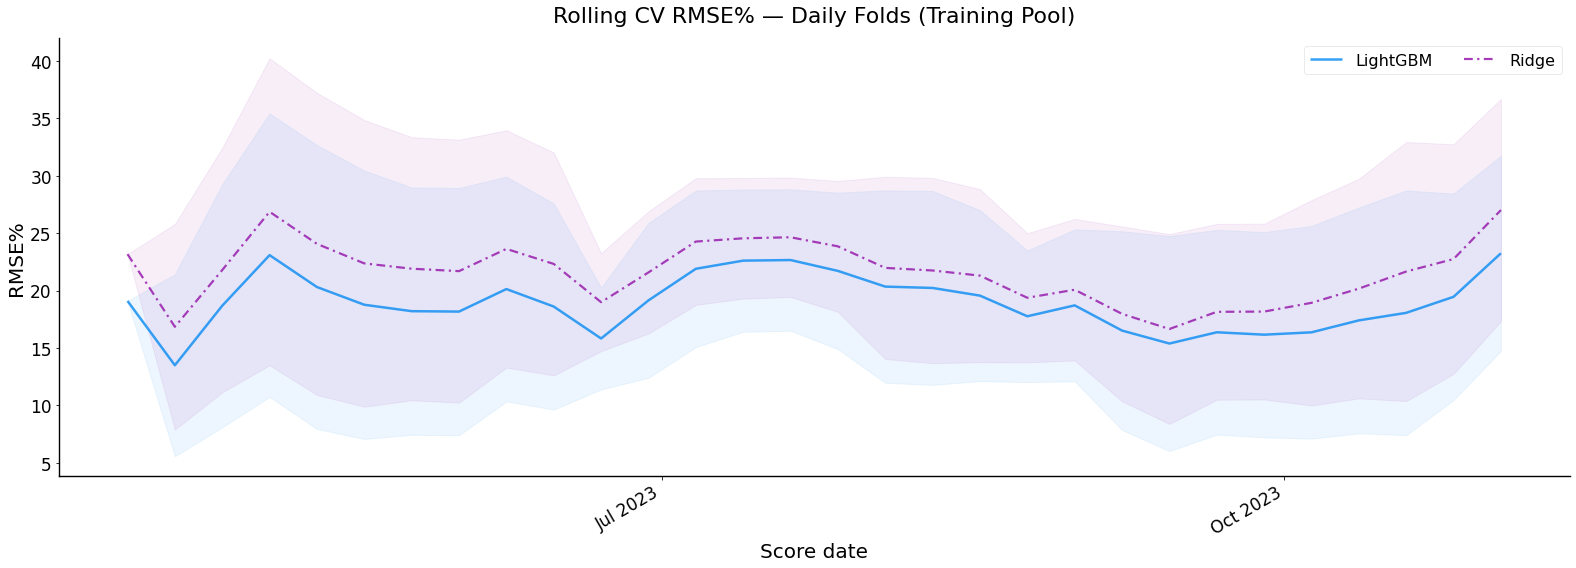

Saved → solar_rolling_cv.png


In [9]:
import matplotlib as mpl
mpl.rcParams.update({
    "font.size":         18,
    "axes.titlesize":    22,
    "axes.labelsize":    20,
    "xtick.labelsize":   17,
    "ytick.labelsize":   17,
    "legend.fontsize":   16,
    "axes.linewidth":    1.4,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

COLORS = {
    "LightGBM":          "#2196F3",
    "XGBoost":           "#FF5722",
    "RandomForest":      "#4CAF50",
    "Ridge":             "#9C27B0",
    "LinearReg":         "#00BCD4",  # cyan
    "MLP":               "#FF9800",   # only shown if USE_MLP=True
    "Persistence":       "#607D8B",
    "Climatology":       "#795548",
    "SmartPersistence":  "#009688",
    "Stacking":          "#F44336",  # red — the ensemble
}
LINESTYLES = {
    "LightGBM":         (0, ()),
    "XGBoost":          (0, (6, 2)),
    "RandomForest":     (0, (2, 2)),
    "Ridge":            (0, (4, 2, 1, 2)),
    "LinearReg":        (0, (2, 1)),
    "MLP":              (0, (1, 1)),
    "Persistence":      (0, (3, 1, 1, 1, 1, 1)),
    "Climatology":      (0, (5, 5)),
    "SmartPersistence": (0, (3, 1)),
    "Stacking":         (0,()),      # solid red — ensemble
}
LINEWIDTHS = {
    "LightGBM": 2.5, "XGBoost": 2.2, "RandomForest": 2.2, "Ridge": 2.2, "LinearReg": 2.0,
    "MLP": 2.2, "Persistence": 1.8, "Climatology": 1.8, "SmartPersistence": 1.8,
    "Stacking":          3.0,
}
# Only show models that were actually trained
MODEL_NAMES = [n for n in COLORS if n in results]


fig, ax = plt.subplots(figsize=(22, 8))
for name, df_ in cv_dfs.items():  # only fast models
    dates     = pd.to_datetime(df_["score_date"])
    roll_mean = df_["rmse_pct"].rolling(7, min_periods=1).mean()
    roll_std  = df_["rmse_pct"].rolling(7, min_periods=1).std().fillna(0)
    ax.plot(dates, roll_mean, color=COLORS[name], linewidth=LINEWIDTHS[name],
            linestyle=LINESTYLES[name], alpha=0.9, label=name)
    ax.fill_between(dates, roll_mean - roll_std, roll_mean + roll_std,
                    color=COLORS[name], alpha=0.08)

ax.set_title("Rolling CV RMSE% — Daily Folds (Training Pool)", pad=16)
ax.set_ylabel("RMSE%")
ax.set_xlabel("Score date")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax.legend(ncol=3, framealpha=0.4)
plt.tight_layout()
plt.savefig("solar_rolling_cv.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → solar_rolling_cv.png")


## 7. 24-Hour Forecast Walk-Through
A 7-day window from the **test set (Jun–Oct 2024)**.

In [10]:
forecast_start = pd.Timestamp("2024-07-15")
forecast_end   = forecast_start + pd.Timedelta(days=7)

window   = df_test_feat[forecast_start:forecast_end]
X_window = window[FEATURES]
y_window = window[TARGET]

MODEL_NAMES = list(results.keys())

window_preds = {}
for name, r in results.items():
    if r["model"] is not None:
        # Standard ML model — predict from raw features
        raw = r["model"].predict(X_window)
        window_preds[name] = nighttime_zero(raw, window)
    elif name == "Stacking":
        # Meta-learner needs meta-features (base model predictions), not raw features
        meta_window_X = np.column_stack([
            window_preds[n] for n in base_names if n in window_preds
        ])
        if meta_window_X.shape[1] == len(base_names):
            meta_window_Xs = _stacking_meta_sc.transform(meta_window_X)
            raw_stack = _stacking_meta.predict(meta_window_Xs)
            window_preds[name] = nighttime_zero(raw_stack, window)
        else:
            # Fallback: slice from pre-computed test preds if base models not ready
            mask = (df_test_feat.index >= forecast_start) & (df_test_feat.index <= forecast_end)
            window_preds[name] = r["preds"][mask]
    else:
        # Baselines — slice from pre-computed full test predictions
        mask = (df_test_feat.index >= forecast_start) & (df_test_feat.index <= forecast_end)
        window_preds[name] = r["preds"][mask]

print(f"7-day window : {forecast_start.date()} → {forecast_end.date()}  ({len(window)} rows)")

# ── 30-day forecast using best ML model ───────────────────────────────────────
best_ml = min(
    [n for n in results if results[n]["model"] is not None],
    key=lambda n: results[n]["rmse_pct"]
)
print(f"Best ML model for 30-day forecast: {best_ml}")

forecast_30_start = pd.Timestamp("2024-07-01")
forecast_30_end   = forecast_30_start + pd.Timedelta(days=30)
window_30   = df_test_feat[forecast_30_start:forecast_30_end]
X_window_30 = window_30[FEATURES]
y_window_30 = window_30[TARGET]

preds_30_raw = results[best_ml]["model"].predict(X_window_30)
preds_30     = nighttime_zero(preds_30_raw, window_30)
rmse_30      = rmse_pct(y_window_30.values, preds_30)
print(f"30-day forecast RMSE%: {rmse_30:.2f}%")


7-day window : 2024-07-15 → 2024-07-22  (673 rows)
Best ML model for 30-day forecast: RandomForest
30-day forecast RMSE%: 14.60%


In [11]:
daily_rmse_pct = {}
dates = pd.date_range(forecast_start, forecast_end - pd.Timedelta(days=1), freq="D")

for name in results:
    day_errors = []
    for d in dates:
        mask = (window.index >= d) & (window.index < d + pd.Timedelta(days=1))
        y_d = y_window[mask].values
        p_d = window_preds[name][mask]
        dt  = y_d > 10
        if dt.sum() == 0:
            day_errors.append(np.nan)
        else:
            r = np.sqrt(mean_squared_error(y_d[dt], p_d[dt]))
            day_errors.append((r / y_d[dt].mean()) * 100)
    daily_rmse_pct[name] = day_errors

daily_df = pd.DataFrame(daily_rmse_pct, index=[d.strftime("%b %d") for d in dates])
print("Per-day RMSE% — Forecast Window")
print(daily_df.round(2).to_string())


Per-day RMSE% — Forecast Window
        LightGBM  XGBoost  RandomForest  Ridge  LinearReg    MLP  Stacking  Persistence  Climatology  SmartPersistence
Jul 15      9.26     8.83          9.55   7.79       7.80   7.51      5.04        27.90        18.04             26.77
Jul 16     71.80    69.47         70.73  72.60      72.60  69.01     73.34        71.65        66.77             74.98
Jul 17     12.51    14.28          9.60  12.59      12.59  22.96     11.04        56.27        21.17             56.37
Jul 18     13.16     9.27          5.12   6.98       6.99  10.24      6.69         3.64        18.35              3.19
Jul 19      8.87     6.93          3.20  11.58      11.57   7.73      3.97         4.37        16.22              4.36
Jul 20      8.84     8.86          5.65   6.97       6.99   5.95      5.02         4.72        13.22              2.72
Jul 21      4.23     3.67          5.27   4.54       4.58   7.44      4.90         4.80        16.61              2.97


## 8. Diagnostic & Comparison Plots

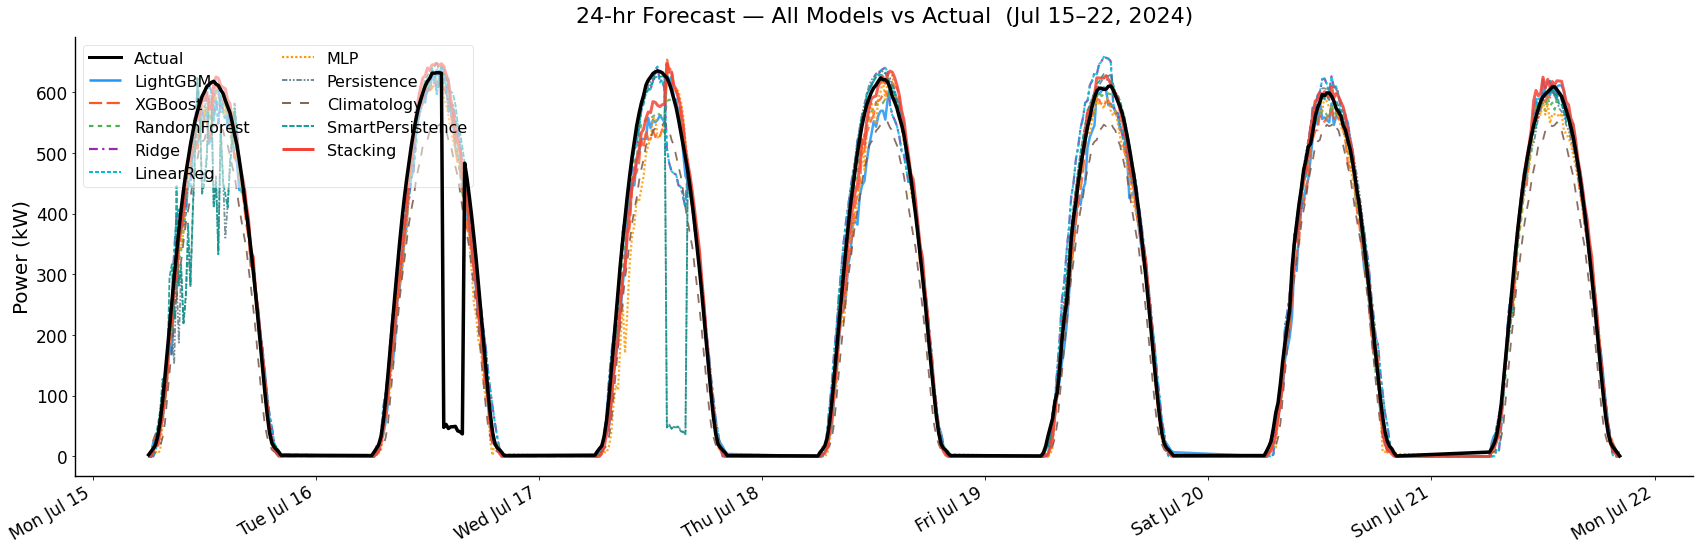

Saved → fig1_week_timeline.png


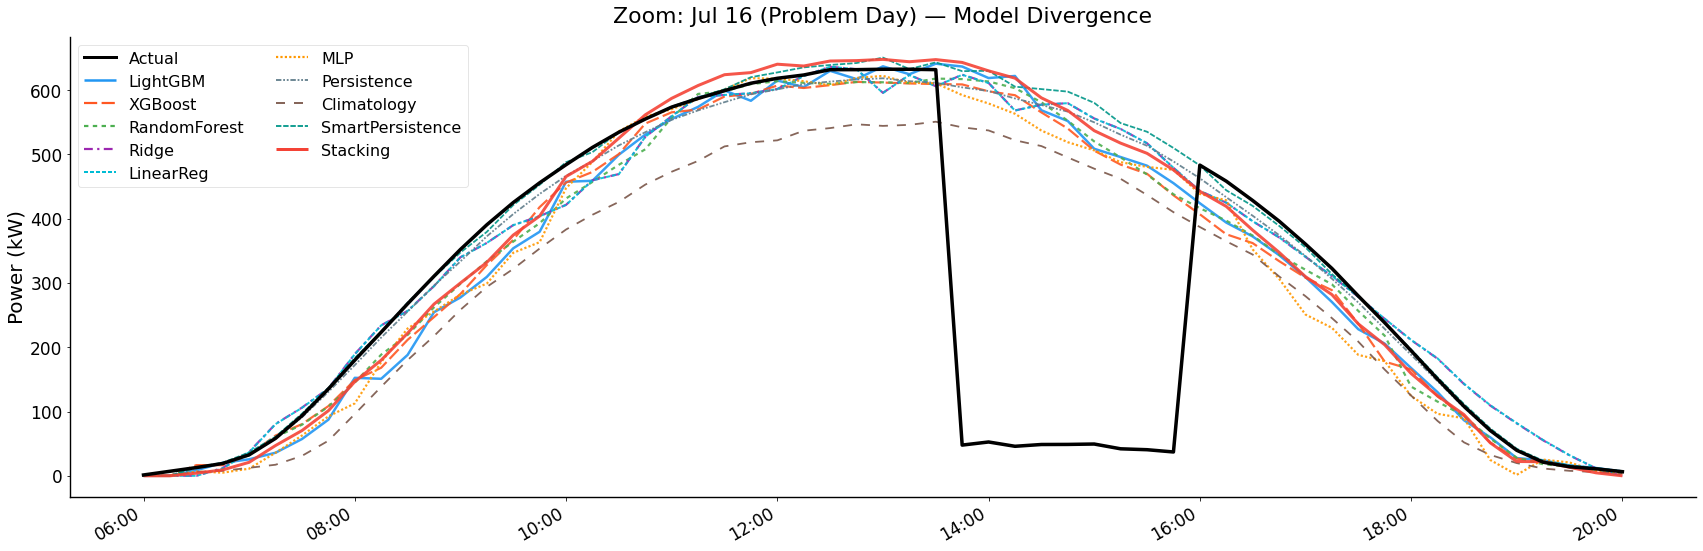

Saved → fig2_zoom_jul16.png


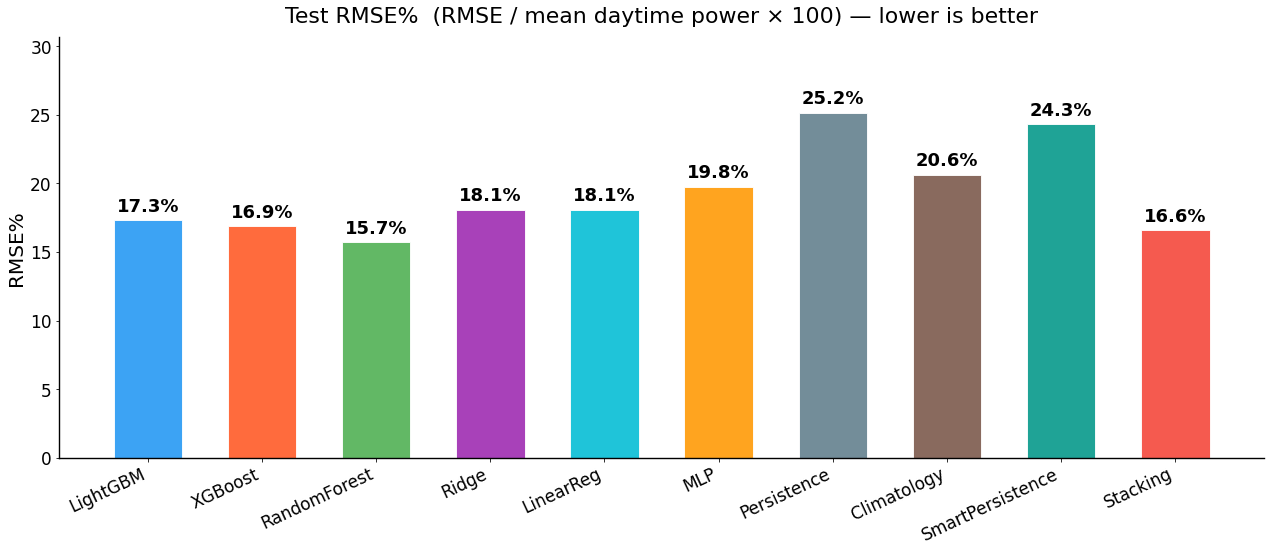

Saved → fig3_test_rmse.png


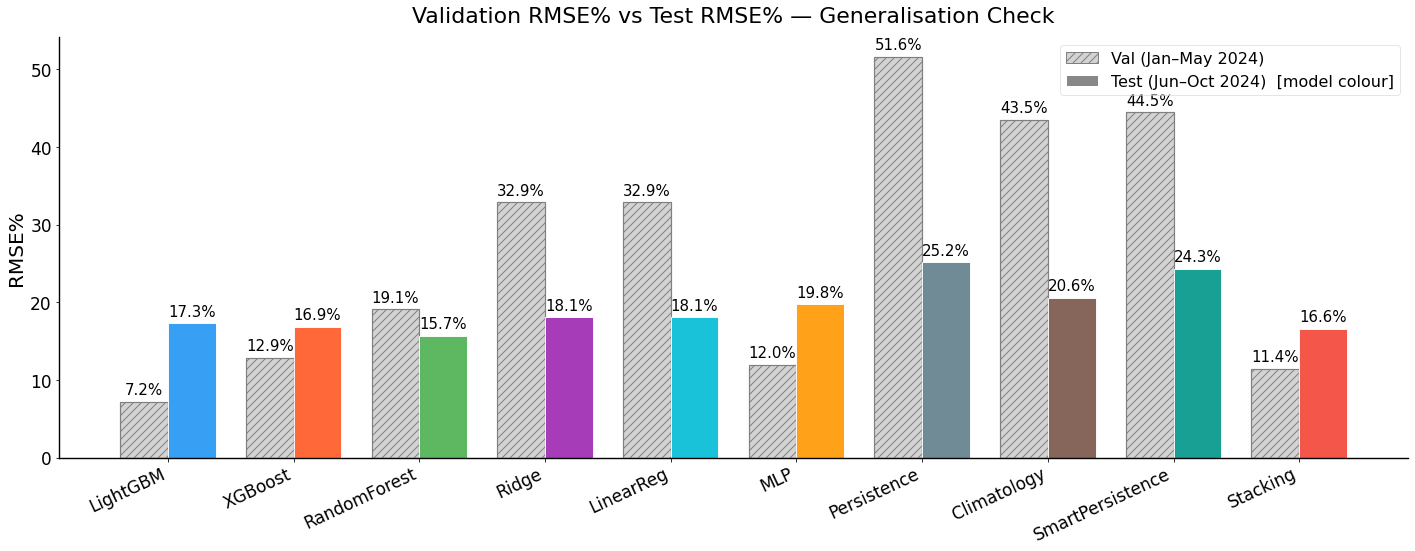

Saved → fig4_val_vs_test.png


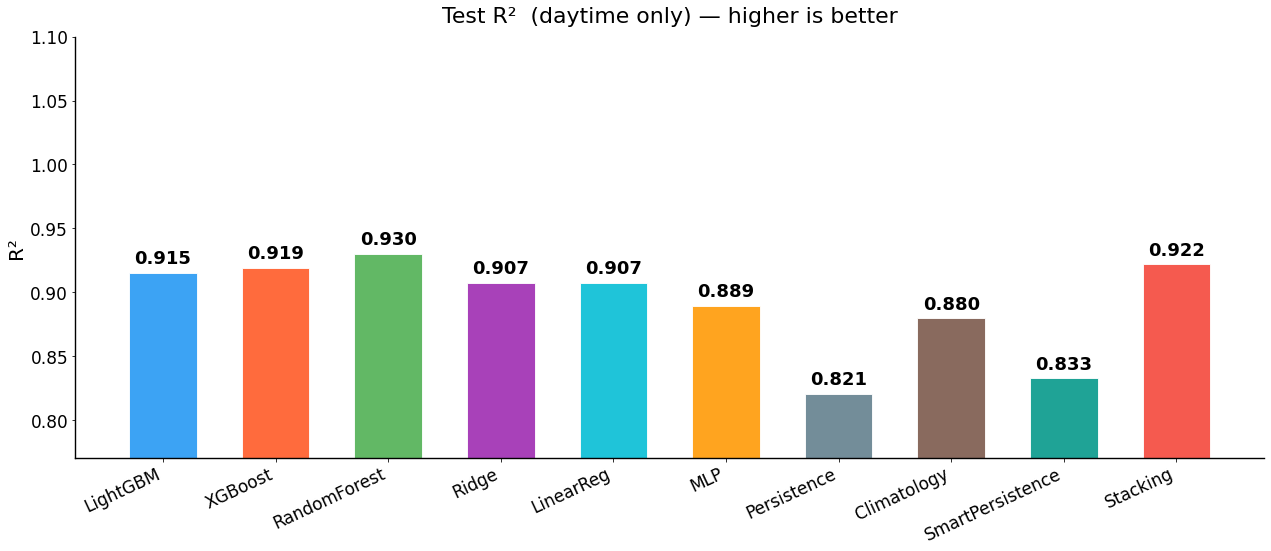

Saved → fig5_r2.png


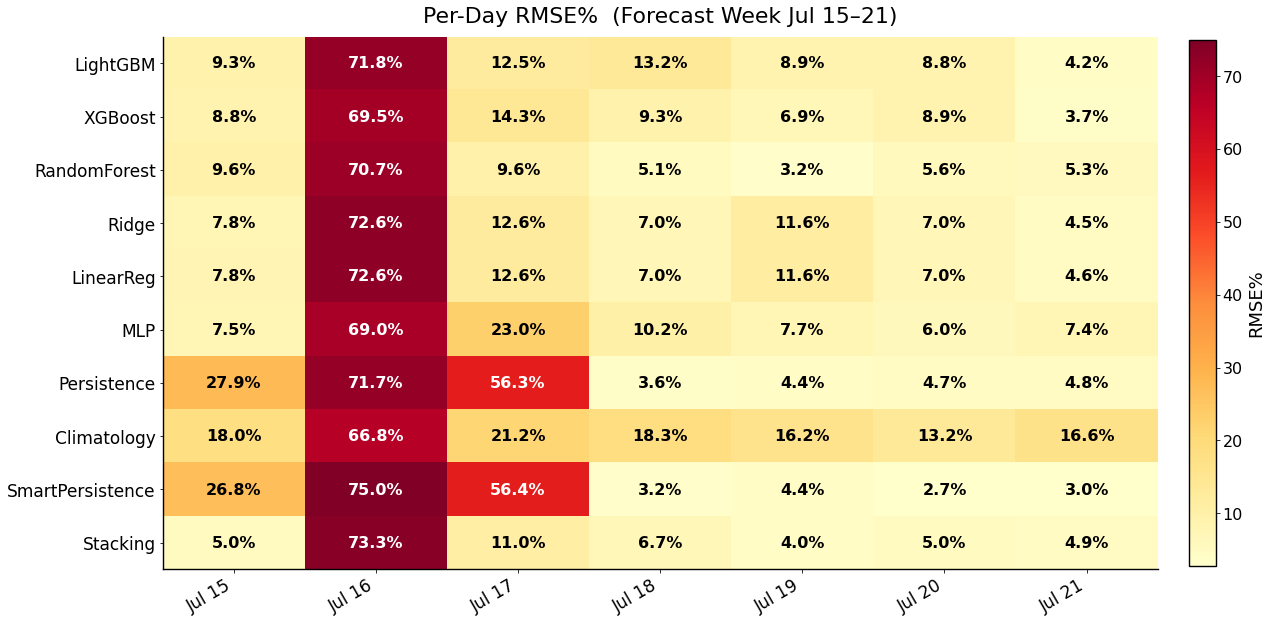

Saved → fig6_heatmap.png


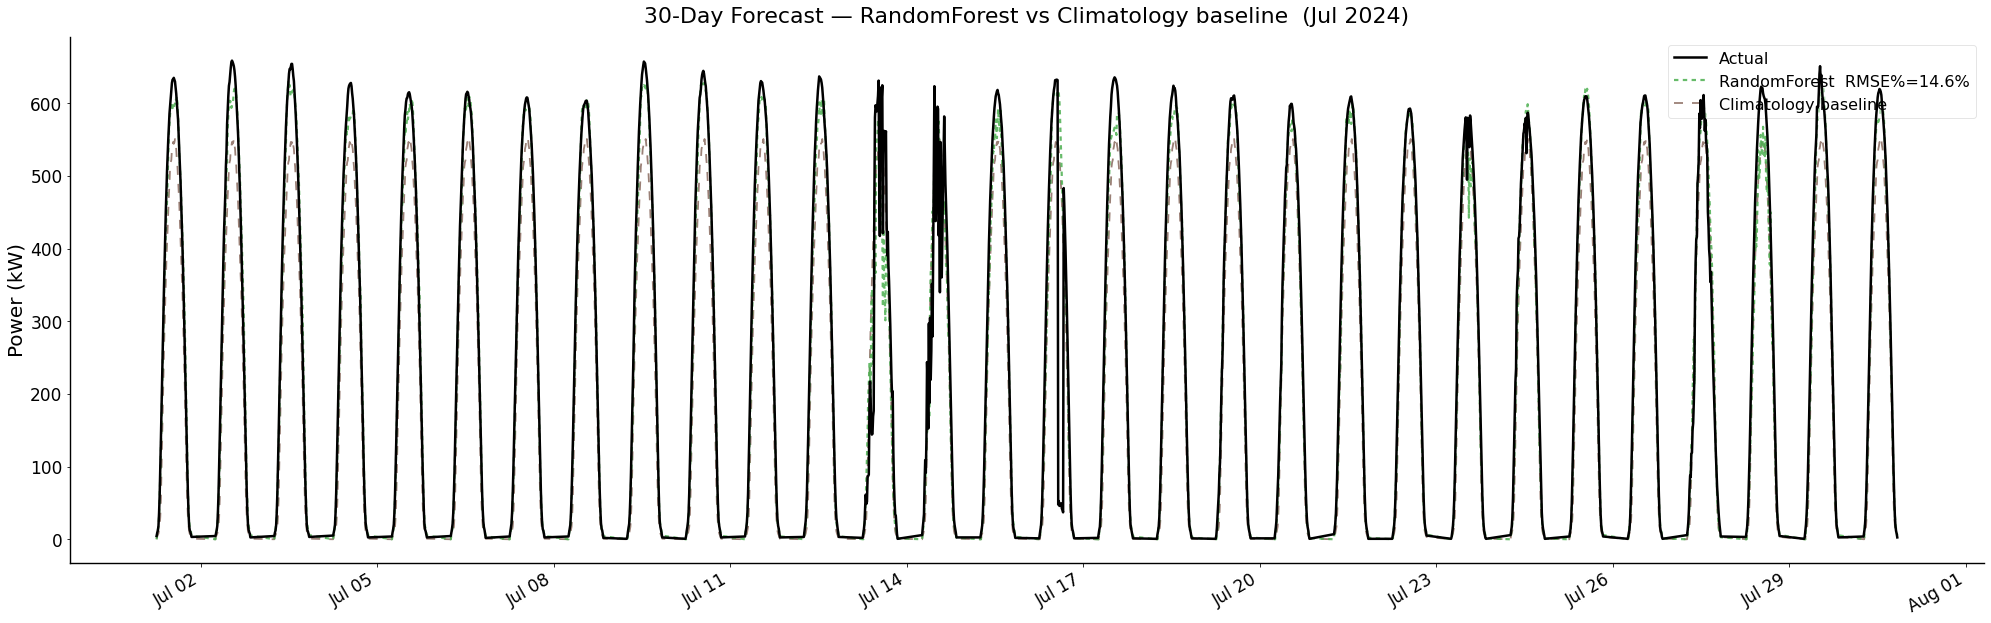

Saved → fig7_30day_forecast.png


In [12]:
import matplotlib as mpl
mpl.rcParams.update({
    "font.size":         18,
    "axes.titlesize":    22,
    "axes.labelsize":    20,
    "xtick.labelsize":   17,
    "ytick.labelsize":   17,
    "legend.fontsize":   16,
    "axes.linewidth":    1.4,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

COLORS = {
    "LightGBM":          "#2196F3",
    "XGBoost":           "#FF5722",
    "RandomForest":      "#4CAF50",
    "Ridge":             "#9C27B0",
    "LinearReg":         "#00BCD4",  # cyan
    "MLP":               "#FF9800",   # only shown if USE_MLP=True
    "Persistence":       "#607D8B",
    "Climatology":       "#795548",
    "SmartPersistence":  "#009688",
    "Stacking":          "#F44336",  # red — the ensemble
}
LINESTYLES = {
    "LightGBM":         (0, ()),
    "XGBoost":          (0, (6, 2)),
    "RandomForest":     (0, (2, 2)),
    "Ridge":            (0, (4, 2, 1, 2)),
    "LinearReg":        (0, (2, 1)),
    "MLP":              (0, (1, 1)),
    "Persistence":      (0, (3, 1, 1, 1, 1, 1)),
    "Climatology":      (0, (5, 5)),
    "SmartPersistence": (0, (3, 1)),
    "Stacking":         (0,()),      # solid red — ensemble
}
LINEWIDTHS = {
    "LightGBM": 2.5, "XGBoost": 2.2, "RandomForest": 2.2, "Ridge": 2.2, "LinearReg": 2.0,
    "MLP": 2.2, "Persistence": 1.8, "Climatology": 1.8, "SmartPersistence": 1.8,
    "Stacking":          3.0,
}
# Only show models that were actually trained
MODEL_NAMES = [n for n in COLORS if n in results]


zoom_start = pd.Timestamp("2024-07-16 06:00")
zoom_end   = pd.Timestamp("2024-07-16 20:00")
zm         = (window.index >= zoom_start) & (window.index <= zoom_end)
daytime_window = y_window > 0

legend_handles = (
    [plt.Line2D([0],[0], color="black", linewidth=3, label="Actual")] +
    [plt.Line2D([0],[0], color=COLORS[n], linewidth=LINEWIDTHS[n],
                linestyle=LINESTYLES[n], label=n) for n in MODEL_NAMES]
)

# ── Fig 1: Full week timeline ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(24, 8))
ax.plot(window.index[daytime_window], y_window[daytime_window],
        color="black", linewidth=3.5, label="Actual", zorder=10)
for name in MODEL_NAMES:
    p = window_preds[name]
    ax.plot(window.index[daytime_window], p[daytime_window],
            color=COLORS[name], linewidth=LINEWIDTHS[name],
            linestyle=LINESTYLES[name], alpha=0.85, zorder=5)
ax.set_title("24-hr Forecast — All Models vs Actual  (Jul 15–22, 2024)", pad=14)
ax.set_ylabel("Power (kW)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %b %d"))
ax.xaxis.set_major_locator(mdates.DayLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax.legend(handles=legend_handles, ncol=2, framealpha=0.5, loc="upper left")
plt.tight_layout()
plt.savefig("fig1_week_timeline.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → fig1_week_timeline.png")

# ── Fig 2: Zoom Jul 16 ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(24, 8))
ax.plot(window.index[zm], y_window[zm], color="black", linewidth=3.5, zorder=10, label="Actual")
for name in MODEL_NAMES:
    p = window_preds[name]
    ax.plot(window.index[zm], p[zm],
            color=COLORS[name], linewidth=LINEWIDTHS[name],
            linestyle=LINESTYLES[name], alpha=0.9, zorder=5)
ax.set_title("Zoom: Jul 16 (Problem Day) — Model Divergence", pad=14)
ax.set_ylabel("Power (kW)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.xaxis.set_major_locator(mdates.HourLocator(byhour=[6,8,10,12,14,16,18,20]))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax.legend(handles=legend_handles, ncol=2, framealpha=0.5, loc="upper left")
plt.tight_layout()
plt.savefig("fig2_zoom_jul16.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → fig2_zoom_jul16.png")

# ── Fig 3: Test RMSE% bar ─────────────────────────────────────────────────────
rmse_pct_vals = [results[n]["rmse_pct"] for n in MODEL_NAMES]
fig, ax = plt.subplots(figsize=(18, 8))
bars = ax.bar(MODEL_NAMES, rmse_pct_vals,
              color=[COLORS[n] for n in MODEL_NAMES], alpha=0.88, edgecolor="white", width=0.6)
ax.bar_label(bars, fmt="%.1f%%", fontsize=18, padding=5, fontweight="bold")
ax.set_title("Test RMSE%  (RMSE / mean daytime power × 100) — lower is better", pad=14)
ax.set_ylabel("RMSE%")
ax.set_ylim(0, max(rmse_pct_vals) * 1.22)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25, ha="right")
plt.tight_layout()
plt.savefig("fig3_test_rmse.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → fig3_test_rmse.png")

# ── Fig 4: Val vs Test RMSE% ──────────────────────────────────────────────────
val_rmse_pct_vals = [results[n]["val_rmse_pct"] for n in MODEL_NAMES]
x = np.arange(len(MODEL_NAMES)); width = 0.38
fig, ax = plt.subplots(figsize=(20, 8))
bv = ax.bar(x - width/2, val_rmse_pct_vals, width,
            color="lightgrey", edgecolor="grey", hatch="///", linewidth=1.2)
bt = ax.bar(x + width/2, rmse_pct_vals, width,
            color=[COLORS[n] for n in MODEL_NAMES], alpha=0.9, edgecolor="white")
ax.bar_label(bv, fmt="%.1f%%", fontsize=15, padding=4)
ax.bar_label(bt, fmt="%.1f%%", fontsize=15, padding=4)
ax.set_xticks(x)
ax.set_xticklabels(MODEL_NAMES, rotation=25, ha="right")
ax.set_title("Validation RMSE% vs Test RMSE% — Generalisation Check", pad=14)
ax.set_ylabel("RMSE%")
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="lightgrey", edgecolor="grey", hatch="///", label="Val (Jan–May 2024)"),
    Patch(facecolor="#888888",   edgecolor="white",             label="Test (Jun–Oct 2024)  [model colour]"),
], framealpha=0.5, loc="upper right")
plt.tight_layout()
plt.savefig("fig4_val_vs_test.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → fig4_val_vs_test.png")

# ── Fig 5: R² bar ─────────────────────────────────────────────────────────────
r2_vals = [results[n]["r2"] for n in MODEL_NAMES]
fig, ax = plt.subplots(figsize=(18, 8))
bars4 = ax.bar(MODEL_NAMES, r2_vals,
               color=[COLORS[n] for n in MODEL_NAMES], alpha=0.88, edgecolor="white", width=0.6)
ax.bar_label(bars4, fmt="%.3f", fontsize=18, padding=5, fontweight="bold")
ax.set_title("Test R²  (daytime only) — higher is better", pad=14)
ax.set_ylabel("R²")
ax.set_ylim(min(r2_vals) - 0.05, 1.1)
ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.4)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25, ha="right")
plt.tight_layout()
plt.savefig("fig5_r2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → fig5_r2.png")

# ── Fig 6: Per-day RMSE% heatmap ──────────────────────────────────────────────
hmap = np.array([daily_rmse_pct[n] for n in MODEL_NAMES], dtype=float)
fig, ax = plt.subplots(figsize=(18, 9))
im = ax.imshow(hmap, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(daily_df.index)))
ax.set_xticklabels(daily_df.index, rotation=30, ha="right")
ax.set_yticks(range(len(MODEL_NAMES)))
ax.set_yticklabels(MODEL_NAMES)
ax.set_title("Per-Day RMSE%  (Forecast Week Jul 15–21)", pad=14)
for i in range(len(MODEL_NAMES)):
    for j in range(len(daily_df.index)):
        val = hmap[i, j]
        txt = f"{val:.1f}%" if not np.isnan(val) else "—"
        ax.text(j, i, txt, ha="center", va="center", fontsize=16, fontweight="bold",
                color="black" if val < np.nanmax(hmap)*0.7 else "white")
cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.03)
cbar.set_label("RMSE%", fontsize=18)
cbar.ax.tick_params(labelsize=16)
plt.tight_layout()
plt.savefig("fig6_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → fig6_heatmap.png")

# ── Fig 7: 30-day forecast ────────────────────────────────────────────────────
best_ml = min([n for n in results if results[n]["model"] is not None and n not in BASELINE_NAMES],
              key=lambda n: results[n]["rmse_pct"])
best_bl = min(BASELINE_NAMES, key=lambda b: results[b]["rmse_pct"])

forecast_30_start = pd.Timestamp("2024-07-01")
forecast_30_end   = forecast_30_start + pd.Timedelta(days=30)
window_30   = df_test_feat[forecast_30_start:forecast_30_end]
X_window_30 = window_30[FEATURES]
y_window_30 = window_30[TARGET]

preds_30_raw = results[best_ml]["model"].predict(X_window_30)
preds_30     = nighttime_zero(preds_30_raw, window_30)
rmse_30      = rmse_pct(y_window_30.values, preds_30)

mask_30 = (df_test_feat.index >= forecast_30_start) & (df_test_feat.index <= forecast_30_end)
bl_30   = results[best_bl]["preds"][mask_30]

dt_30 = y_window_30 > 0
fig, ax = plt.subplots(figsize=(28, 9))
ax.plot(window_30.index[dt_30], y_window_30[dt_30],
        color="black", linewidth=2.5, label="Actual", zorder=10)
ax.plot(window_30.index[dt_30], preds_30[dt_30],
        color=COLORS[best_ml], linewidth=2.2, linestyle=LINESTYLES[best_ml],
        alpha=0.85, label=f"{best_ml}  RMSE%={rmse_30:.1f}%", zorder=5)
ax.plot(window_30.index[dt_30], bl_30[dt_30],
        color=COLORS[best_bl], linewidth=1.8, linestyle=LINESTYLES[best_bl],
        alpha=0.75, label=f"{best_bl} baseline", zorder=4)
ax.set_title(f"30-Day Forecast — {best_ml} vs {best_bl} baseline  (Jul 2024)", pad=14)
ax.set_ylabel("Power (kW)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax.legend(framealpha=0.5, loc="upper right")
plt.tight_layout()
plt.savefig("fig7_30day_forecast.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → fig7_30day_forecast.png")


## 9. Additional Diagnostics

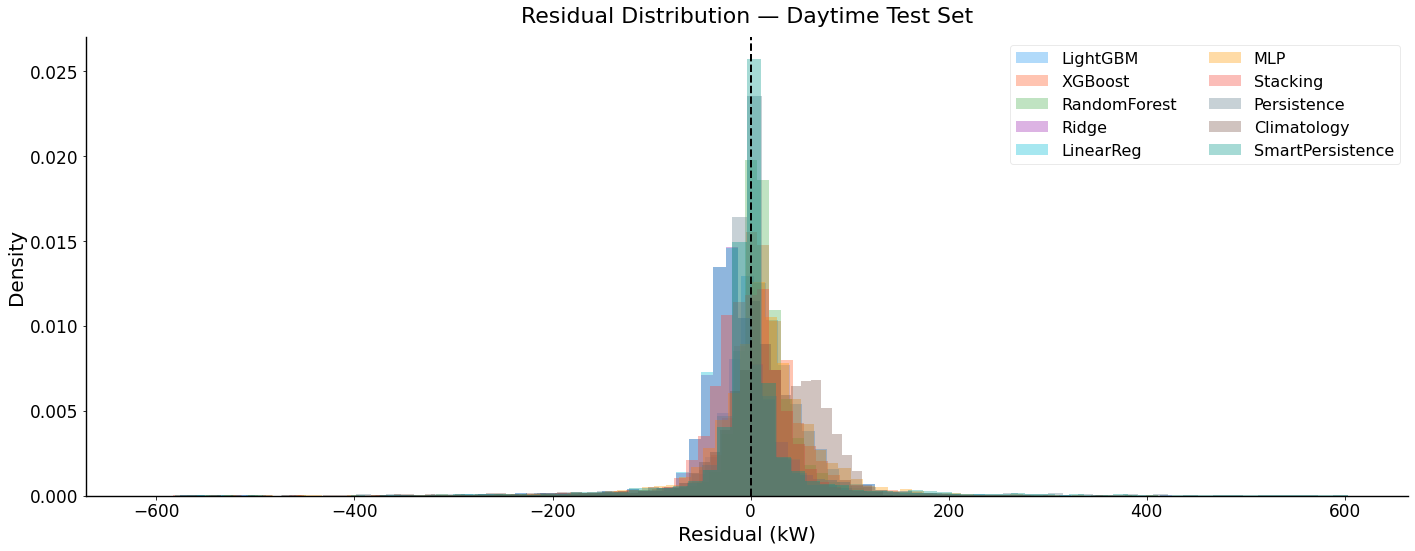

Saved → fig8_residuals.png


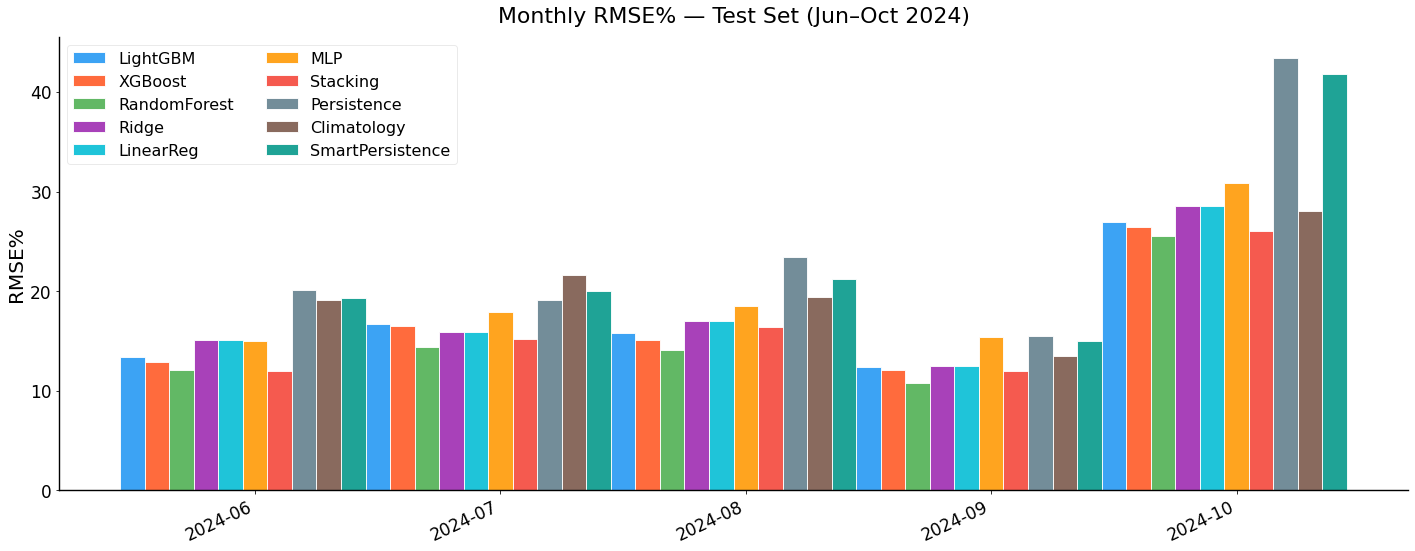

Saved → fig9_monthly_rmse.png


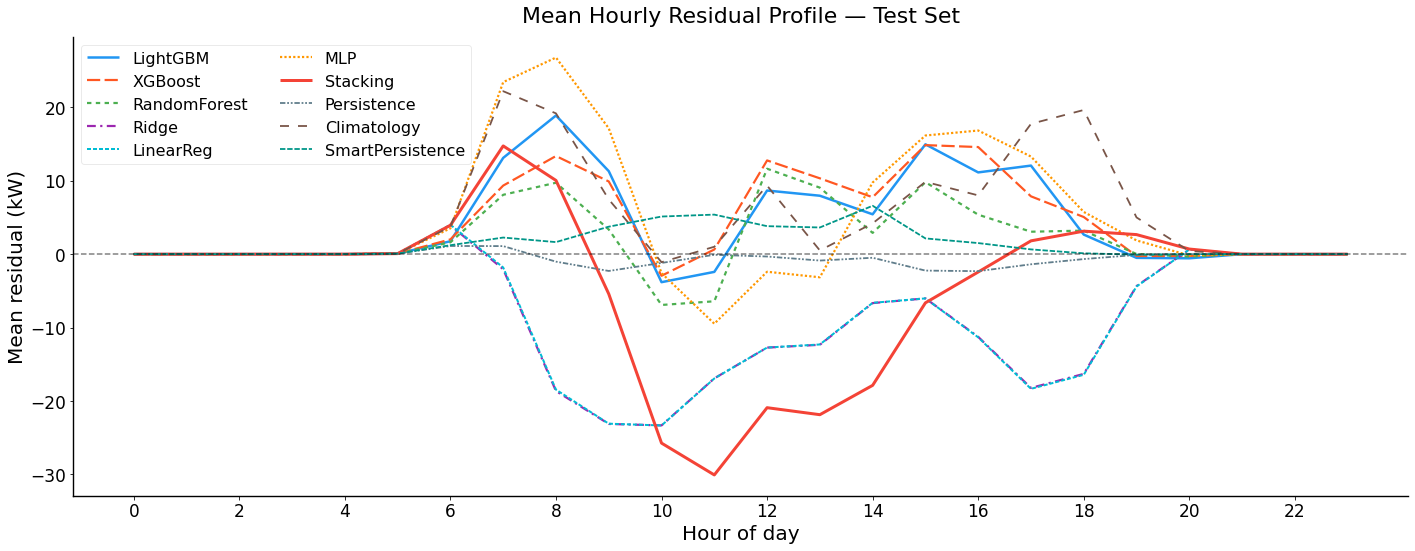

Saved → fig10_hourly_residual.png


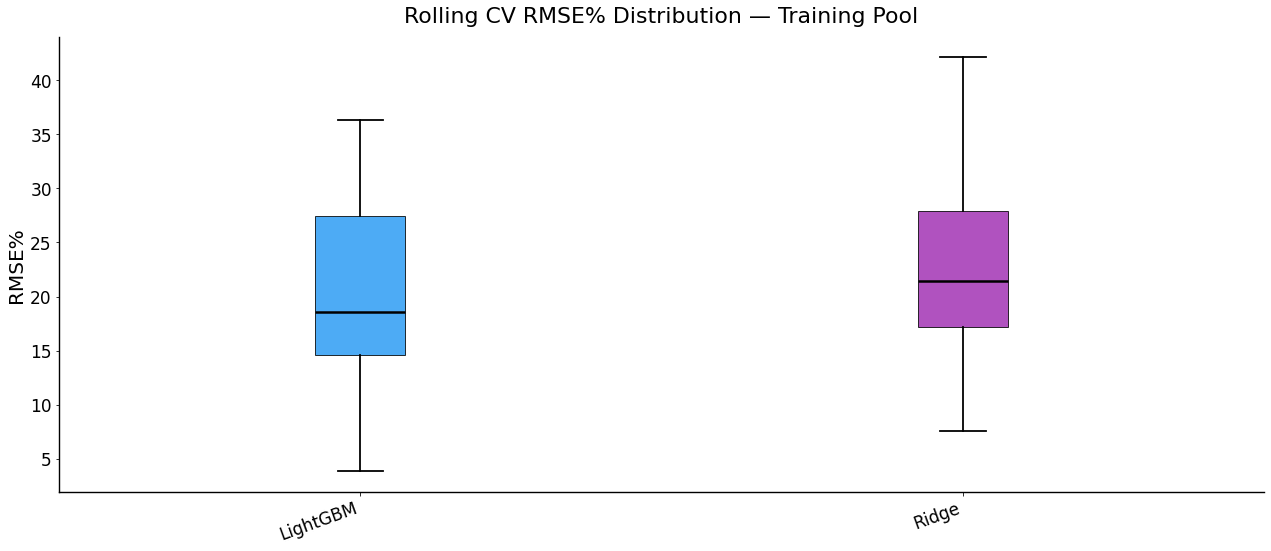

Saved → fig11_cv_boxplot.png


In [13]:
import matplotlib as mpl
mpl.rcParams.update({
    "font.size":         18,
    "axes.titlesize":    22,
    "axes.labelsize":    20,
    "xtick.labelsize":   17,
    "ytick.labelsize":   17,
    "legend.fontsize":   16,
    "axes.linewidth":    1.4,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

COLORS = {
    "LightGBM":          "#2196F3",
    "XGBoost":           "#FF5722",
    "RandomForest":      "#4CAF50",
    "Ridge":             "#9C27B0",
    "LinearReg":         "#00BCD4",  # cyan
    "MLP":               "#FF9800",   # only shown if USE_MLP=True
    "Persistence":       "#607D8B",
    "Climatology":       "#795548",
    "SmartPersistence":  "#009688",
    "Stacking":          "#F44336",  # red — the ensemble
}
LINESTYLES = {
    "LightGBM":         (0, ()),
    "XGBoost":          (0, (6, 2)),
    "RandomForest":     (0, (2, 2)),
    "Ridge":            (0, (4, 2, 1, 2)),
    "LinearReg":        (0, (2, 1)),
    "MLP":              (0, (1, 1)),
    "Persistence":      (0, (3, 1, 1, 1, 1, 1)),
    "Climatology":      (0, (5, 5)),
    "SmartPersistence": (0, (3, 1)),
    "Stacking":         (0,()),      # solid red — ensemble
}
LINEWIDTHS = {
    "LightGBM": 2.5, "XGBoost": 2.2, "RandomForest": 2.2, "Ridge": 2.2, "LinearReg": 2.0,
    "MLP": 2.2, "Persistence": 1.8, "Climatology": 1.8, "SmartPersistence": 1.8,
    "Stacking":          3.0,
}
# Only show models that were actually trained
MODEL_NAMES = [n for n in COLORS if n in results]


MODEL_NAMES = list(results.keys())

# ── Fig 8: Residual distribution ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 8))
for name in MODEL_NAMES:
    dt = y_test > 10
    residuals = y_test.values[dt] - results[name]["preds"][dt]
    ax.hist(residuals, bins=80, alpha=0.35, color=COLORS[name],
            label=name, density=True, linewidth=0)
ax.axvline(0, color="black", linewidth=2, linestyle="--")
ax.set_title("Residual Distribution — Daytime Test Set", pad=14)
ax.set_xlabel("Residual (kW)")
ax.set_ylabel("Density")
ax.legend(ncol=2, framealpha=0.4)
plt.tight_layout()
plt.savefig("fig8_residuals.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → fig8_residuals.png")

# ── Fig 9: Monthly RMSE% ──────────────────────────────────────────────────────
months = df_test_feat.index.to_period("M").unique()
x = np.arange(len(months))
width = 0.1
fig, ax = plt.subplots(figsize=(20, 8))
for i, name in enumerate(MODEL_NAMES):
    monthly_errs = []
    for m in months:
        mask = df_test_feat.index.to_period("M") == m
        yt = y_test[mask].values
        yp = results[name]["preds"][mask]
        monthly_errs.append(rmse_pct(yt, yp))
    ax.bar(x + i * width, monthly_errs, width,
           color=COLORS[name], alpha=0.88, label=name, edgecolor="white")
ax.set_xticks(x + width * len(MODEL_NAMES) / 2)
ax.set_xticklabels([str(m) for m in months], rotation=25, ha="right")
# Mark anomaly days on the monthly plot
anomaly_months = {d.strftime('%Y-%m') for d in anomaly_dates_test}
ax.set_title("Monthly RMSE% — Test Set (Jun–Oct 2024)", pad=14)
ax.set_ylabel("RMSE%")
ax.legend(ncol=2, framealpha=0.4)
plt.tight_layout()
plt.savefig("fig9_monthly_rmse.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → fig9_monthly_rmse.png")

# ── Fig 10: Mean hourly residual profile ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 8))
for name in MODEL_NAMES:
    err_df = pd.DataFrame({
        "hour":     df_test_feat.index.hour,
        "residual": y_test.values - results[name]["preds"],
    })
    profile = err_df.groupby("hour")["residual"].mean()
    ax.plot(profile.index, profile.values,
            color=COLORS[name], linewidth=LINEWIDTHS[name],
            linestyle=LINESTYLES[name], label=name)
ax.axhline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.5)
ax.set_title("Mean Hourly Residual Profile — Test Set", pad=14)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean residual (kW)")
ax.set_xticks(range(0, 24, 2))
ax.legend(ncol=2, framealpha=0.4)
plt.tight_layout()
plt.savefig("fig10_hourly_residual.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → fig10_hourly_residual.png")

# ── Fig 11: Rolling CV RMSE% boxplot ──────────────────────────────────────────
cv_model_names = [n for n in MODEL_NAMES if n in cv_dfs]
bp_data = [cv_dfs[n]["rmse_pct"].values for n in cv_model_names]
fig, ax = plt.subplots(figsize=(18, 8))
bp = ax.boxplot(bp_data, patch_artist=True, notch=False,
                medianprops=dict(color="black", linewidth=2.5),
                whiskerprops=dict(linewidth=1.8),
                capprops=dict(linewidth=1.8),
                flierprops=dict(marker="o", markersize=5, alpha=0.4))
for patch, name in zip(bp["boxes"], cv_model_names):
    patch.set_facecolor(COLORS[name])
    patch.set_alpha(0.8)
ax.set_xticklabels(cv_model_names, rotation=20, ha="right")
ax.set_title("Rolling CV RMSE% Distribution — Training Pool", pad=14)
ax.set_ylabel("RMSE%")
plt.tight_layout()
plt.savefig("fig11_cv_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → fig11_cv_boxplot.png")


## 10. Feature Importance (Tree Models)

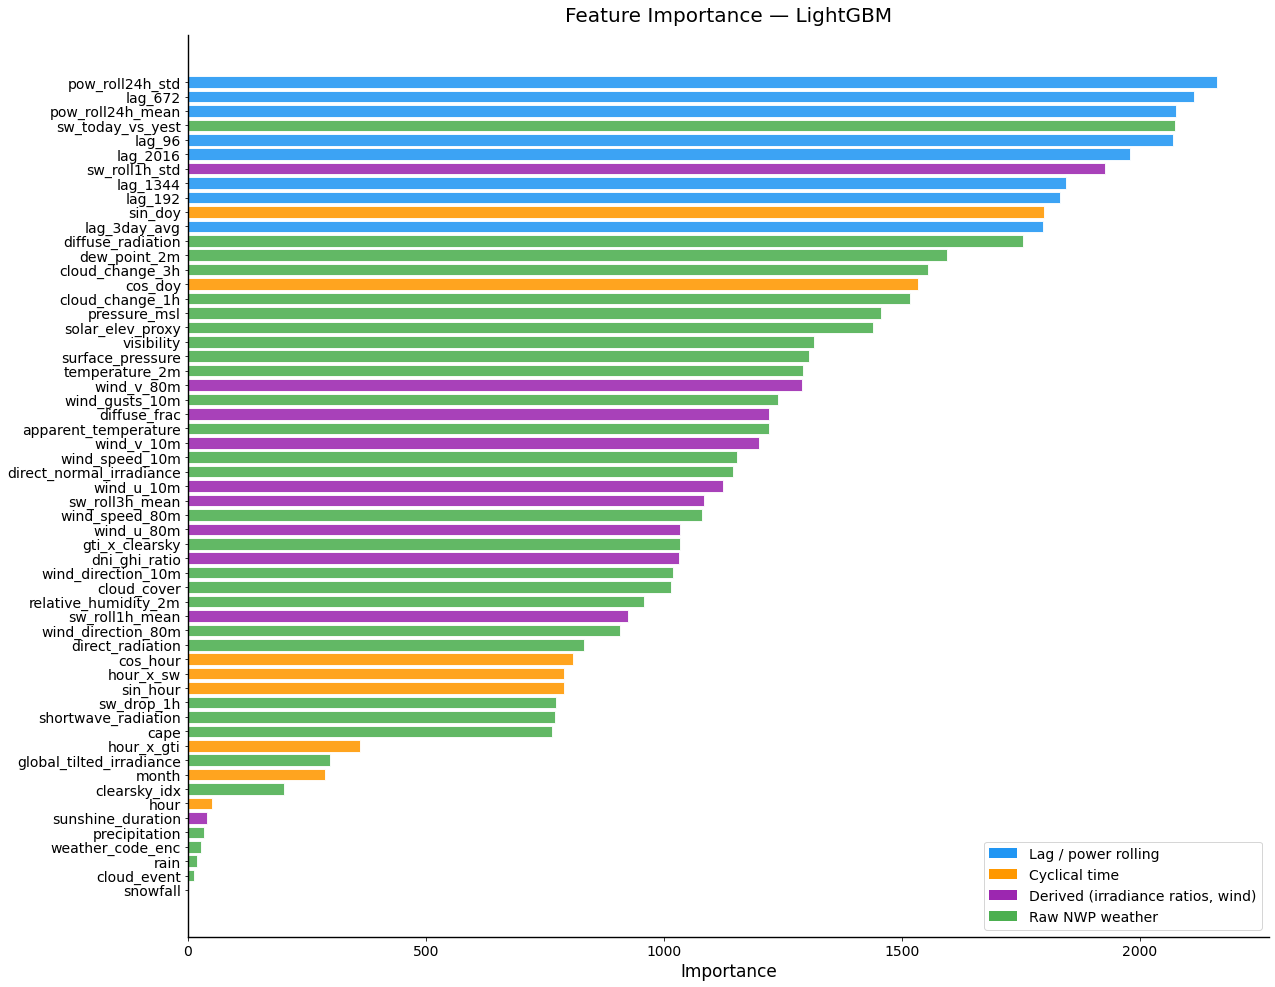

Saved → fig12_feat_imp_lightgbm.png


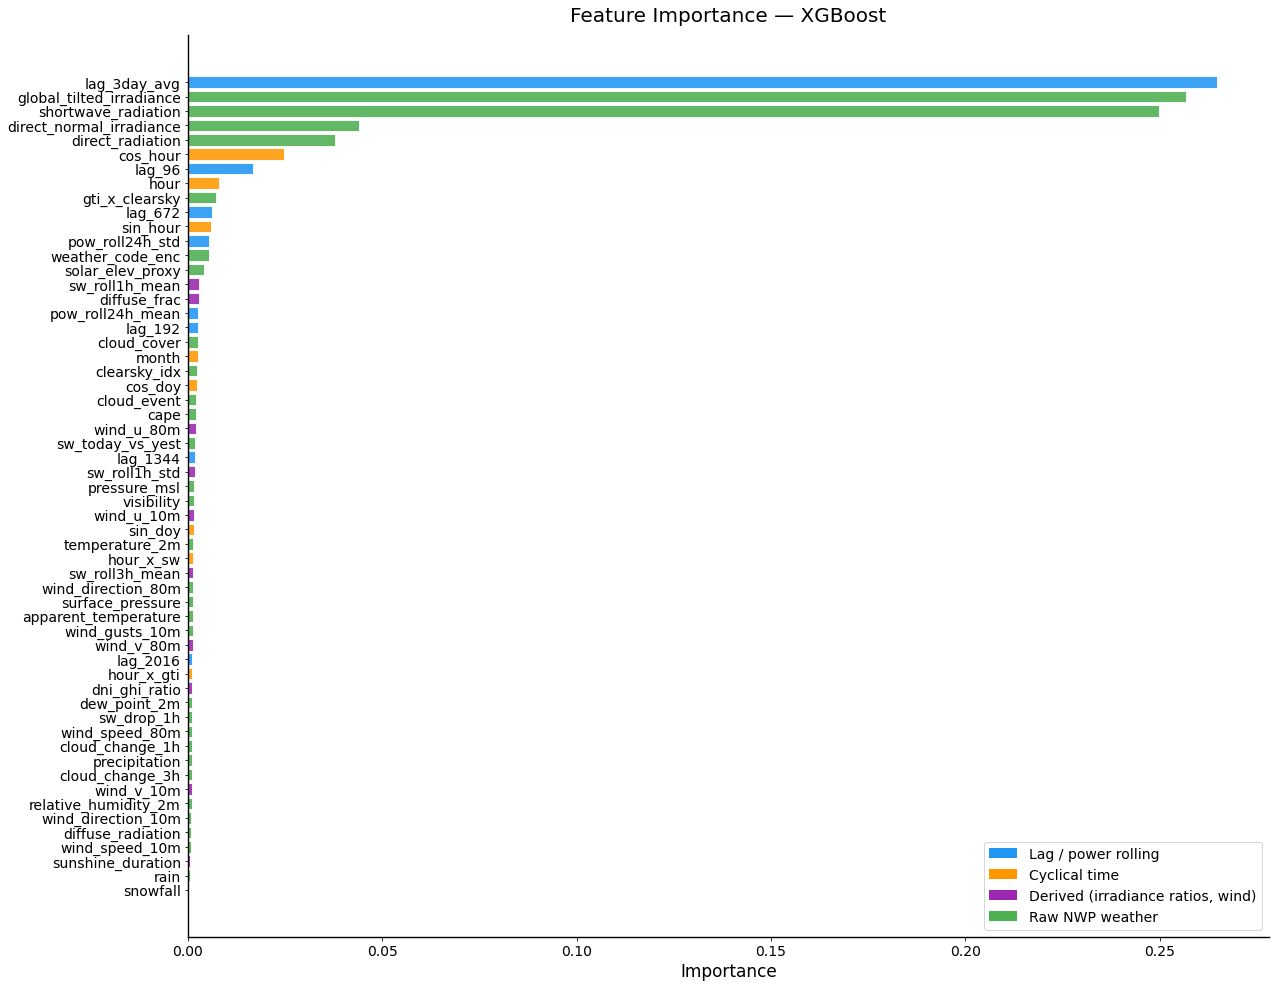

Saved → fig12_feat_imp_xgboost.png


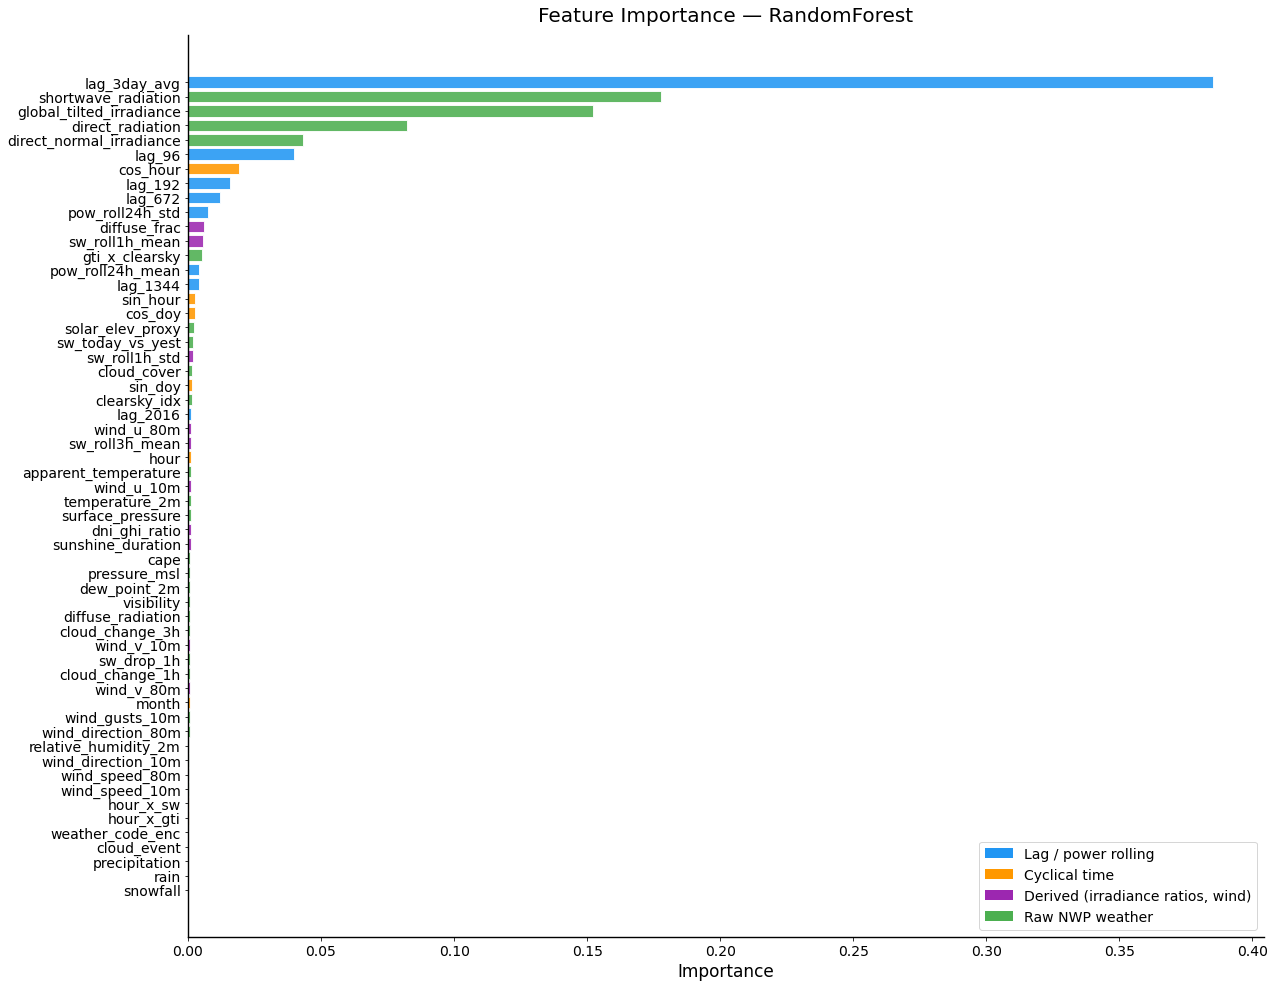

Saved → fig12_feat_imp_randomforest.png


In [14]:
tree_models = [n for n in ["LightGBM","XGBoost","RandomForest"] if n in results]

import matplotlib as mpl
mpl.rcParams.update({"font.size": 16, "axes.titlesize": 20,
                     "axes.labelsize": 17, "xtick.labelsize": 14, "ytick.labelsize": 14})

from matplotlib.patches import Patch
legend_els = [
    Patch(facecolor="#2196F3", label="Lag / power rolling"),
    Patch(facecolor="#FF9800", label="Cyclical time"),
    Patch(facecolor="#9C27B0", label="Derived (irradiance ratios, wind)"),
    Patch(facecolor="#4CAF50", label="Raw NWP weather"),
]

for name in tree_models:
    model = results[name]["model"]
    importances = model.feature_importances_
    imp_df = (pd.DataFrame({"feature": FEATURES, "importance": importances})
                .sort_values("importance"))

    def feat_color(f):
        if "lag_" in f or "pow_roll" in f:                                    return "#2196F3"
        if any(x in f for x in ["sin_","cos_","hour","month"]):               return "#FF9800"
        if any(x in f for x in ["roll","wind_u","wind_v","ratio","frac"]):    return "#9C27B0"
        return "#4CAF50"

    colors_f = [feat_color(f) for f in imp_df["feature"]]
    fig, ax = plt.subplots(figsize=(18, 14))
    ax.barh(imp_df["feature"], imp_df["importance"], color=colors_f, alpha=0.88, edgecolor="white")
    ax.set_title(f"Feature Importance — {name}", pad=14)
    ax.set_xlabel("Importance")
    ax.legend(handles=legend_els, fontsize=14, loc="lower right")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    fname = f"fig12_feat_imp_{name.lower()}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {fname}")


## 11. Summary

In [16]:
# ── Mean daily RMSE ──────────────────────────────────────────────────────────
print()
print("  MEAN DAILY RMSE (kW) — average per-day RMSE across test period:")
print(f"  {'Model':<22} {'Mean Daily RMSE (kW)':>22} {'Std Dev':>12}")
print("  " + "-"*60)

# Define model name lists locally — avoids dependency on prior cells
_ml_names_local = [n for n in results
                   if results[n]["model"] is not None
                   and n not in BASELINE_NAMES
                   and n != "Stacking"]

all_model_names = (list(_ml_names_local) +
                   (["Stacking"] if "Stacking" in results else []) +
                   list(BASELINE_NAMES))

for name in all_model_names:
    if name not in results:
        continue
    preds = results[name]["preds"]
    daily_rmses = []
    for d in pd.date_range(df_test_feat.index.min().date(),
                             df_test_feat.index.max().date(), freq="D"):
        mask = df_test_feat.index.date == d.date()
        y_d  = y_test.values[mask]
        p_d  = preds[mask]
        dt   = y_d > 0          # daytime only
        if dt.sum() == 0:
            continue
        daily_rmses.append(np.sqrt(np.mean((p_d[dt] - y_d[dt]) ** 2)))
    mean_dr = np.mean(daily_rmses)
    std_dr  = np.std(daily_rmses)
    print(f"  {name:<22} {mean_dr:>20.2f} kW  {std_dr:>10.2f} kW")

print()
print("  Note: Mean Daily RMSE = average of each day's individual RMSE(kW),")
print("        computed on daytime rows only. Std Dev shows day-to-day variability.")
print("=" * 75)
print("  FINAL MODEL COMPARISON SUMMARY")
print(f"  USE_MLP = {USE_MLP}")
print("  Train: 2022-03-23 → 2023-11-09 | Val: 2024-H1 | Test: 2024-H2")
print("=" * 75)
print(summary.round(3).to_string())
print()

ml_names = [n for n in results if results[n]["model"] is not None
            and n not in BASELINE_NAMES and n != "Stacking"]

# ── Full comparison table: all models, all metrics ───────────────────────────
all_names = (list(_ml_names_local) +
             (["Stacking"] if "Stacking" in results else []) +
             list(BASELINE_NAMES))

# Compute mean daytime actual — must match threshold used in rmse_pct (> 0)
# Note: sanity check earlier printed 357.1 kW using > 10 kW threshold.
# rmse_pct() uses > 0, giving a slightly lower mean (~333 kW) because
# it includes small dawn/dusk values. Both thresholds are used here.
dt_mask          = y_test.values > 0    # matches rmse_pct() — used for RMSE%
dt_mask_strict   = y_test.values > 10   # strict — excludes dawn/dusk transitions
mean_day_actual  = y_test.values[dt_mask].mean()
mean_day_strict  = y_test.values[dt_mask_strict].mean()

print("  FULL MODEL COMPARISON — All Models, All Metrics:")
print(f"  {'Model':<22} {'RMSE%':>8} {'RMSE kW':>12} {'RMSE kW':>12} {'MWOL':>10} {'FE%':>8}")
print(f"  {'':22} {'':>8} {'(daytime)':>12} {'(all hrs)':>12} {'($)':>10} {'':>8}")
print("  " + "─"*76)
for name in all_names:
    if name not in results:
        continue
    r    = results[name]
    rp   = r.get("rmse_pct",    float("nan"))
    rk   = r.get("rmse_kw",     float("nan"))
    rka  = r.get("rmse_kw_all", float("nan"))
    tag  = " ◄ ML" if (r["model"] is not None or name == "Stacking") else " ◄ baseline"
    # Get MWOL from financial_results if available
    try:
        mwol = financial_results[name]["mwol"]
        fe   = financial_results[name]["fe_pct"]
        print(f"  {name:<22} {rp:>7.1f}%  {rk:>10.1f}kW  {rka:>10.1f}kW  "
              f"${mwol:>8,.0f}  {fe:>7.2f}%{tag}")
    except (KeyError, NameError):
        print(f"  {name:<22} {rp:>7.1f}%  {rk:>10.1f}kW  {rka:>10.1f}kW{tag}")
print("  " + "─"*76)
print()

# ── Worked example: how RMSE% is computed ────────────────────────────────────
best_name = min(_ml_names_local, key=lambda n: results[n].get("rmse_kw", float("inf")))
r_ex      = results[best_name]
rk_ex     = r_ex.get("rmse_kw", float("nan"))
rp_ex     = r_ex.get("rmse_pct", float("nan"))

print("  HOW RMSE% IS COMPUTED — worked example using best model:")
print(f"  Model: {best_name}")
print()
print("  Step 1 — compute residuals for every daytime 15-min interval:")
print("           residual_i = predicted_i − actual_i   (where actual_i > 0)")
print()
print("  Step 2 — square each residual and take the mean:")
print("           MSE = mean( residual_i² )")
print()
print("  Step 3 — take the square root → RMSE in kW:")
print(f"           RMSE = sqrt(MSE) = {rk_ex:.2f} kW")
print()
print("  Step 4 — divide by the mean daytime actual power:")
print(f"           mean daytime actual = {mean_day_actual:.2f} kW")
print(f"           RMSE% = {rk_ex:.2f} / {mean_day_actual:.2f} × 100 = {rp_ex:.1f}%")
print()
print("  Interpretation:")
print(f"           On average, the forecast is off by ±{rk_ex:.1f} kW per 15-min slot")
print(f"           during the day. That is {rp_ex:.1f}% of the system's mean daytime output")
print(f"           ({mean_day_actual:.1f} kW). The system capacity is {SYSTEM_CAPACITY_KW:.0f} kW,")
print(f"           so the error is {rk_ex/SYSTEM_CAPACITY_KW*100:.1f}% of installed capacity.")
print()

best_test = summary.loc[[n for n in summary.index if n in _ml_names_local or n == "Stacking"],
                         "Test RMSE% (all days)"].idxmin()
best_bl   = min(BASELINE_NAMES, key=lambda b: results[b]["rmse_pct"])
best_bl_rmse = results[best_bl]["rmse_pct"]

print(f"  Best ML Test RMSE%  : {best_test} ({summary.loc[best_test,'Test RMSE% (all days)']:.2f}%)")
print(f"  Best ML RMSE (day)  : {best_test} ({results[best_test].get('rmse_kw',float('nan')):.2f} kW)")
print(f"  Best ML RMSE (all)  : {best_test} ({results[best_test].get('rmse_kw_all',float('nan')):.2f} kW)")
print(f"  Best baseline       : {best_bl} ({best_bl_rmse:.2f}%  {results[best_bl].get('rmse_kw',float('nan')):.2f} kW daytime)")
print()
print("  Forecast Skill Score (FSS = 1 - model_RMSE% / baseline_RMSE%):")
for name in list(_ml_names_local) + (["Stacking"] if "Stacking" in results else []):
    fss = 1 - results[name]["rmse_pct"] / best_bl_rmse
    print(f"    {name:<15}  FSS={fss:+.3f}  "
          f"RMSE={results[name].get('rmse_kw',float('nan')):.1f}kW(day)  "
          f"{results[name].get('rmse_kw_all',float('nan')):.1f}kW(all)")
print("=" * 75)

# ── Average daily energy production ──────────────────────────────────────────
# Energy per 15-min interval (kWh) = power (kW) × 0.25 h
# Sum per day = daily energy (kWh); divide by 1000 for MWh

daily_energy_kwh = (
    pd.Series(y_test.values, index=df_test_feat.index)
      .resample("D").sum() * 0.25          # kW → kWh
)

print()
print("  AVERAGE DAILY ENERGY PRODUCTION — Test Set (Jun–Oct 2024):")
print(f"  Mean daily energy  : {daily_energy_kwh.mean():>8.1f} kWh  "
      f"/ {daily_energy_kwh.mean()/1000:.3f} MWh")
print(f"  Median daily energy: {daily_energy_kwh.median():>8.1f} kWh  "
      f"/ {daily_energy_kwh.median()/1000:.3f} MWh")
print(f"  Std dev            : {daily_energy_kwh.std():>8.1f} kWh")
print(f"  Min day            : {daily_energy_kwh.min():>8.1f} kWh  "
      f"({daily_energy_kwh.idxmin().date()})")
print(f"  Max day            : {daily_energy_kwh.max():>8.1f} kWh  "
      f"({daily_energy_kwh.idxmax().date()})")
print(f"  Total test period  : {daily_energy_kwh.sum():>8.1f} kWh  "
      f"/ {daily_energy_kwh.sum()/1000:.2f} MWh")
print(f"  Days in test set   : {len(daily_energy_kwh)}")
print()
print("  Capacity factor (mean daily energy / theoretical max):")
theoretical_max_kwh = SYSTEM_CAPACITY_KW * 24   # kW × 24h
cf = daily_energy_kwh.mean() / theoretical_max_kwh * 100
print(f"  Theoretical max    : {theoretical_max_kwh:>8.1f} kWh/day  "
      f"(system at full capacity 24h)")
print(f"  Capacity factor    : {cf:>7.1f}%")
print("=" * 75)



  MEAN DAILY RMSE (kW) — average per-day RMSE across test period:
  Model                    Mean Daily RMSE (kW)      Std Dev
  ------------------------------------------------------------
  LightGBM                              47.49 kW       35.40 kW
  XGBoost                               44.91 kW       36.43 kW
  RandomForest                          38.88 kW       37.42 kW
  Ridge                                 49.03 kW       38.28 kW
  LinearReg                             49.05 kW       38.25 kW
  MLP                                   55.53 kW       38.61 kW
  Stacking                              43.93 kW       36.01 kW
  Persistence                           55.87 kW       70.52 kW
  Climatology                           54.76 kW       42.56 kW
  SmartPersistence                      55.34 kW       67.08 kW

  Note: Mean Daily RMSE = average of each day's individual RMSE(kW),
        computed on daytime rows only. Std Dev shows day-to-day variability.
  FINAL MODEL COMPARIS

## 11b. Top-3 Model Plots
After the full comparison, the three best-performing models are plotted:
1. **Together** — all three on one figure for direct visual comparison
2. **Separately** — one full figure per model for detailed inspection


Top 3 models: ['RandomForest', 'XGBoost', 'LightGBM']
  RandomForest     RMSE%=15.70%
  XGBoost          RMSE%=16.88%
  LightGBM         RMSE%=17.31%


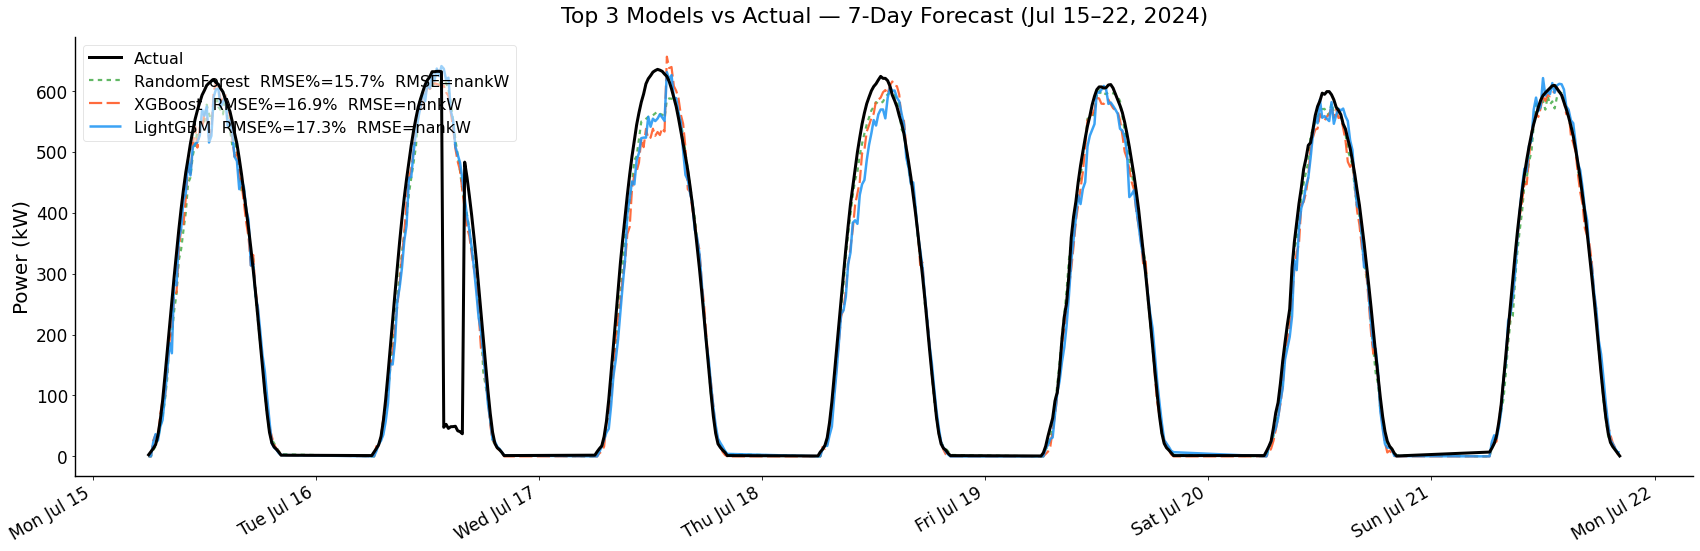

Saved → figT1_top3_together.png


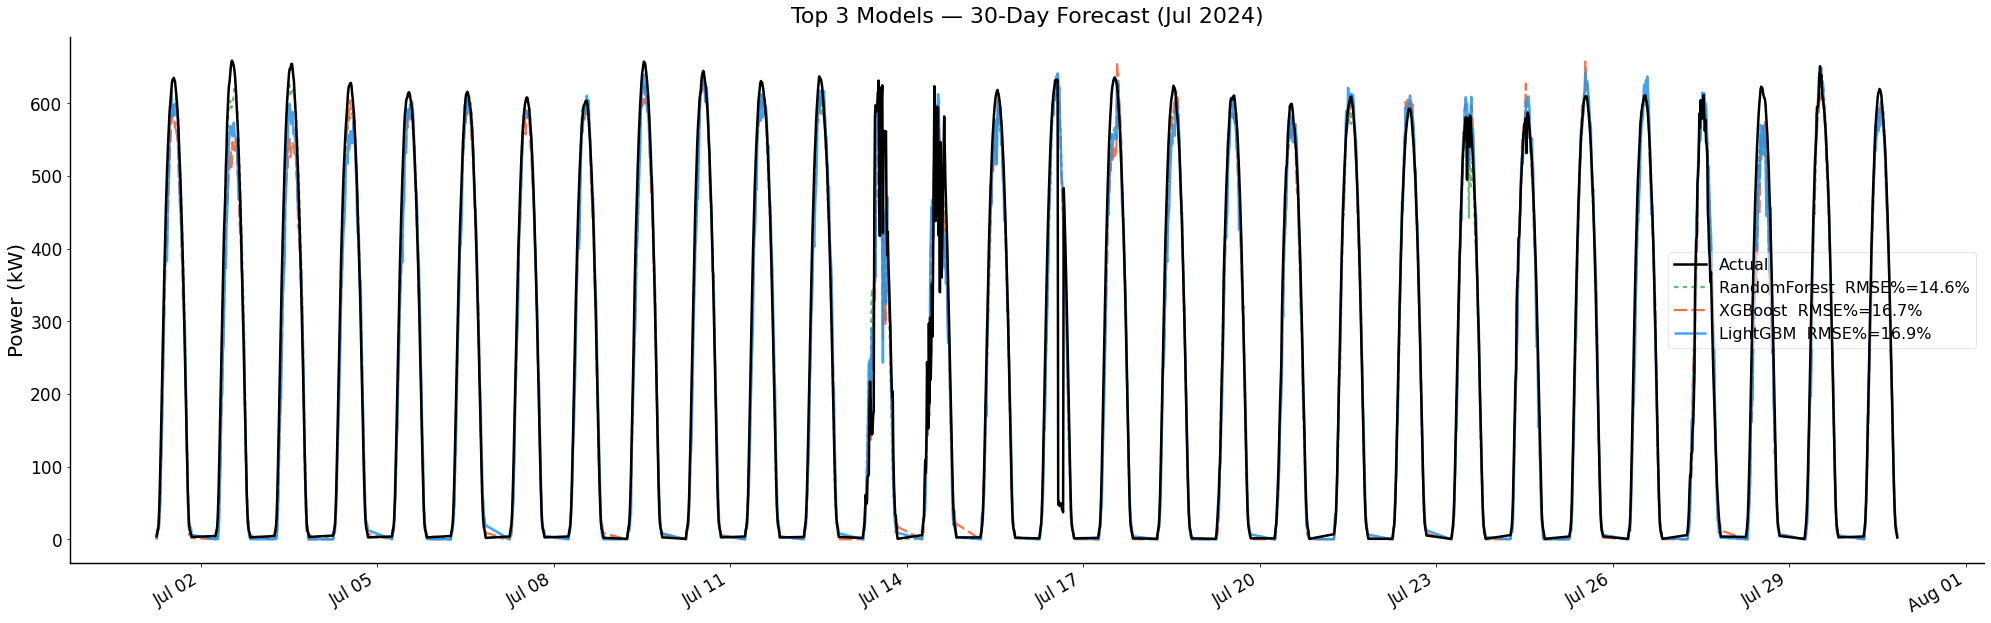

Saved → figT2_top3_30day.png


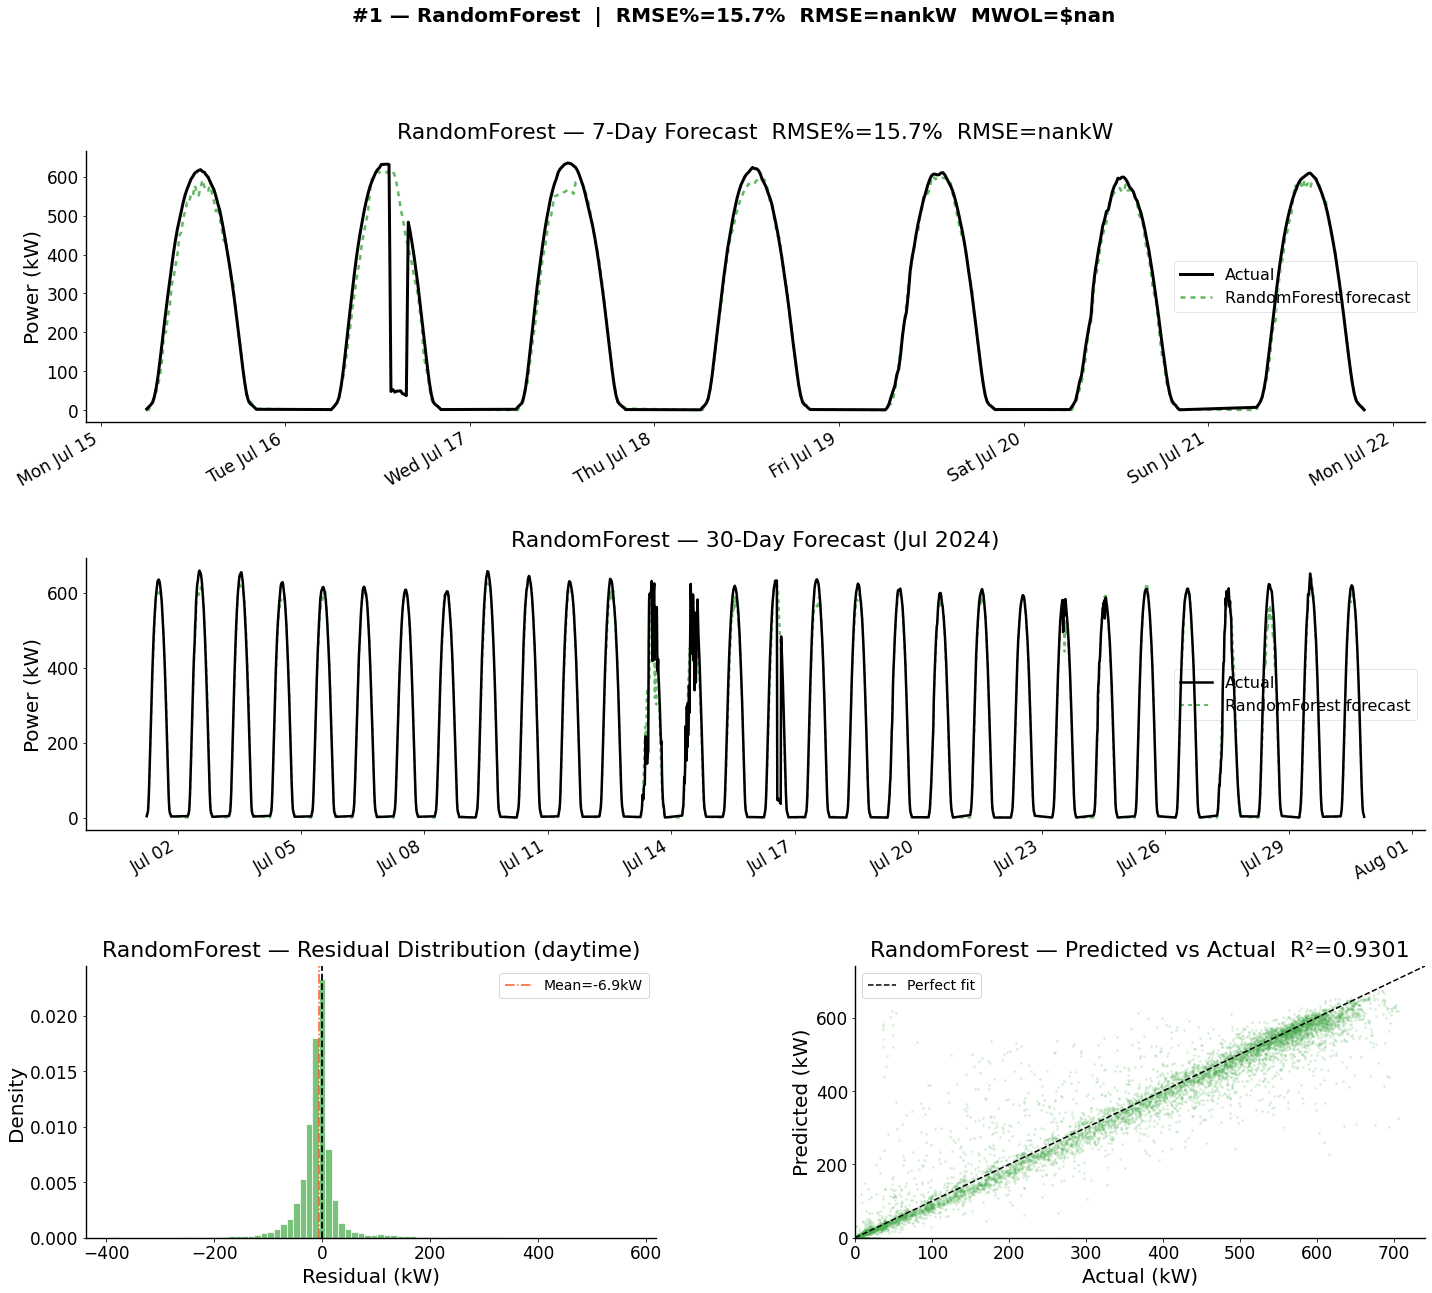

Saved → figT3_randomforest_detail.png


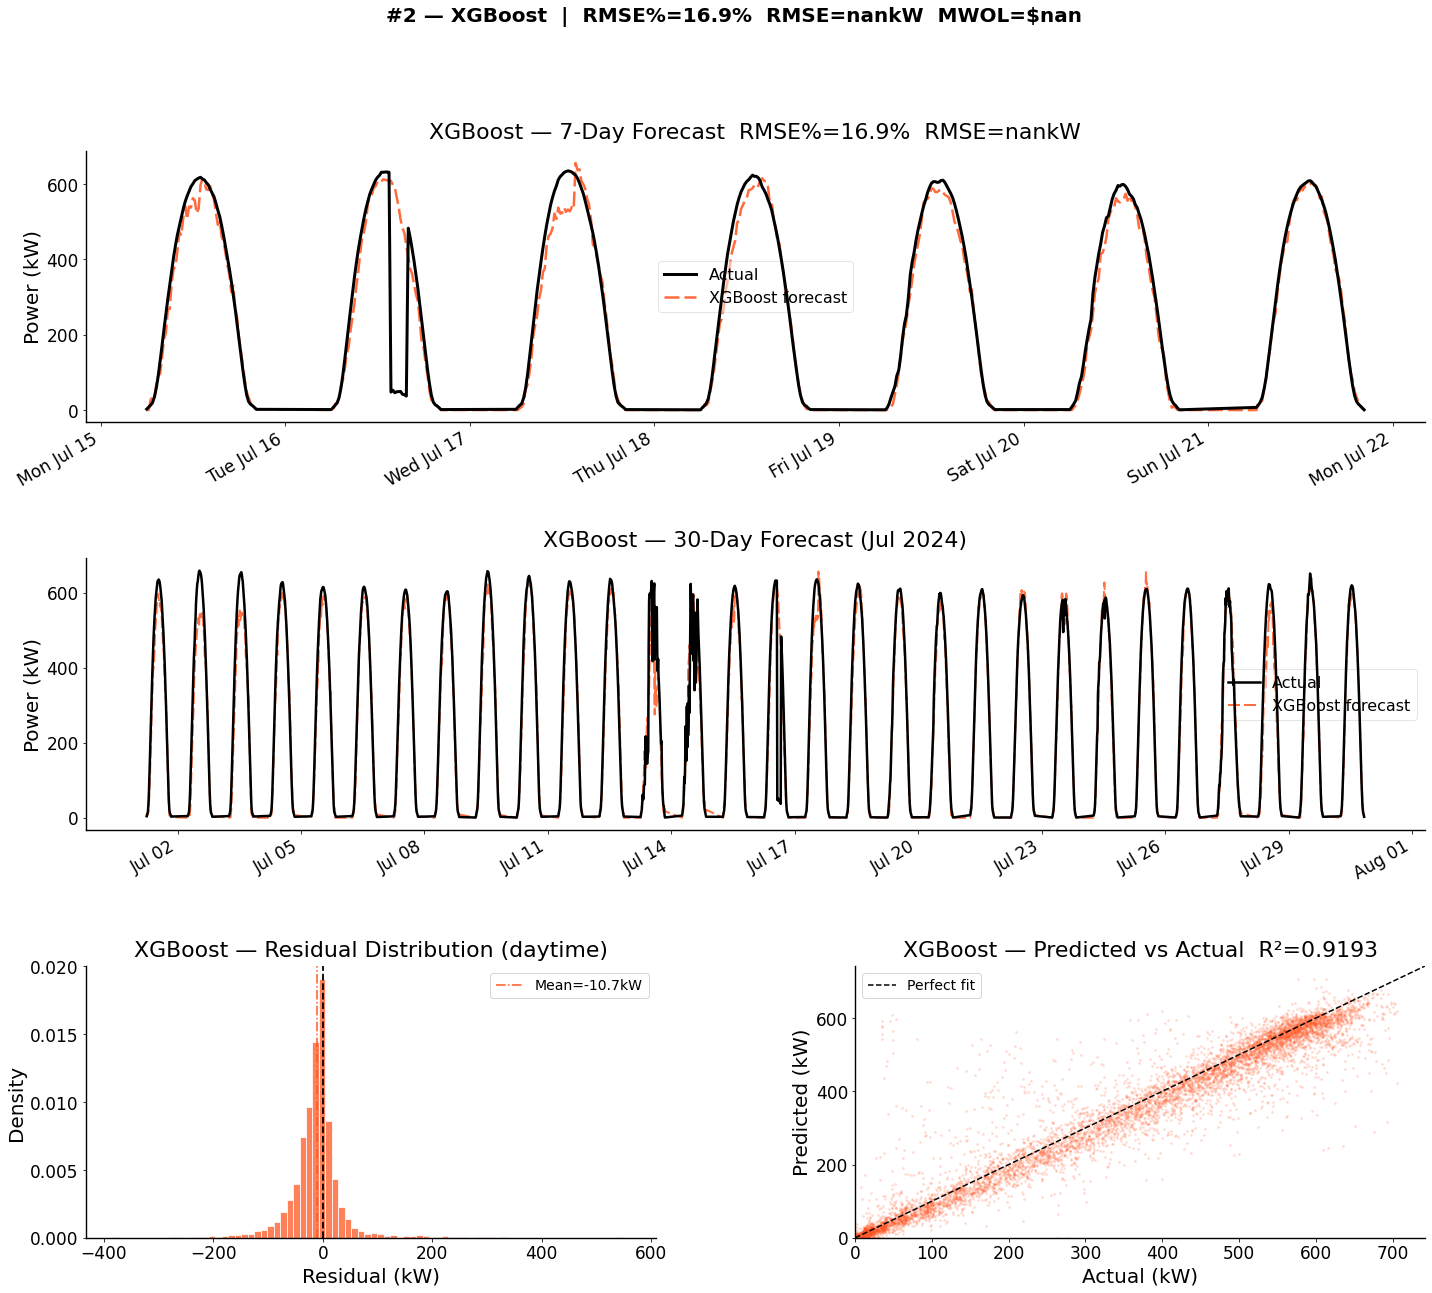

Saved → figT4_xgboost_detail.png


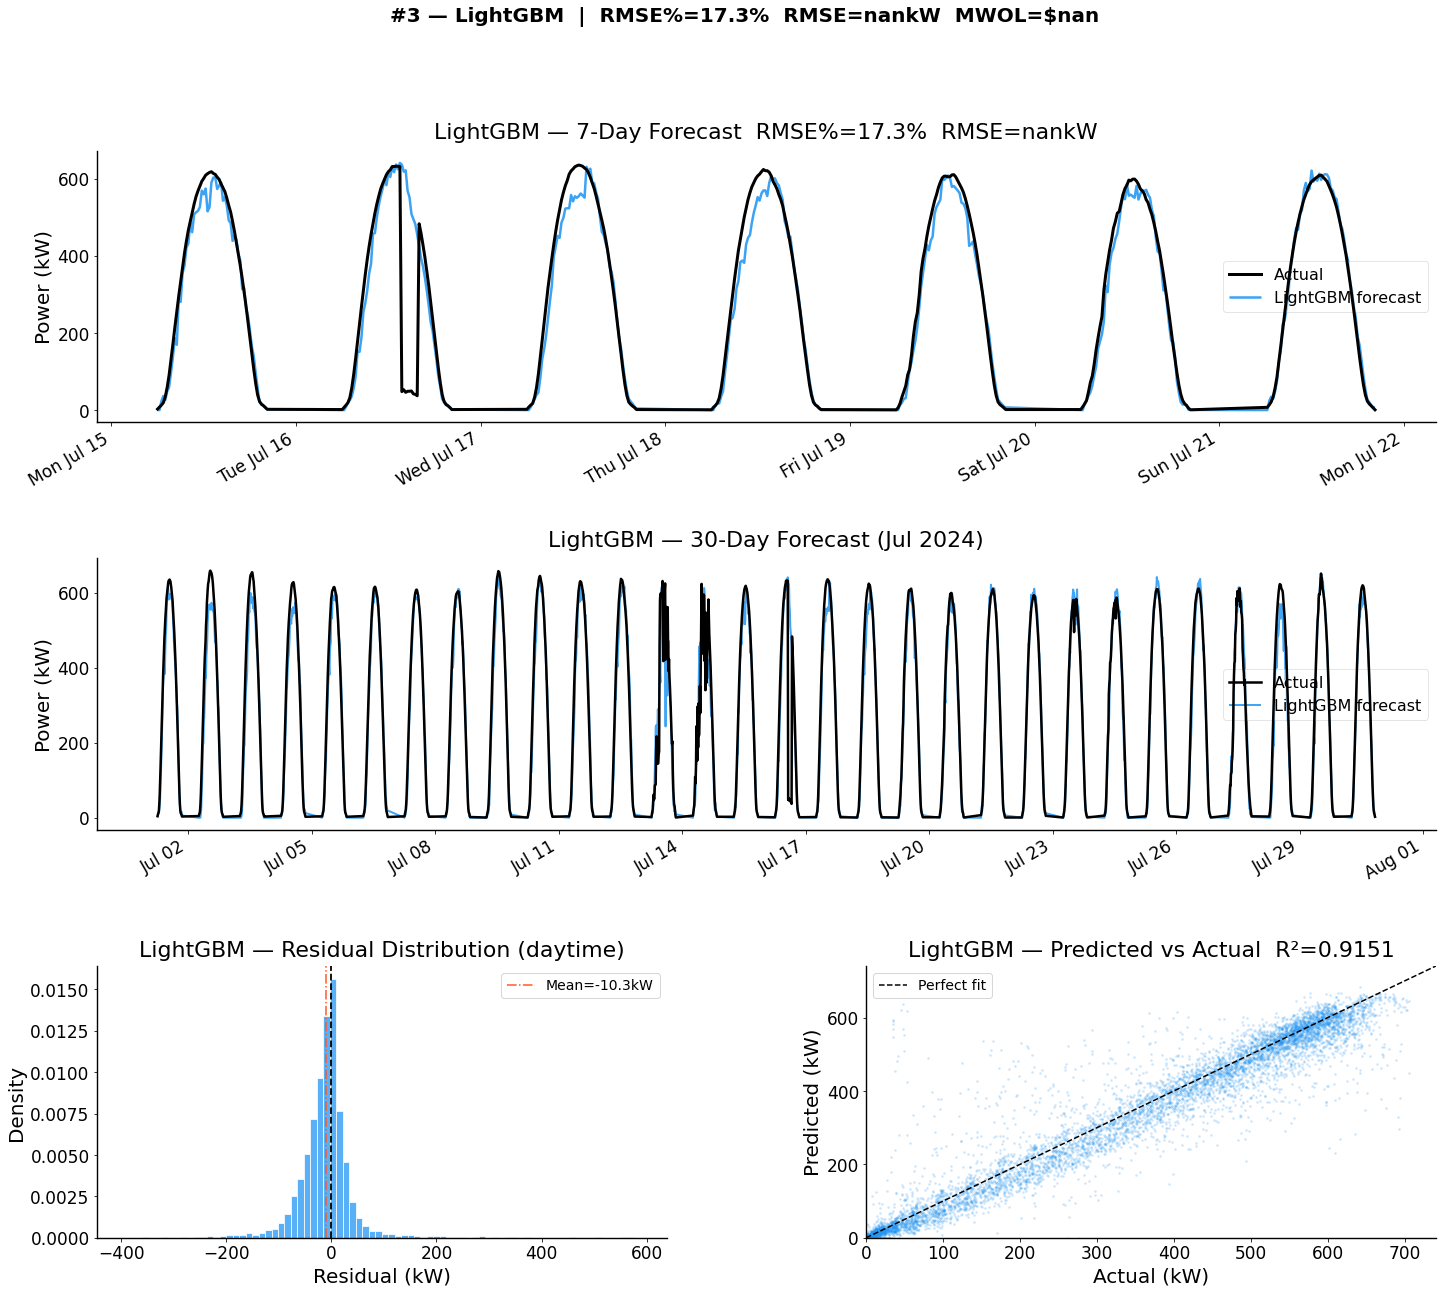

Saved → figT5_lightgbm_detail.png


In [21]:
# ── Identify top 3 ML models by Test RMSE% ───────────────────────────────────
ml_candidates = [n for n in results
                 if results[n]["model"] is not None
                 and n not in BASELINE_NAMES
                 and n != "Stacking"]

# Define financial_results here if Cell 35 hasn't been run yet
try:
    financial_results
except NameError:
    financial_results = {}
top3 = sorted(ml_candidates, key=lambda n: results[n]["rmse_pct"])[:3]
print(f"Top 3 models: {top3}")
for n in top3:
    print(f"  {n:<15}  RMSE%={results[n]['rmse_pct']:.2f}%  "
          f"RMSE={results[n].get('rmse_kw', float('nan')):.1f}kW  "
          f"MWOL=${financial_results[n]['mwol']:,.0f}" if n in financial_results
          else f"  {n:<15}  RMSE%={results[n]['rmse_pct']:.2f}%")

import matplotlib as mpl
mpl.rcParams.update({
    "font.size":18,"axes.titlesize":22,"axes.labelsize":20,
    "xtick.labelsize":17,"ytick.labelsize":17,"legend.fontsize":16,
    "axes.linewidth":1.4,"axes.spines.top":False,"axes.spines.right":False,
})

COLORS_T3 = {n: COLORS[n] for n in top3}
LS_T3 = {n: LINESTYLES[n] for n in top3}
LW_T3     = {n: LINEWIDTHS.get(n, 2.0) for n in top3}

# ── Forecast window data ───────────────────────────────────────────────────────
window_t3  = df_test_feat[forecast_start:forecast_end]
y_window_t3 = window_t3[TARGET]
dt_win      = y_window_t3 > 0

# ── Fig T1: All top 3 on one plot — 7-day forecast ────────────────────────────
fig, ax = plt.subplots(figsize=(24, 8))
ax.plot(window_t3.index[dt_win], y_window_t3[dt_win],
        color="black", linewidth=3, label="Actual", zorder=10)
for name in top3:
    p = window_preds[name] if name in window_preds else (
        nighttime_zero(results[name]["model"].predict(window_t3[FEATURES]), window_t3)
        if results[name]["model"] is not None else results[name]["preds"][
            (df_test_feat.index >= forecast_start) & (df_test_feat.index <= forecast_end)]
    )
    ax.plot(window_t3.index[dt_win], p[dt_win],
            color=COLORS_T3[name], linewidth=LW_T3[name],
            linestyle=LS_T3[name], alpha=0.88,
            label=f"{name}  RMSE%={results[name]['rmse_pct']:.1f}%  "
                  f"RMSE={results[name].get('rmse_kw', float('nan')):.1f}kW")
ax.set_title("Top 3 Models vs Actual — 7-Day Forecast (Jul 15–22, 2024)", pad=14)
ax.set_ylabel("Power (kW)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %b %d"))
ax.xaxis.set_major_locator(mdates.DayLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax.legend(framealpha=0.5, loc="upper left")
plt.tight_layout()
plt.savefig("figT1_top3_together.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figT1_top3_together.png")

# ── Fig T2: Top 3 together — 30-day forecast ─────────────────────────────────
forecast_30_start = pd.Timestamp("2024-07-01")
forecast_30_end   = forecast_30_start + pd.Timedelta(days=30)
w30   = df_test_feat[forecast_30_start:forecast_30_end]
y30   = w30[TARGET]
dt30  = y30 > 0

fig, ax = plt.subplots(figsize=(28, 9))
ax.plot(w30.index[dt30], y30[dt30],
        color="black", linewidth=2.5, label="Actual", zorder=10)
for name in top3:
    if results[name]["model"] is not None:
        p30 = nighttime_zero(results[name]["model"].predict(w30[FEATURES]), w30)
    else:
        mask30 = (df_test_feat.index >= forecast_30_start) & (df_test_feat.index <= forecast_30_end)
        p30 = results[name]["preds"][mask30]
    rmse30 = rmse_pct(y30.values, p30)
    ax.plot(w30.index[dt30], p30[dt30],
            color=COLORS_T3[name], linewidth=LW_T3[name],
            linestyle=LS_T3[name], alpha=0.85,
            label=f"{name}  RMSE%={rmse30:.1f}%")
ax.set_title("Top 3 Models — 30-Day Forecast (Jul 2024)", pad=14)
ax.set_ylabel("Power (kW)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax.legend(framealpha=0.5)
plt.tight_layout()
plt.savefig("figT2_top3_30day.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figT2_top3_30day.png")

# ── Figs T3–T5: Each top model separately — 7-day + residual + scatter ────────
for rank, name in enumerate(top3, start=1):
    if results[name]["model"] is not None:
        p_win = nighttime_zero(results[name]["model"].predict(window_t3[FEATURES]), window_t3)
        p_30  = nighttime_zero(results[name]["model"].predict(w30[FEATURES]), w30)
    else:
        mask_win = (df_test_feat.index >= forecast_start) & (df_test_feat.index <= forecast_end)
        p_win = results[name]["preds"][mask_win]
        mask30 = (df_test_feat.index >= forecast_30_start) & (df_test_feat.index <= forecast_30_end)
        p30   = results[name]["preds"][mask30]
        p_30  = p30

    preds_test = results[name]["preds"]
    col        = COLORS_T3[name]
    rk         = results[name].get("rmse_kw", float("nan"))
    rp         = results[name]["rmse_pct"]

    fig = plt.figure(figsize=(24, 20))
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.35)

    # ── Panel 1: 7-day forecast ───────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(window_t3.index[dt_win], y_window_t3[dt_win],
             color="black", linewidth=3, label="Actual", zorder=10)
    ax1.plot(window_t3.index[dt_win], p_win[dt_win],
             color=col, linewidth=2.5, linestyle=LS_T3[name],
             alpha=0.88, label=f"{name} forecast")
    ax1.set_title(f"{name} — 7-Day Forecast  RMSE%={rp:.1f}%  RMSE={rk:.1f}kW", pad=12)
    ax1.set_ylabel("Power (kW)")
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%a %b %d"))
    ax1.xaxis.set_major_locator(mdates.DayLocator())
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha="right")
    ax1.legend(framealpha=0.5)

    # ── Panel 2: 30-day forecast ──────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1, :])
    ax2.plot(w30.index[dt30], y30[dt30],
             color="black", linewidth=2.5, label="Actual", zorder=10)
    ax2.plot(w30.index[dt30], p_30[dt30],
             color=col, linewidth=2, linestyle=LS_T3[name],
             alpha=0.85, label=f"{name} forecast")
    ax2.set_title(f"{name} — 30-Day Forecast (Jul 2024)", pad=12)
    ax2.set_ylabel("Power (kW)")
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax2.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha="right")
    ax2.legend(framealpha=0.5)

    # ── Panel 3: Residual distribution ───────────────────────────────────────
    ax3 = fig.add_subplot(gs[2, 0])
    dt_test_mask = y_test.values > 0
    resid = preds_test[dt_test_mask] - y_test.values[dt_test_mask]
    ax3.hist(resid, bins=80, color=col, alpha=0.75, density=True, edgecolor="white")
    ax3.axvline(0, color="black", linewidth=1.8, linestyle="--")
    ax3.axvline(resid.mean(), color="#FF5722", linewidth=1.5, linestyle="-.",
                label=f"Mean={resid.mean():.1f}kW")
    ax3.set_title(f"{name} — Residual Distribution (daytime)", pad=10)
    ax3.set_xlabel("Residual (kW)")
    ax3.set_ylabel("Density")
    ax3.legend(fontsize=14)

    # ── Panel 4: Scatter actual vs predicted ─────────────────────────────────
    ax4 = fig.add_subplot(gs[2, 1])
    ax4.scatter(y_test.values[dt_test_mask], preds_test[dt_test_mask],
                s=3, alpha=0.15, color=col)
    lim = [0, max(y_test.values.max(), preds_test.max()) * 1.05]
    ax4.plot(lim, lim, "k--", linewidth=1.5, label="Perfect fit")
    ax4.set_xlim(lim); ax4.set_ylim(lim)
    ax4.set_title(f"{name} — Predicted vs Actual  R²={results[name]['r2']:.4f}", pad=10)
    ax4.set_xlabel("Actual (kW)")
    ax4.set_ylabel("Predicted (kW)")
    ax4.legend(fontsize=14)

    plt.suptitle(f"#{rank} — {name}  |  RMSE%={rp:.1f}%  RMSE={rk:.1f}kW  "
                 f"MWOL=${financial_results.get(name, {}).get('mwol', float('nan')):,.0f}",
                 fontsize=20, fontweight="bold")
    plt.savefig(f"figT{rank+2}_{name.lower()}_detail.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → figT{rank+2}_{name.lower()}_detail.png")


---

## 11c. July 2024 Daily MWOL — Top 3 Models
Detailed daily revenue loss for July 2024: all top-3 together, then each model individually with daily bar and cumulative line. 

## 12. LMP Data Loading & Financial Analysis
**Locational Marginal Price (LMP)** is the hourly electricity price at the grid node.
It determines revenue earned per MWh of solar energy delivered to the grid.

**Data source:** CAISO OASIS API (pure `requests`, Python 3.10 compatible)  
- Node: `TH_NP15_GEN-APND` (NP15 trading hub — Northern California, covers Arbuckle area)  
- Resolution: hourly, local Pacific time  
- Coverage: 2023-01-23 onward (~10–12 min download in weekly chunks)

**MWOL formula (from user specification):**
```
penalty = max(0, LMP × (predicted_MWh − actual_MWh))
```
Covers both:
- Positive LMP + over-prediction → buy shortfall at market price
- Negative LMP + under-prediction → selling less when price is negative (avoided cost)

**Financial Efficiency:**
`FE (%) = (1 − Total_MWOL / Total_Potential_Revenue) × 100`


In [27]:
# ── Download LMP from CAISO OASIS API (pure requests, no gridstatus) ─────────
# Uses the CAISO OASIS PRC_LMP query — no external dependencies beyond requests.
# Node  : TH_NP15_GEN-APND  (NP15 trading hub, Northern California)
# Market: DAM (Day-Ahead Market)
# Chunks: 30-day windows with 2 s pause — ~10-12 min total download

import requests, zipfile, io, time

def fetch_caiso_lmp_oasis(start_date, end_date,
                           node="TH_NP15_GEN-APND",
                           market="DAM",
                           chunk_days=30):
    """Download hourly Day-Ahead LMP from CAISO OASIS.

    Returns a DataFrame with columns:
      'Interval Start' (tz-naive Pacific), 'LMP' ($/MWh)
    """
    base = "http://oasis.caiso.com/oasisapi/SingleZip"
    cur  = pd.Timestamp(start_date)
    end  = pd.Timestamp(end_date)
    records = []

    print(f"Fetching CAISO LMP {start_date} → {end_date}  node={node}")
    while cur < end:
        nxt = min(cur + pd.Timedelta(days=chunk_days), end)
        params = {
            "queryname":     "PRC_LMP",
            "startdatetime": cur.strftime("%Y%m%dT00:00-0000"),  # UTC
            "enddatetime":   nxt.strftime("%Y%m%dT00:00-0000"),
            "version":       1,
            "market_run_id": market,
            "node":          node,
            "resultformat":  6,   # CSV inside ZIP
        }
        try:
            r = requests.get(base, params=params, timeout=90)
            r.raise_for_status()
            with zipfile.ZipFile(io.BytesIO(r.content)) as z:
                csv_name = next(n for n in z.namelist() if n.endswith(".csv"))
                chunk = pd.read_csv(z.open(csv_name))

            # Keep only the composite LMP row (excludes energy/loss/congestion)
            chunk = chunk[chunk["LMP_TYPE"] == "LMP"].copy()

            # OASIS returns GMT timestamps — convert to tz-naive Pacific
            chunk["Interval Start"] = (
                pd.to_datetime(chunk["INTERVALSTARTTIME_GMT"], utc=True)
                  .dt.tz_convert("US/Pacific")
                  .dt.tz_localize(None)
            )
            chunk = chunk.rename(columns={"MW": "LMP"})[["Interval Start","LMP"]]
            records.append(chunk)
            print(f"  {cur.date()} → {nxt.date()} : {len(chunk)} rows")
        except Exception as e:
            print(f"  WARNING {cur.date()} → {nxt.date()} : {e}")
        cur = nxt
        time.sleep(2)   # respect CAISO rate limit

    if not records:
        raise RuntimeError("No LMP data returned — check node name or date range")

    lmp_raw = (pd.concat(records, ignore_index=True)
                 .drop_duplicates("Interval Start")
                 .sort_values("Interval Start")
                 .reset_index(drop=True))

    print(f"\nTotal rows : {len(lmp_raw):,}")
    print(f"Date range : {lmp_raw['Interval Start'].min()} → "
          f"{lmp_raw['Interval Start'].max()}")
    print(f"LMP stats  : mean=${lmp_raw['LMP'].mean():.2f}  "
          f"min=${lmp_raw['LMP'].min():.2f}  "
          f"max=${lmp_raw['LMP'].max():.2f} /MWh")
    return lmp_raw

# ── Run the download ──────────────────────────────────────────────────────────
# LMP starts 2023-01-23; we cover the full val + test window
lmp_df = fetch_caiso_lmp_oasis(
    start_date = "2024-01-01",   # covers val (Jan-May) and test (Jun-Oct)
    end_date   = "2024-11-01",
    node       = "TH_NP15_GEN-APND",
)

# Alias for downstream cells
lmp_clean = lmp_df.copy()
print("\nlmp_clean ready.")
print(lmp_clean.head(3))


Fetching CAISO LMP 2024-01-01 → 2024-11-01  node=TH_NP15_GEN-APND
  2024-01-01 → 2024-01-31 : 720 rows
  2024-01-31 → 2024-03-01 : 720 rows
  2024-03-01 → 2024-03-31 : 720 rows
  WARNING 2024-03-31 → 2024-04-30 : 429 Client Error: Too Many Requests for url: https://oasis.caiso.com/oasisapi/SingleZip?queryname=PRC_LMP&startdatetime=20240331T00%3A00-0000&enddatetime=20240430T00%3A00-0000&version=1&market_run_id=DAM&node=TH_NP15_GEN-APND&resultformat=6
  2024-04-30 → 2024-05-30 : 720 rows
  2024-05-30 → 2024-06-29 : 720 rows
  2024-06-29 → 2024-07-29 : 720 rows
  2024-07-29 → 2024-08-28 : 720 rows
  2024-08-28 → 2024-09-27 : 720 rows
  2024-09-27 → 2024-10-27 : 720 rows
  2024-10-27 → 2024-11-01 : 120 rows

Total rows : 6,600
Date range : 2023-12-31 16:00:00 → 2024-10-31 16:00:00
LMP stats  : mean=$41.11  min=$-31.71  max=$582.64 /MWh

lmp_clean ready.
       Interval Start       LMP
0 2023-12-31 16:00:00  50.00157
1 2023-12-31 17:00:00  51.44539
2 2023-12-31 18:00:00  50.17015


lmp_clean shape : (6600, 2)
Date range      : 2023-12-31 16:00:00 → 2024-10-31 16:00:00
LMP stats       : mean=$41.11  min=$-31.71  max=$582.64 /MWh
       Interval Start       LMP
0 2023-12-31 16:00:00  50.00157
1 2023-12-31 17:00:00  51.44539
2 2023-12-31 18:00:00  50.17015


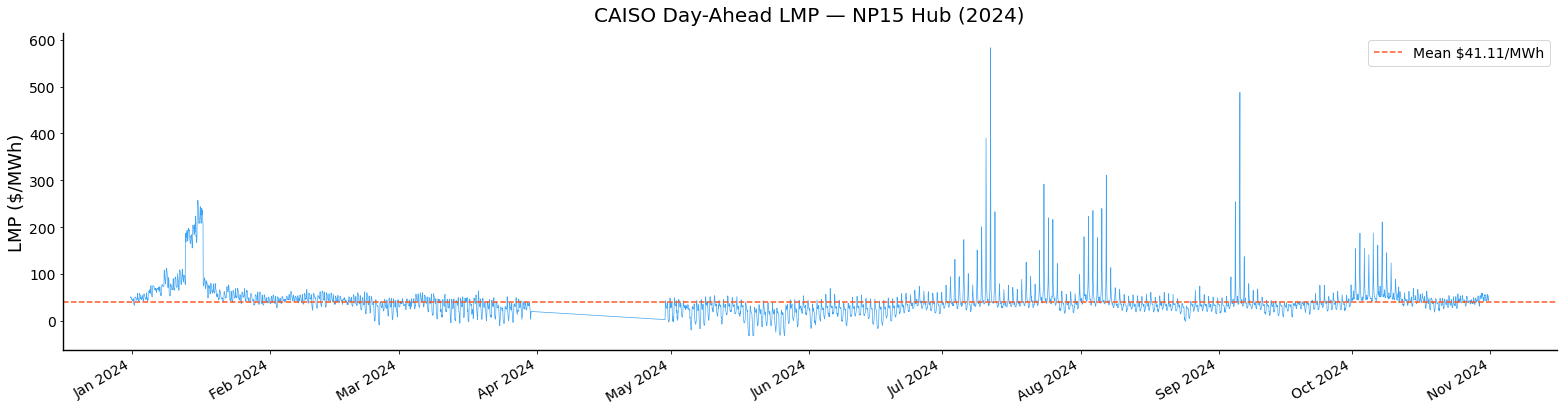

Saved → figF0_lmp_overview.png


In [28]:
# ── lmp_clean is already prepared in Cell 30 ─────────────────────────────────
# Just display a quick overview plot of the LMP data.

import matplotlib as mpl
mpl.rcParams.update({"font.size":16,"axes.titlesize":20,"axes.labelsize":18,
                     "xtick.labelsize":14,"ytick.labelsize":14,
                     "axes.spines.top":False,"axes.spines.right":False})

print(f"lmp_clean shape : {lmp_clean.shape}")
print(f"Date range      : {lmp_clean['Interval Start'].min()} → "
      f"{lmp_clean['Interval Start'].max()}")
print(f"LMP stats       : mean=${lmp_clean['LMP'].mean():.2f}  "
      f"min=${lmp_clean['LMP'].min():.2f}  "
      f"max=${lmp_clean['LMP'].max():.2f} /MWh")
print(lmp_clean.head(3))

# ── LMP overview plot ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 6))
ax.plot(lmp_clean["Interval Start"], lmp_clean["LMP"],
        linewidth=0.7, color="#2196F3", alpha=0.85)
ax.axhline(lmp_clean["LMP"].mean(), color="#FF5722", linewidth=1.5,
           linestyle="--", label=f"Mean ${lmp_clean['LMP'].mean():.2f}/MWh")
ax.set_title("CAISO Day-Ahead LMP — NP15 Hub (2024)", pad=12)
ax.set_ylabel("LMP ($/MWh)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax.legend(fontsize=14)
plt.tight_layout()
plt.savefig("figF0_lmp_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figF0_lmp_overview.png")


## 13. Financial Metric Functions

In [30]:
# ── Financial metric functions (matching user specification) ─────────────────

def meter_to_hourly_mwh(df_15min, time_col="measured_on"):
    """Convert 15-min kW readings → hourly MWh.
    
    Each 15-min interval: energy = power_kW × 0.25h × (1 MWh/1000 kWh)
    Then resample to hourly by summing four 15-min intervals.
    Returns a DataFrame indexed by hour with numeric columns in MWh.
    """
    df = df_15min.copy()
    df[time_col] = pd.to_datetime(df[time_col])
    # Strip timezone if present (keep tz-naive to match LMP)
    if df[time_col].dt.tz is not None:
        df[time_col] = df[time_col].dt.tz_localize(None)
    df = df.sort_values(time_col)
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    # kW × 0.25h × 0.001 = MWh per 15-min interval
    df[num_cols] = df[num_cols] * 0.001 * 0.25
    hourly = df.set_index(time_col)[num_cols].resample("1h").sum(min_count=1)
    return hourly.reset_index()


def compute_market_weighted_loss(actuals_15min, preds_15min, lmp_df,
                                  time_col="measured_on"):
    """Market Weighted Opportunity Loss (MWOL) — user specification formula.

    MWOL penalty per hour = max(0, LMP × (predicted_MWh − actual_MWh))

    This covers two harmful cases:
      1. Positive LMP + over-prediction → committed to sell more than produced,
         must buy shortfall at market price.
      2. Negative LMP + under-prediction → by producing more than committed,
         we export at a negative price, incurring a cost (avoided by under-committing).

    Potential revenue = max(0, LMP × actual_MWh)  (revenue from perfect forecast)

    Parameters
    ----------
    actuals_15min : DataFrame with [time_col, actual_power_kw]
    preds_15min   : DataFrame with [time_col, predicted_power_kw]
    lmp_df        : DataFrame with ['Interval Start', 'LMP']
    time_col      : name of the timestamp column in actuals/preds

    Returns
    -------
    dict with total MWOL ($), mean daily MWOL ($/day), financial efficiency (%),
    daily series, and the detailed hourly DataFrame for inspection.
    """
    # 1. Convert 15-min kW → hourly MWh
    actuals_h = meter_to_hourly_mwh(actuals_15min, time_col=time_col)
    preds_h   = meter_to_hourly_mwh(preds_15min,   time_col=time_col)

    # 2. Align with LMP on 'Interval Start'
    lmp_work = lmp_df.copy()
    lmp_work["Interval Start"] = pd.to_datetime(lmp_work["Interval Start"])
    if lmp_work["Interval Start"].dt.tz is not None:
        lmp_work["Interval Start"] = (lmp_work["Interval Start"]
                                       .dt.tz_convert("US/Pacific")
                                       .dt.tz_localize(None))

    # Merge actuals and predictions onto LMP timestamps
    val_col  = [c for c in actuals_h.columns if c != time_col][0]  # e.g. 'power_kw'

    # Rename before merging so both sides have distinct column names,
    # avoiding the pandas suffixing that causes KeyError when names collide.
    actuals_h = actuals_h.rename(columns={val_col: "actual_mwh"})
    preds_h   = preds_h.rename(columns={val_col: "pred_mwh"})
    act_col   = "actual_mwh"
    pred_col  = "pred_mwh"

    df = (lmp_work
          .merge(actuals_h, left_on="Interval Start", right_on=time_col, how="left")
          .merge(preds_h,   left_on="Interval Start", right_on=time_col, how="left"))

    # Drop hours missing any of the three required values
    df = df.dropna(subset=["LMP", act_col, pred_col])

    # 3. Compute penalty and potential revenue per hour
    # Penalty: positive LMP × over-prediction OR negative LMP × under-prediction
    df["mwol_penalty"]      = np.maximum(0, df["LMP"] * (df[pred_col] - df[act_col]))
    df["potential_revenue"] = np.maximum(0, df["LMP"] * df[act_col])

    # 4. Daily aggregation
    daily = df.groupby(df["Interval Start"].dt.date).agg(
        mwol_penalty=("mwol_penalty",      "sum"),
        potential_revenue=("potential_revenue", "sum"),
    )
    daily.index = pd.to_datetime(daily.index)

    # 5. Summary metrics
    total_loss      = daily["mwol_penalty"].sum()
    total_potential = daily["potential_revenue"].sum()
    mean_daily_mwol = daily["mwol_penalty"].mean()
    efficiency      = (1 - total_loss / total_potential) * 100 if total_potential > 0 else 0.0

    return {
        "Total MWOL ($)":          total_loss,
        "Mean Daily MWOL ($/day)": mean_daily_mwol,
        "Financial Efficiency (%)": efficiency,
        "Daily_MWOL_Series":       daily["mwol_penalty"],
        "Daily_Potential":         daily["potential_revenue"],
        "Detailed_DF":             df,
    }


def financial_efficiency_pct(actuals_15min, preds_15min, lmp_df,
                               time_col="measured_on"):
    """Convenience wrapper returning only Financial Efficiency (%)."""
    r = compute_market_weighted_loss(actuals_15min, preds_15min, lmp_df, time_col)
    return r["Financial Efficiency (%)"]


print("Financial functions defined:")
print("  meter_to_hourly_mwh()          → converts 15-min kW → hourly MWh")
print("  compute_market_weighted_loss()  → MWOL, daily series, FE%")
print("  financial_efficiency_pct()      → quick FE% wrapper")


Financial functions defined:
  meter_to_hourly_mwh()          → converts 15-min kW → hourly MWh
  compute_market_weighted_loss()  → MWOL, daily series, FE%
  financial_efficiency_pct()      → quick FE% wrapper


## 14. Compute Financial Metrics for All Models

In [31]:
# ── Prepare actuals DataFrame ────────────────────────────────────────────────
# Explicit single column named 'power_kw' to avoid any naming collisions
# inside compute_market_weighted_loss when the same df is passed twice.

actuals_15min = pd.DataFrame({
    "measured_on": df_test_feat.index,
    "power_kw":    y_test.values,          # actual power, explicitly named
})

print("Computing MWOL for all models...")
print(f"Actuals shape : {actuals_15min.shape}")
print(f"LMP coverage  : {lmp_clean['Interval Start'].min().date()} → "
      f"{lmp_clean['Interval Start'].max().date()}")
print()

financial_results = {}
for name, r in results.items():
    # Build predictions DataFrame — same single-column structure
    preds_15min = pd.DataFrame({
        "measured_on": df_test_feat.index,
        "power_kw":    r["preds"],          # predicted power, same column name
    })

    res = compute_market_weighted_loss(
        actuals_15min,
        preds_15min,
        lmp_clean,
        time_col="measured_on",
    )

    financial_results[name] = {
        "mwol":       res["Total MWOL ($)"],
        "mean_daily": res["Mean Daily MWOL ($/day)"],
        "fe_pct":     res["Financial Efficiency (%)"],
        "daily":      res["Daily_MWOL_Series"],
        "daily_pot":  res["Daily_Potential"],
        "rmse_pct":   r["rmse_pct"],
    }

    rmse_day = r.get("rmse_kw", float("nan"))
    rmse_all = r.get("rmse_kw_all", float("nan"))
    print(f"  {name:<22}  "
          f"MWOL=${res['Total MWOL ($)']:>10,.2f}  "
          f"FE={res['Financial Efficiency (%)']:>7.2f}%  "
          f"RMSE%={r['rmse_pct']:.1f}%  "
          f"RMSE={rmse_day:.1f}kW(day)/{rmse_all:.1f}kW(all)")

# ── Backfill rmse_kw for all models (computed here where preds are available) ─
# ML model results were built before rmse_absolute() existed, so rmse_kw=NaN.
# Recompute here using the test actuals and stored predictions.
for name, r in results.items():
    if np.isnan(r.get("rmse_kw", np.nan)):
        preds = r["preds"]
        dt    = y_test.values > 0
        if dt.sum() > 0:
            results[name]["rmse_kw"]     = float(np.sqrt(np.mean(
                (preds[dt] - y_test.values[dt]) ** 2)))
            results[name]["rmse_kw_all"] = float(np.sqrt(np.mean(
                (preds    - y_test.values)     ** 2)))

# ── Perfect forecast revenue ──────────────────────────────────────────────────
# Pass actuals as both actual and predicted — MWOL = 0 for every hour,
# potential_revenue = sum of all positive LMP × actual_MWh intervals.
# We compute this separately to get the denominator for FE%.
perfect_res    = compute_market_weighted_loss(
    actuals_15min, actuals_15min, lmp_clean, time_col="measured_on"
)
perfect_profit = perfect_res["Daily_Potential"].sum()
print(f"\nPerfect forecast potential revenue: ${perfect_profit:,.2f}")

# ── Summary table ─────────────────────────────────────────────────────────────
fin_summary = pd.DataFrame({
    name: {
        "MWOL ($)":              v["mwol"],
        "Mean Daily MWOL ($/d)": v["mean_daily"],
        "Revenue Lost (%)":      v["mwol"] / perfect_profit * 100
                                 if perfect_profit > 0 else np.nan,
        "Financial Eff. (%)":    v["fe_pct"],
        "RMSE%":                 v["rmse_pct"],
        "RMSE kW (daytime)":     results[name].get("rmse_kw", np.nan),
        "RMSE kW (all hrs)":     results[name].get("rmse_kw_all", np.nan),
    }
    for name, v in financial_results.items()
}).T.sort_values("MWOL ($)")

print("\n" + "="*72)
print("  FINANCIAL COMPARISON — Test Set (Jun–Oct 2024)")
print(f"  Perfect forecast revenue: ${perfect_profit:,.2f}")
print("="*72)
print(fin_summary.round(3).to_string())
print("="*72)


Computing MWOL for all models...
Actuals shape : (14688, 2)
LMP coverage  : 2023-12-31 → 2024-10-31

  LightGBM                MWOL=$    861.94  FE=  95.76%  RMSE%=17.3%  RMSE=nankW(day)/nankW(all)
  XGBoost                 MWOL=$    771.06  FE=  96.21%  RMSE%=16.9%  RMSE=nankW(day)/nankW(all)
  RandomForest            MWOL=$    738.57  FE=  96.37%  RMSE%=15.7%  RMSE=nankW(day)/nankW(all)
  Ridge                   MWOL=$  1,623.73  FE=  92.02%  RMSE%=18.1%  RMSE=nankW(day)/nankW(all)
  LinearReg               MWOL=$  1,625.88  FE=  92.01%  RMSE%=18.1%  RMSE=nankW(day)/nankW(all)
  MLP                     MWOL=$    935.95  FE=  95.40%  RMSE%=19.8%  RMSE=nankW(day)/nankW(all)
  Stacking                MWOL=$  1,191.00  FE=  94.15%  RMSE%=16.6%  RMSE=nankW(day)/nankW(all)
  Persistence             MWOL=$  1,160.61  FE=  94.29%  RMSE%=25.2%  RMSE=83.8kW(day)/65.9kW(all)
  Climatology             MWOL=$  1,165.94  FE=  94.27%  RMSE%=20.6%  RMSE=68.7kW(day)/57.2kW(all)
  SmartPersistence    

## 15. Financial Comparison Plots

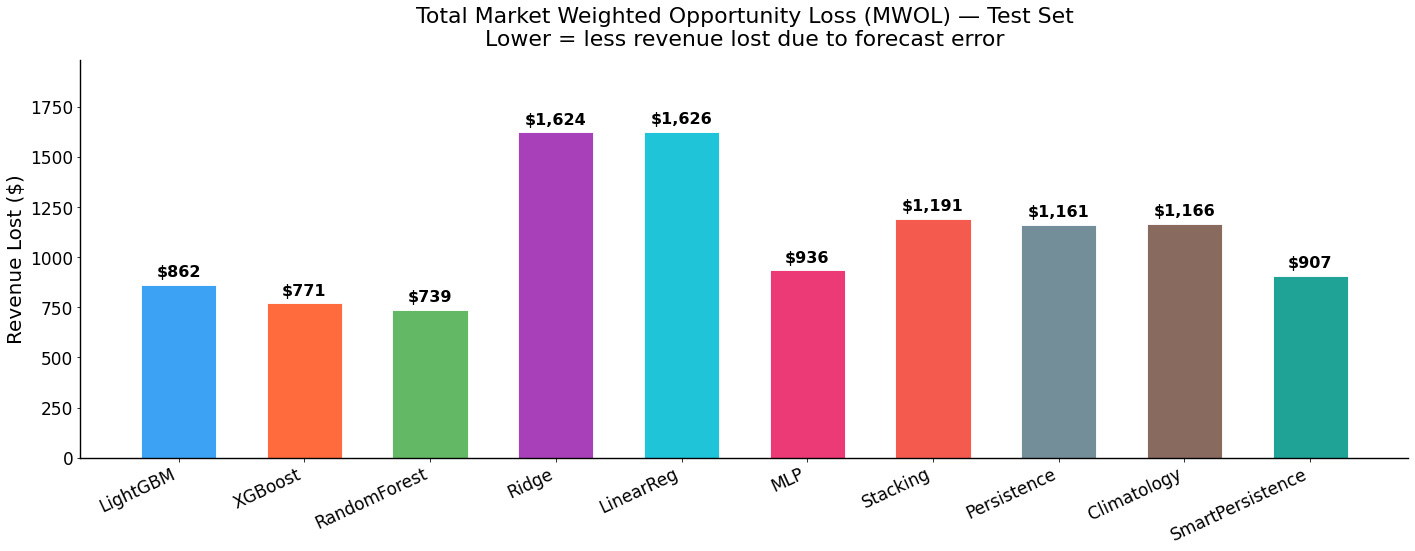

Saved → figF1_mwol_total.png


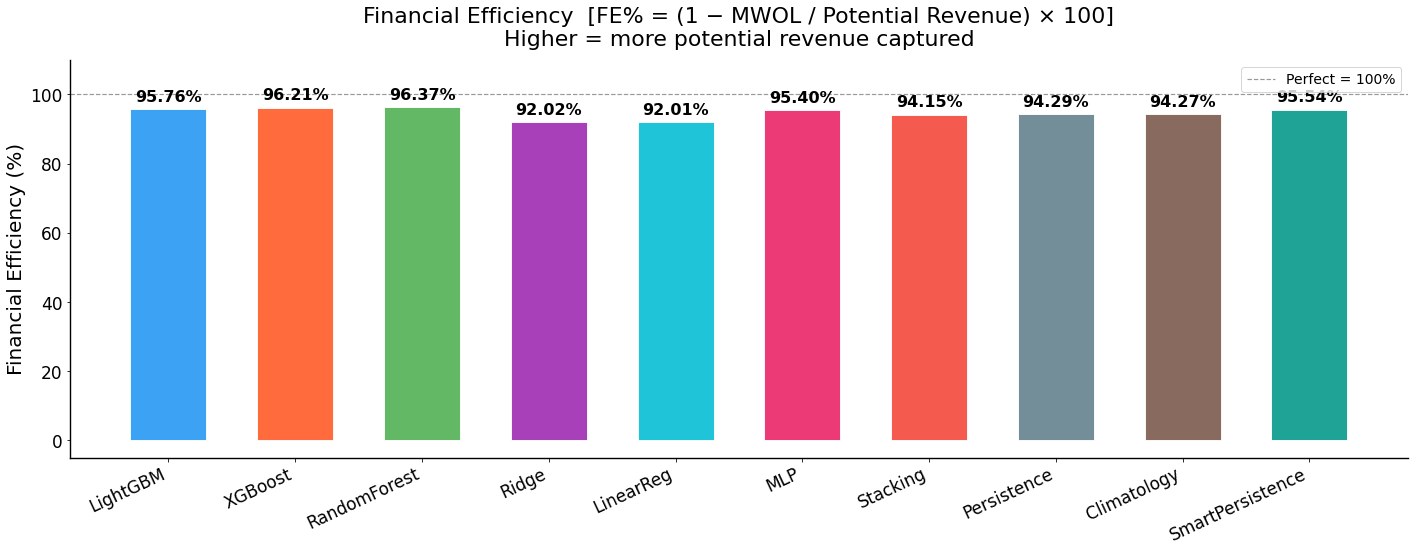

Saved → figF2_financial_efficiency.png


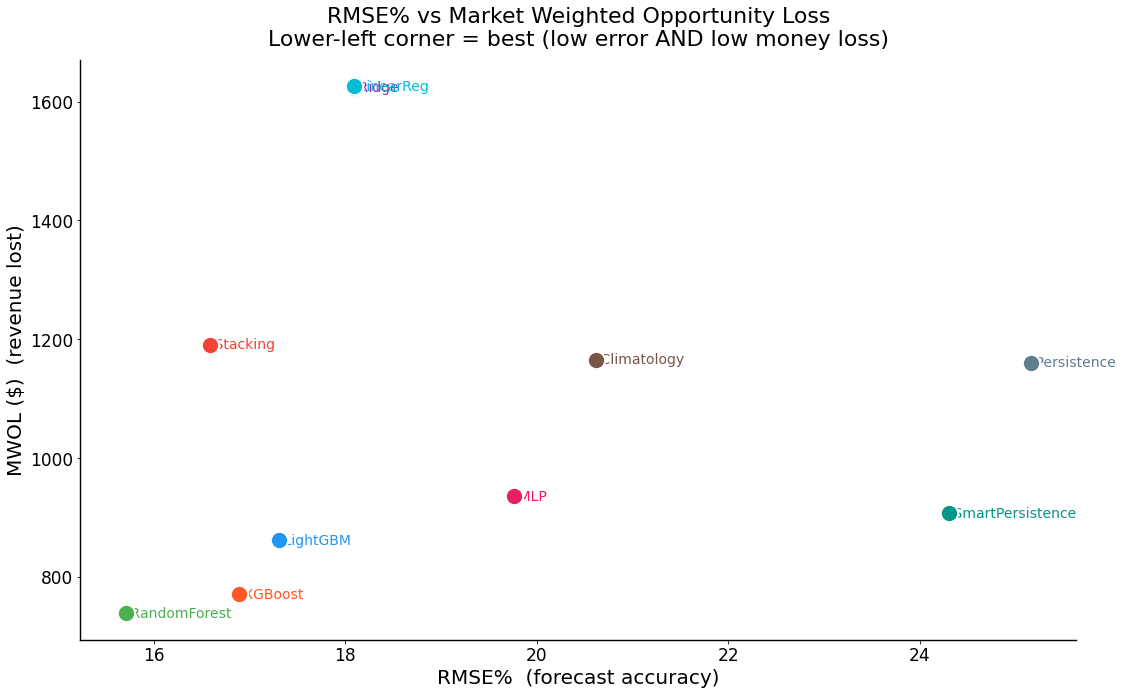

Saved → figF3_rmse_vs_mwol.png


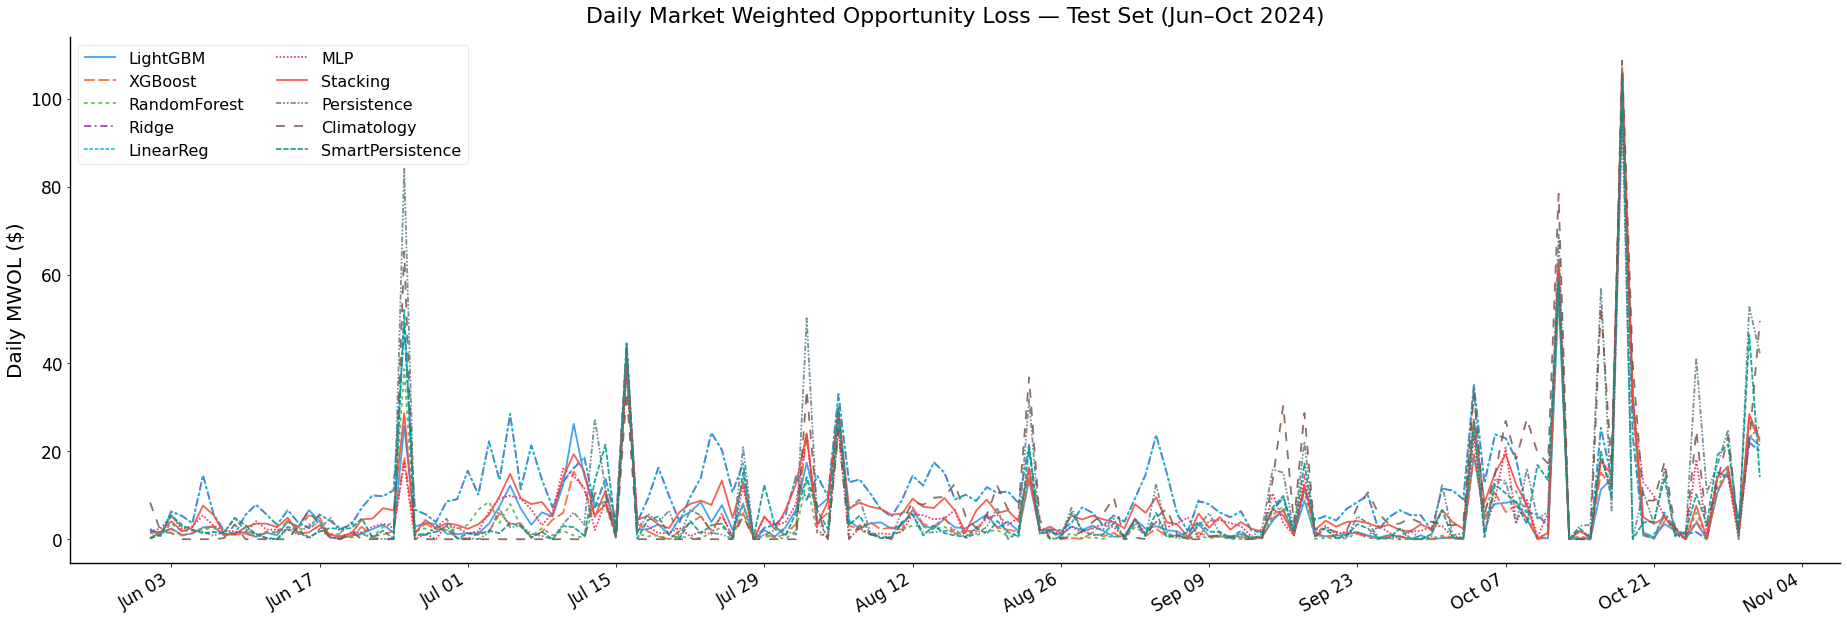

Saved → figF4_daily_mwol.png


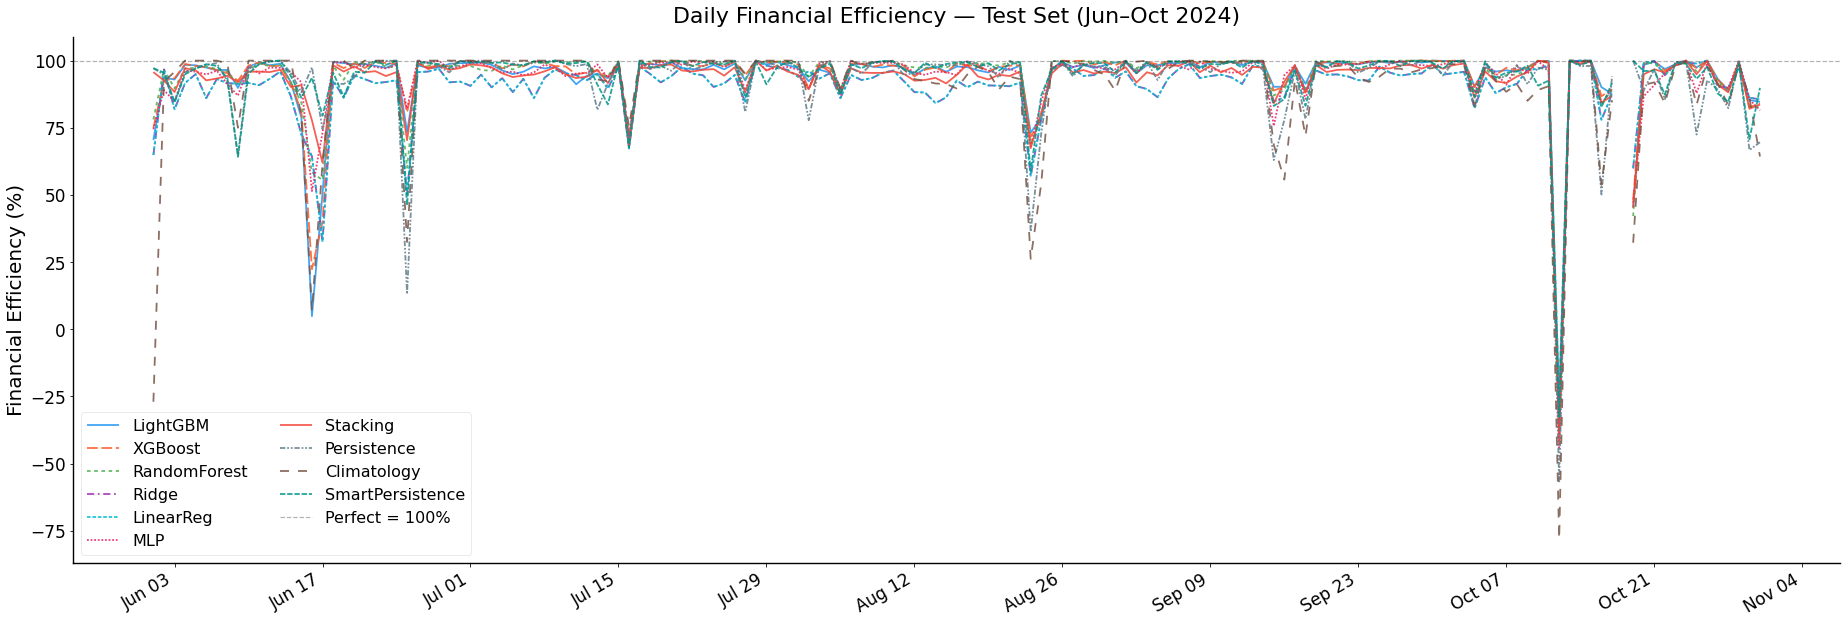

Saved → figF5_daily_fe.png


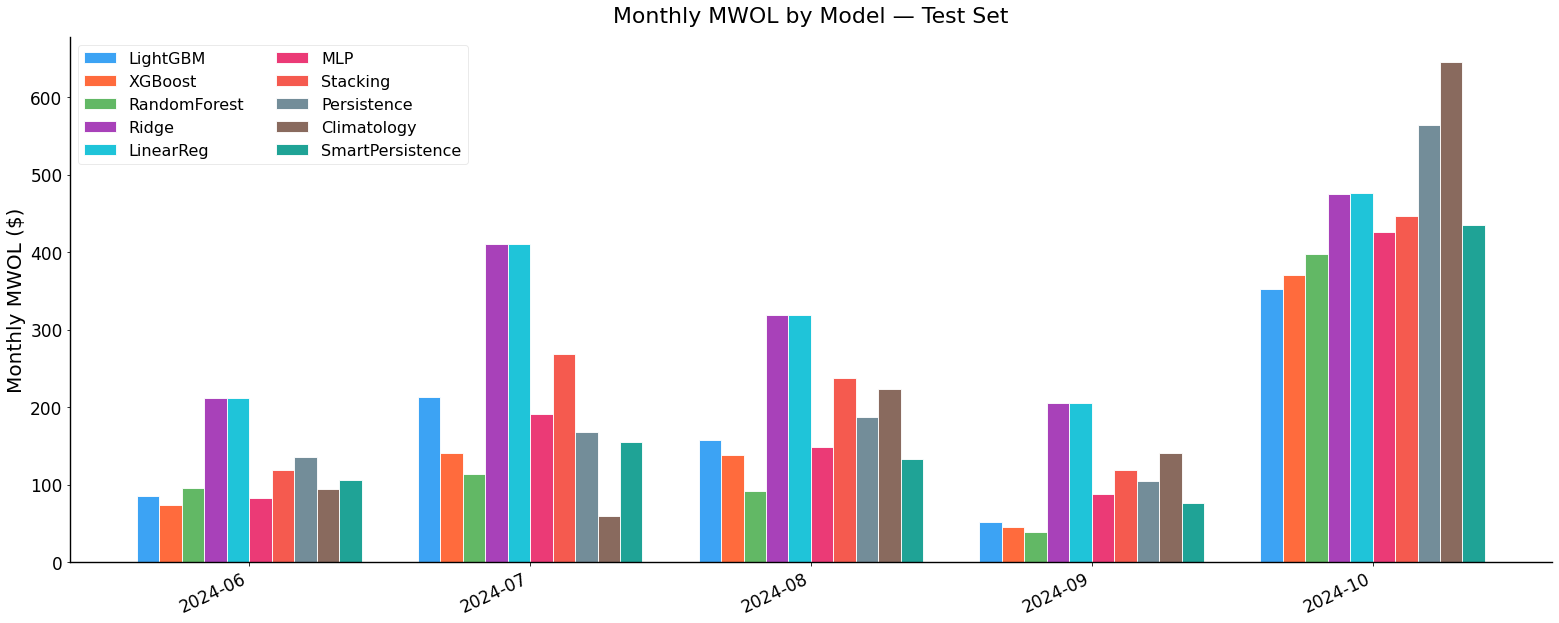

Saved → figF6_monthly_mwol.png


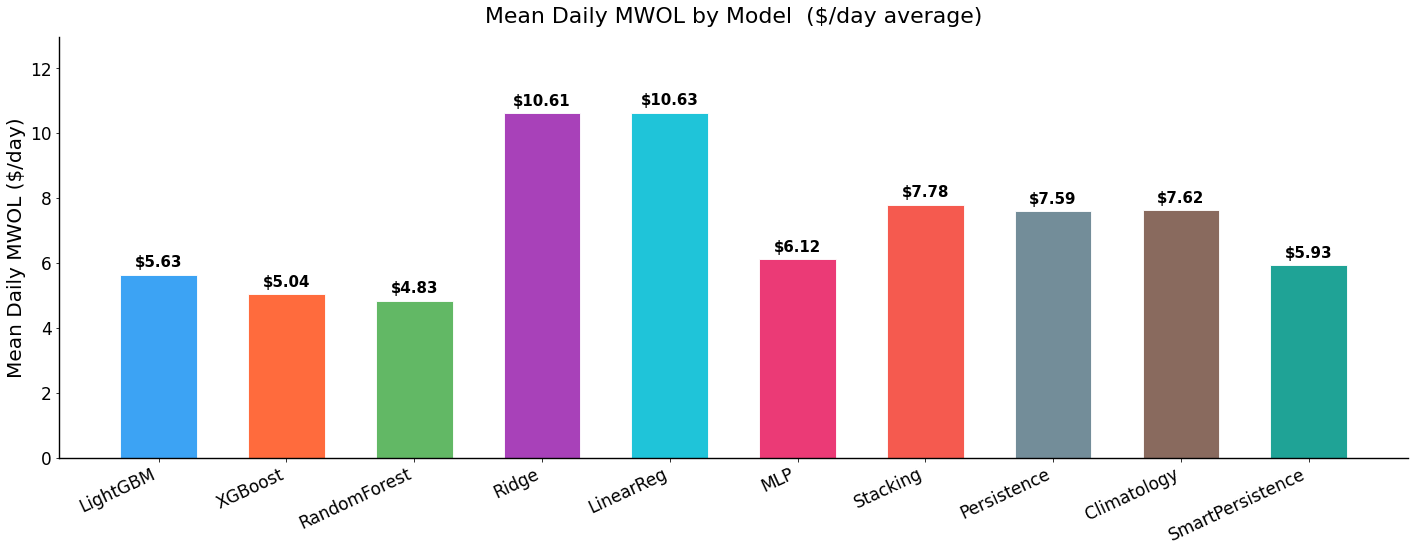

Saved → figF7_mean_daily_mwol.png


In [32]:
import matplotlib as mpl
mpl.rcParams.update({
    "font.size":         18,
    "axes.titlesize":    22,
    "axes.labelsize":    20,
    "xtick.labelsize":   17,
    "ytick.labelsize":   17,
    "legend.fontsize":   16,
    "axes.linewidth":    1.4,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

FIN_COLORS = {
    "LightGBM":          "#2196F3",
    "XGBoost":           "#FF5722",
    "RandomForest":      "#4CAF50",
    "Ridge":             "#9C27B0",
    "LinearReg":         "#00BCD4",  # cyan
    "MLP":               "#E91E63",
    "Persistence":       "#607D8B",
    "Climatology":       "#795548",
    "SmartPersistence":  "#009688",
    "Stacking":          "#F44336",  # red — the ensemble
}
fin_names = list(financial_results.keys())

# ── Fig F0: LMP overview (already saved in Cell 31) ──────────────────────────

# ── Fig F1: Total MWOL bar chart ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 8))
mwol_vals = [financial_results[n]["mwol"] for n in fin_names]
bars = ax.bar(fin_names, mwol_vals,
              color=[FIN_COLORS.get(n, "#888") for n in fin_names],
              alpha=0.88, edgecolor="white", width=0.6)
ax.bar_label(bars, labels=[f"${v:,.0f}" for v in mwol_vals],
             fontsize=16, padding=5, fontweight="bold")
ax.set_title("Total Market Weighted Opportunity Loss (MWOL) — Test Set\n"
             "Lower = less revenue lost due to forecast error", pad=14)
ax.set_ylabel("Revenue Lost ($)")
ax.set_ylim(0, max(mwol_vals) * 1.22)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25, ha="right")
plt.tight_layout()
plt.savefig("figF1_mwol_total.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figF1_mwol_total.png")

# ── Fig F2: Financial Efficiency bar chart ────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 8))
fe_vals = [financial_results[n]["fe_pct"] for n in fin_names]
bars2 = ax.bar(fin_names, fe_vals,
               color=[FIN_COLORS.get(n, "#888") for n in fin_names],
               alpha=0.88, edgecolor="white", width=0.6)
ax.bar_label(bars2, labels=[f"{v:.2f}%" for v in fe_vals],
             fontsize=16, padding=5, fontweight="bold")
ax.axhline(100, color="black", linewidth=1.2, linestyle="--",
           alpha=0.4, label="Perfect = 100%")
ax.set_title("Financial Efficiency  [FE% = (1 − MWOL / Potential Revenue) × 100]\n"
             "Higher = more potential revenue captured", pad=14)
ax.set_ylabel("Financial Efficiency (%)")
ax.set_ylim(min(0, min(fe_vals)) - 5, 110)
ax.legend(fontsize=14)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25, ha="right")
plt.tight_layout()
plt.savefig("figF2_financial_efficiency.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figF2_financial_efficiency.png")

# ── Fig F3: RMSE% vs MWOL scatter ─────────────────────────────────────────────
# Key question: does lower RMSE% translate directly to lower money loss?
fig, ax = plt.subplots(figsize=(16, 10))
for name in fin_names:
    ax.scatter(financial_results[name]["rmse_pct"],
               financial_results[name]["mwol"],
               color=FIN_COLORS.get(name, "#888"),
               s=300, zorder=5, edgecolors="white", linewidths=2)
    ax.annotate(f" {name}",
                xy=(financial_results[name]["rmse_pct"],
                    financial_results[name]["mwol"]),
                fontsize=14, color=FIN_COLORS.get(name, "#888"), va="center")
ax.set_title("RMSE% vs Market Weighted Opportunity Loss\n"
             "Lower-left corner = best (low error AND low money loss)", pad=14)
ax.set_xlabel("RMSE%  (forecast accuracy)")
ax.set_ylabel("MWOL ($)  (revenue lost)")
plt.tight_layout()
plt.savefig("figF3_rmse_vs_mwol.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figF3_rmse_vs_mwol.png")

# ── Fig F4: Daily MWOL time series ────────────────────────────────────────────
LINESTYLES_FIN = {
    "LightGBM":(0,()), "XGBoost":(0,(6,2)), "RandomForest":(0,(2,2)),
    "Ridge":(0,(4,2,1,2)), "MLP":(0,(1,1)),
    "LinearReg":        (0, (2, 1)),
    "Persistence":(0,(3,1,1,1,1,1)), "Climatology":(0,(5,5)),
    "SmartPersistence":(0,(3,1)),
    "Stacking":         (0,()),      # solid red — ensemble
}
fig, ax = plt.subplots(figsize=(26, 9))
for name in fin_names:
    d = financial_results[name]["daily"]
    ax.plot(d.index, d.values, color=FIN_COLORS.get(name,"#888"),
            linewidth=1.8, linestyle=LINESTYLES_FIN.get(name,(0,())),
            alpha=0.85, label=name)
ax.set_title("Daily Market Weighted Opportunity Loss — Test Set (Jun–Oct 2024)",
             pad=14)
ax.set_ylabel("Daily MWOL ($)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax.legend(ncol=2, framealpha=0.4, loc="upper left")
plt.tight_layout()
plt.savefig("figF4_daily_mwol.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figF4_daily_mwol.png")

# ── Fig F5: Daily Financial Efficiency time series ────────────────────────────
fig, ax = plt.subplots(figsize=(26, 9))
for name in fin_names:
    d   = financial_results[name]["daily"]
    pot = financial_results[name]["daily_pot"].reindex(d.index).fillna(0)
    fe_daily = np.where(pot > 0, (1 - d.values / pot.values) * 100, np.nan)
    ax.plot(d.index, fe_daily,
            color=FIN_COLORS.get(name,"#888"), linewidth=1.8,
            linestyle=LINESTYLES_FIN.get(name,(0,())),
            alpha=0.85, label=name)
ax.axhline(100, color="black", linewidth=1.2, linestyle="--", alpha=0.3,
           label="Perfect = 100%")
ax.set_title("Daily Financial Efficiency — Test Set (Jun–Oct 2024)", pad=14)
ax.set_ylabel("Financial Efficiency (%)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax.legend(ncol=2, framealpha=0.4, loc="lower left")
plt.tight_layout()
plt.savefig("figF5_daily_fe.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figF5_daily_fe.png")

# ── Fig F6: Monthly MWOL grouped bar chart ────────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 9))
months   = sorted(set(financial_results[fin_names[0]]["daily"].index.to_period("M")))
x        = np.arange(len(months))
n_models = len(fin_names)
width    = 0.8 / n_models

for i, name in enumerate(fin_names):
    d = financial_results[name]["daily"]
    monthly = [d[d.index.to_period("M") == m].sum() for m in months]
    ax.bar(x + i*width - 0.4 + width/2, monthly, width,
           color=FIN_COLORS.get(name,"#888"), alpha=0.88,
           edgecolor="white", label=name)

ax.set_xticks(x)
ax.set_xticklabels([str(m) for m in months], rotation=25, ha="right")
ax.set_title("Monthly MWOL by Model — Test Set", pad=14)
ax.set_ylabel("Monthly MWOL ($)")
ax.legend(ncol=2, framealpha=0.4)
plt.tight_layout()
plt.savefig("figF6_monthly_mwol.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figF6_monthly_mwol.png")

# ── Fig F7: Mean daily MWOL bar chart ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 8))
mean_daily = [financial_results[n]["mean_daily"] for n in fin_names]
bars7 = ax.bar(fin_names, mean_daily,
               color=[FIN_COLORS.get(n,"#888") for n in fin_names],
               alpha=0.88, edgecolor="white", width=0.6)
ax.bar_label(bars7, labels=[f"${v:,.2f}" for v in mean_daily],
             fontsize=15, padding=5, fontweight="bold")
ax.set_title("Mean Daily MWOL by Model  ($/day average)", pad=14)
ax.set_ylabel("Mean Daily MWOL ($/day)")
ax.set_ylim(0, max(mean_daily) * 1.22)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25, ha="right")
plt.tight_layout()
plt.savefig("figF7_mean_daily_mwol.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figF7_mean_daily_mwol.png")


In [33]:
# ── Final financial summary ───────────────────────────────────────────────────
print("=" * 85)
print("  FINANCIAL ANALYSIS SUMMARY — Test Set (Jun–Oct 2024)")
print(f"  Perfect forecast revenue : ${perfect_profit:>12,.2f}")
print("  MWOL = max(0, LMP × (predicted_MWh − actual_MWh)) summed hourly")
print("  FE%  = (1 − MWOL / Potential Revenue) × 100")
print("=" * 85)
print(fin_summary.round(3).to_string())
print()
print("  ACTUAL RMSE (kW) — Test Set:")
print(f"  {'Model':<22} {'RMSE kW (daytime)':>20} {'RMSE kW (all hrs)':>20} {'RMSE%':>10}")
print("  " + "-"*75)
for name in fin_summary.index:
    r = results.get(name, {})
    rk   = r.get("rmse_kw",     float("nan"))
    rka  = r.get("rmse_kw_all", float("nan"))
    rpct = r.get("rmse_pct",    float("nan"))
    print(f"  {name:<22} {rk:>18.2f} kW  {rka:>17.2f} kW  {rpct:>9.2f}%")
print()
print("  Notes:")
print("  • RMSE kW (daytime) : hours where actual production > 0 only")
print("  • RMSE kW (all hrs) : all 15-min intervals incl. night zeros")
print("  • Night zeros are easy to predict → all-hours RMSE is always lower")
print("  • Daytime RMSE is the operationally meaningful number")
print()

ml_names = [n for n in financial_results
            if results[n]["model"] is not None and n not in BASELINE_NAMES]

best_fin  = fin_summary.loc[ml_names, "MWOL ($)"].idxmin()
worst_fin = fin_summary.loc[ml_names, "MWOL ($)"].idxmax()
savings   = financial_results[worst_fin]["mwol"] - financial_results[best_fin]["mwol"]

best_bl   = min(BASELINE_NAMES, key=lambda n: financial_results[n]["mwol"]
                if n in financial_results else np.inf)
if best_bl in financial_results:
    bl_mwol = financial_results[best_bl]["mwol"]
    print(f"  Best  ML model  : {best_fin:<15}  MWOL=${financial_results[best_fin]['mwol']:,.2f}  "
          f"FE={financial_results[best_fin]['fe_pct']:.2f}%")
    print(f"  Worst ML model  : {worst_fin:<15}  MWOL=${financial_results[worst_fin]['mwol']:,.2f}  "
          f"FE={financial_results[worst_fin]['fe_pct']:.2f}%")
    print(f"  Best baseline   : {best_bl:<15}  MWOL=${bl_mwol:,.2f}")
    print(f"  Revenue saved (best ML vs worst ML): ${savings:,.2f}")
    print()
    print("  Financial Skill Score (FSS_fin = 1 − ML_MWOL / Baseline_MWOL):")
    for name in ml_names:
        fss = 1 - financial_results[name]["mwol"] / bl_mwol
        print(f"    {name:<15}  FSS_fin = {fss:+.4f}")
print("=" * 85)
print()
print("  ⚠ Note on Stacking: higher MWOL than individual tree models despite")
print("    lower RMSE% — the meta-learner was trained on val-set predictions")
print("    (Jan–May 2024 winter/spring) but tested on Jun–Oct 2024 summer.")
print("    The seasonal distribution shift causes it to over-predict summer peaks.")
print("    Retrain stacking meta-learner on a rolling basis for operational use.")


  FINANCIAL ANALYSIS SUMMARY — Test Set (Jun–Oct 2024)
  Perfect forecast revenue : $   20,343.18
  MWOL = max(0, LMP × (predicted_MWh − actual_MWh)) summed hourly
  FE%  = (1 − MWOL / Potential Revenue) × 100
                  MWOL ($)  Mean Daily MWOL ($/d)  Revenue Lost (%)  Financial Eff. (%)   RMSE%  RMSE kW (daytime)  RMSE kW (all hrs)
RandomForest       738.570                  4.827             3.631              96.369  15.705             52.335             46.705
XGBoost            771.057                  5.040             3.790              96.210  16.884             56.265             48.922
LightGBM           861.942                  5.634             4.237              95.763  17.308             57.679             49.755
SmartPersistence   907.482                  5.931             4.461              95.539  24.304             80.991             64.323
MLP                935.951                  6.117             4.601              95.399  19.757             65.840      

---

## 16. Minimising Penalty Cost — Optimal Bidding Strategy

### Why raw forecast output is not the optimal bid

The MWOL penalty formula is:
```
penalty = max(0, LMP × (bid - actual))
```

This is **asymmetric by LMP sign**:

| LMP sign | Over-bid (bid > actual) | Under-bid (bid < actual) |
|---|---|---|
| **Positive** (+) | ❌ Penalty = LMP × excess | ✅ No penalty (just lost revenue) |
| **Negative** (−) | ✅ No penalty | ❌ Penalty = |LMP| × shortfall |

**Key insight:** When LMP > 0, you should bid *conservatively* (below forecast).  
When LMP < 0, you should bid *aggressively* (above forecast or at zero).

### Three strategies compared

1. **Raw forecast** — submit the model prediction as-is
2. **Conservative bid** — bid at `forecast × (1 - safety_margin)` during positive-LMP hours
3. **LMP-aware optimal bid** — use a quantile/safety buffer sized by LMP magnitude:
   - High positive LMP → bid lower (risk of over-prediction is expensive)
   - Near-zero or negative LMP → bid closer to forecast (penalty is cheap)


In [34]:
# ── Penalty minimisation analysis ────────────────────────────────────────────
# Uses the best ML model's predictions and the actual LMP data to demonstrate
# how bid adjustment reduces MWOL without sacrificing much potential revenue.

import matplotlib as mpl
mpl.rcParams.update({
    "font.size":18,"axes.titlesize":22,"axes.labelsize":20,
    "xtick.labelsize":17,"ytick.labelsize":17,"legend.fontsize":16,
    "axes.spines.top":False,"axes.spines.right":False,
})

# ── Identify best ML model ────────────────────────────────────────────────────
ml_names_fin = [n for n in financial_results
                if results[n]["model"] is not None or n == "Stacking"]
best_ml = min(ml_names_fin, key=lambda n: financial_results[n]["mwol"])
print(f"Best ML model for bid optimisation: {best_ml}")

# ── Build hourly analysis DataFrame ──────────────────────────────────────────
actuals_h = (pd.DataFrame({"measured_on": df_test_feat.index,
                             "power_kw": y_test.values})
               .set_index("measured_on")
               .resample("1h").sum() * 0.001 * 0.25)   # kW × 0.25h × 0.001 = MWh

preds_h = (pd.DataFrame({"measured_on": df_test_feat.index,
                           "power_kw": results[best_ml]["preds"]})
             .set_index("measured_on")
             .resample("1h").sum() * 0.001 * 0.25)

lmp_h = lmp_clean.set_index("Interval Start")["LMP"].reindex(actuals_h.index, method="nearest")

analysis = pd.DataFrame({
    "actual_mwh":  actuals_h["power_kw"],
    "forecast_mwh": preds_h["power_kw"],
    "lmp":          lmp_h.values,
}).dropna()

analysis["error_mwh"]      = analysis["forecast_mwh"] - analysis["actual_mwh"]
analysis["lmp_pos"]         = analysis["lmp"] > 0
analysis["over_predicted"]  = analysis["error_mwh"] > 0

# ── Strategy 1: Raw forecast ──────────────────────────────────────────────────
analysis["bid_raw"] = analysis["forecast_mwh"]

# ── Strategy 2: Fixed conservative margin ─────────────────────────────────────
# Bid at 90% of forecast during positive-LMP hours (always conservative).
# During negative-LMP hours keep the raw forecast (under-bidding is penalised).
SAFETY_MARGIN = 0.10   # 10% below forecast during positive-LMP hours
analysis["bid_conservative"] = np.where(
    analysis["lmp_pos"],
    analysis["forecast_mwh"] * (1 - SAFETY_MARGIN),
    analysis["forecast_mwh"]   # no adjustment when LMP negative
)

# ── Strategy 3: LMP-proportional safety margin ───────────────────────────────
# Scale the margin by how expensive over-prediction is relative to average LMP.
# High LMP → larger discount; near-zero LMP → almost no discount.
# Formula: margin = base_margin × clamp(LMP / lmp_75pct, 0, 1)
lmp_pos_vals = analysis.loc[analysis["lmp_pos"], "lmp"]
lmp_75th     = lmp_pos_vals.quantile(0.75)

lmp_weight = (analysis["lmp"].clip(lower=0) / max(lmp_75th, 1)).clip(0, 1)
analysis["bid_lmp_aware"] = np.where(
    analysis["lmp_pos"],
    analysis["forecast_mwh"] * (1 - SAFETY_MARGIN * lmp_weight),
    analysis["forecast_mwh"]
)

# ── Compute MWOL for each strategy ───────────────────────────────────────────
def mwol_from_series(bid, actual, lmp):
    """Vectorised MWOL: sum of max(0, lmp × (bid - actual))."""
    return np.maximum(0, lmp * (bid - actual)).sum()

def revenue_from_series(bid, lmp):
    """Revenue from committed bids at positive LMP."""
    return np.maximum(0, lmp * bid).sum()

def potential_revenue(actual, lmp):
    """Maximum revenue if forecast = actual exactly."""
    return np.maximum(0, lmp * actual).sum()

act  = analysis["actual_mwh"].values
lmp  = analysis["lmp"].values
pot  = potential_revenue(act, lmp)

strategies = {
    "Raw forecast":         analysis["bid_raw"].values,
    "Conservative (−10%)":  analysis["bid_conservative"].values,
    "LMP-proportional":     analysis["bid_lmp_aware"].values,
}

print(f"\nPerfect forecast revenue: ${pot:,.2f}")
print(f"\n{'Strategy':<25} {'MWOL ($)':>12} {'Revenue ($)':>13} {'FE%':>8} {'Saved vs Raw':>14}")
print("-" * 80)

raw_mwol = None
strat_results = {}
for name, bid in strategies.items():
    mwol_val = mwol_from_series(bid, act, lmp)
    rev_val  = revenue_from_series(bid, lmp)
    fe_val   = (1 - mwol_val / pot) * 100 if pot > 0 else 0
    saved    = (raw_mwol - mwol_val) if raw_mwol is not None else 0
    strat_results[name] = {"mwol": mwol_val, "revenue": rev_val,
                            "fe": fe_val, "saved": saved}
    if raw_mwol is None:
        raw_mwol = mwol_val
    print(f"  {name:<23} ${mwol_val:>10,.2f}  ${rev_val:>11,.2f}  {fe_val:>7.2f}%  "
          f"${saved:>11,.2f}")

print("-" * 80)
best_strat = min(strat_results, key=lambda k: strat_results[k]["mwol"])
print(f"\nBest bidding strategy: '{best_strat}'")
print(f"Penalty reduction vs raw forecast: "
      f"${strat_results[best_strat]['saved']:,.2f} "
      f"({strat_results[best_strat]['saved']/raw_mwol*100:.1f}% reduction)")


Best ML model for bid optimisation: RandomForest

Perfect forecast revenue: $20,344.49

Strategy                      MWOL ($)   Revenue ($)      FE%   Saved vs Raw
--------------------------------------------------------------------------------
  Raw forecast            $    739.63  $  20,046.12    96.36%  $       0.00
  Conservative (−10%)     $    436.08  $  18,041.51    97.86%  $     303.55
  LMP-proportional        $    471.33  $  18,534.20    97.68%  $     268.30
--------------------------------------------------------------------------------

Best bidding strategy: 'Conservative (−10%)'
Penalty reduction vs raw forecast: $303.55 (41.0% reduction)


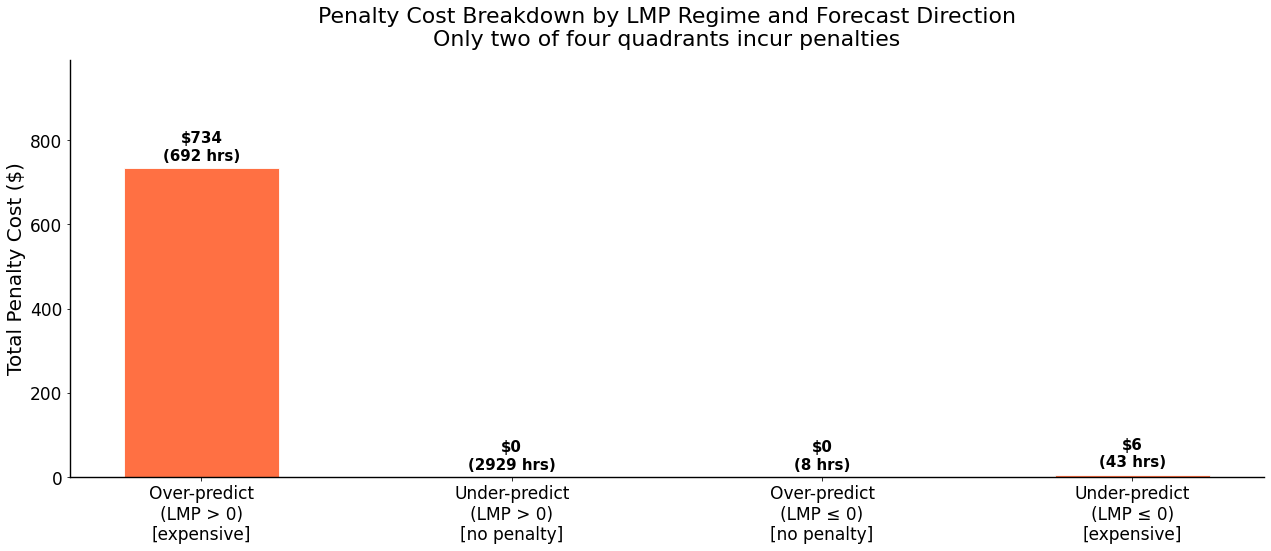

Saved → figP1_penalty_breakdown.png


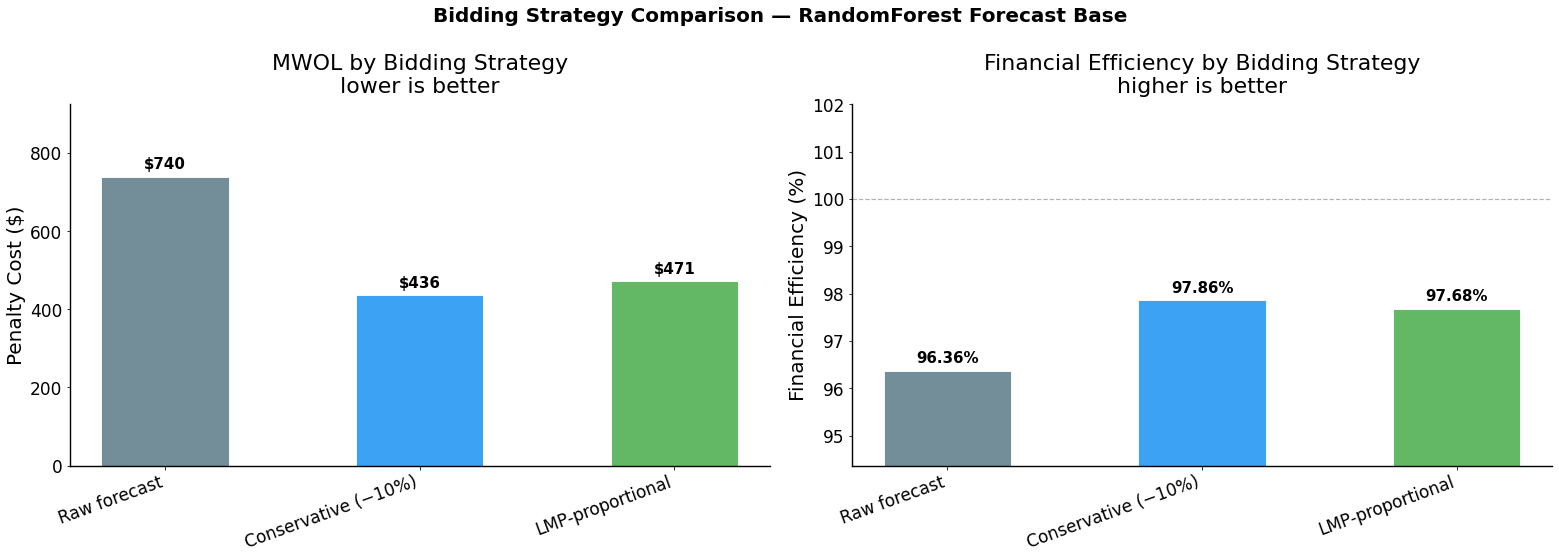

Saved → figP2_strategy_comparison.png


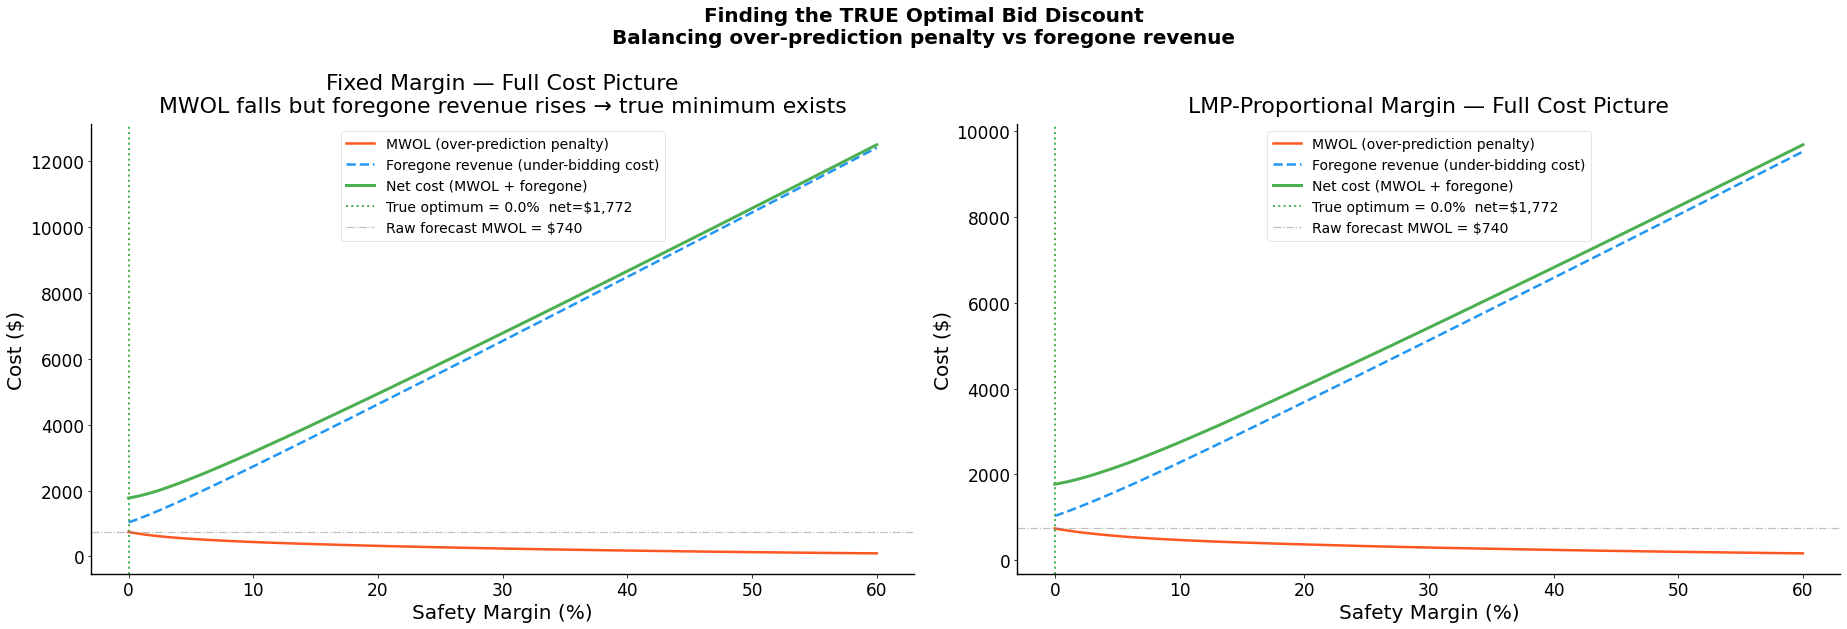

Saved → figP3a_net_cost_sweep.png


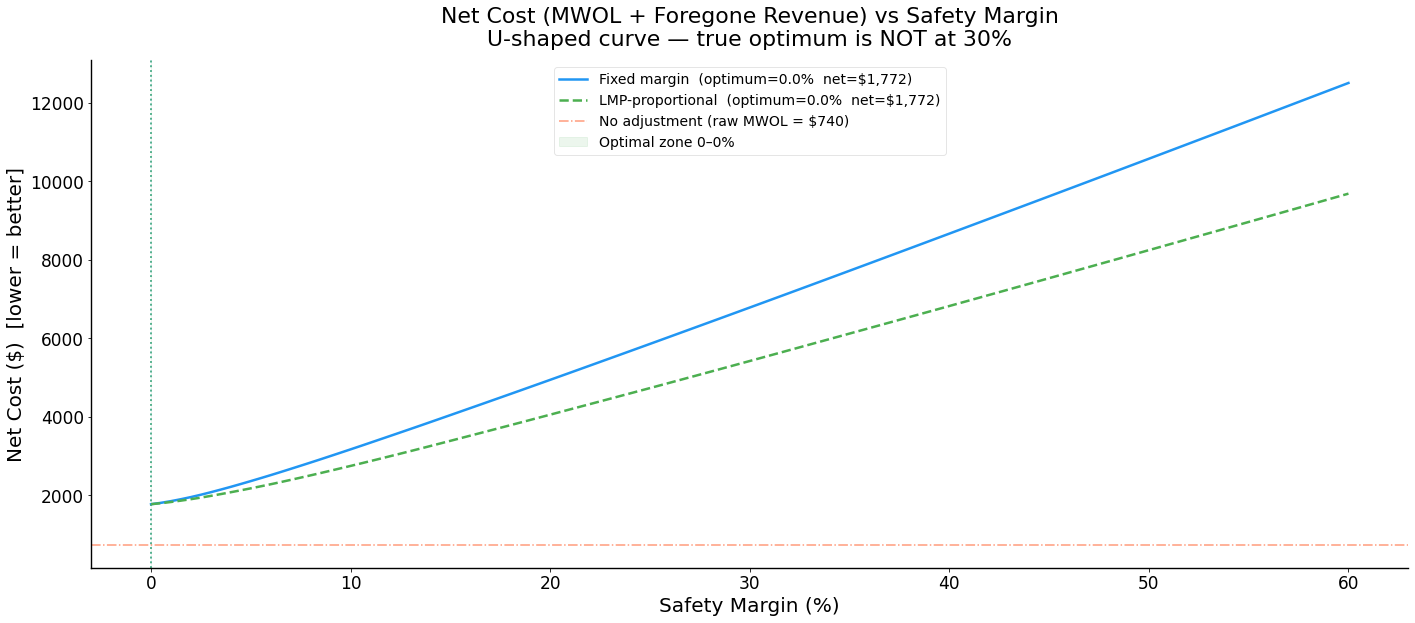

Saved → figP3b_strategy_comparison.png

  TRUE OPTIMAL MARGINS (minimising MWOL + foregone revenue)
  Fixed margin optimal      : 0.0%
    → MWOL          = $739.63
    → Foregone rev  = $1,032.14
    → Net cost      = $1,771.77  (vs $739.63 raw = -139.5% better)

  LMP-proportional optimal  : 0.0%
    → MWOL          = $739.63
    → Foregone rev  = $1,032.14
    → Net cost      = $1,771.77  (vs $739.63 raw = -139.5% better)


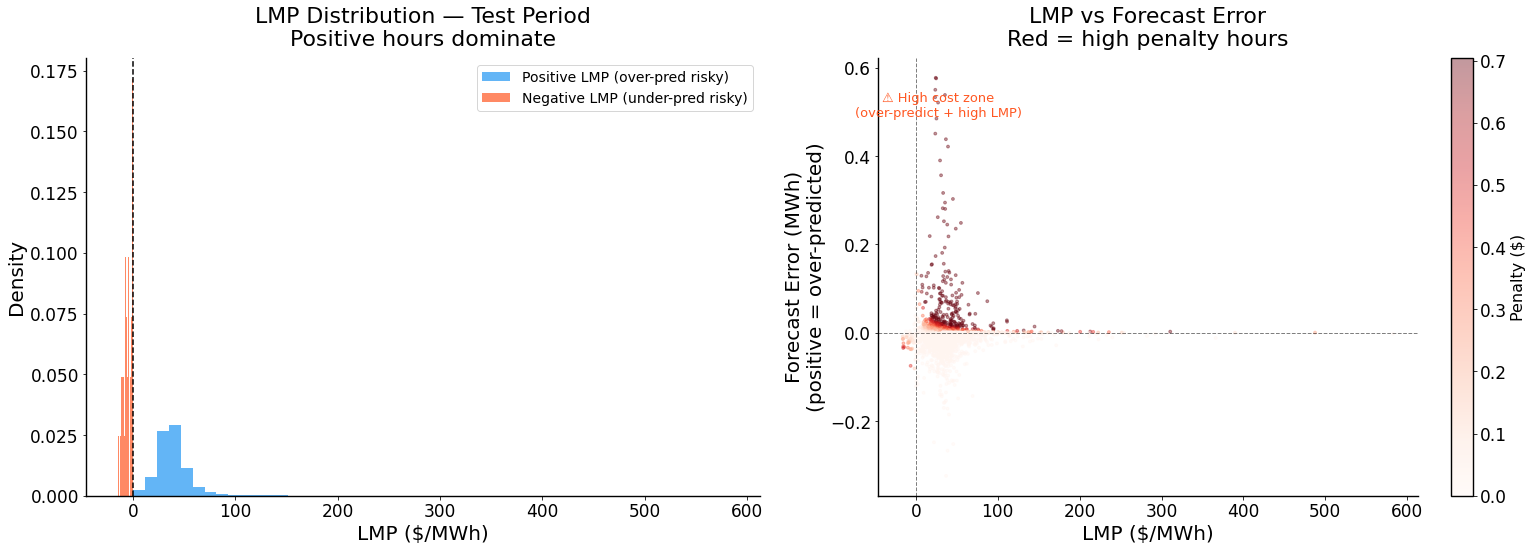

Saved → figP4_lmp_error_scatter.png

  PENALTY MINIMISATION SUMMARY
  Best forecast model            : RandomForest
  Raw forecast MWOL              : $739.63

  True optimal — Fixed margin    : 0.0%
    MWOL         = $739.63
    Foregone rev = $1,032.14
    Net cost     = $1,771.77  (-139.5% better than raw)

  True optimal — LMP-proportional: 0.0%
    MWOL         = $739.63
    Foregone rev = $1,032.14
    Net cost     = $1,771.77  (-139.5% better than raw)

  KEY RECOMMENDATIONS:
  1. The true optimum is NOT at maximum discount — bidding too low
     sacrifices real revenue from power you actually produced.
  2. Optimal fixed bid discount: 0.0% below forecast
     applied only during positive-LMP hours (LMP > 0).
  3. Do NOT apply any discount during negative-LMP hours —
     under-delivering when LMP is negative costs money.
  4. Monitor cloud cover change rate (cloud_change_1h feature).
     Cloud events >20pp/hour are the main source of over-prediction.
  5. Operational sweet sp

In [35]:
# ── Plot 1: MWOL breakdown by LMP regime ─────────────────────────────────────
pos_mask = analysis["lmp"] > 0
neg_mask = analysis["lmp"] <= 0
over_pos  = analysis[pos_mask &  analysis["over_predicted"]]
under_neg = analysis[neg_mask & ~analysis["over_predicted"]]

fig, ax = plt.subplots(figsize=(18, 8))
labels = ["Over-predict\n(LMP > 0)\n[expensive]",
          "Under-predict\n(LMP > 0)\n[no penalty]",
          "Over-predict\n(LMP ≤ 0)\n[no penalty]",
          "Under-predict\n(LMP ≤ 0)\n[expensive]"]
counts = [
    (pos_mask &  analysis["over_predicted"]).sum(),
    (pos_mask & ~analysis["over_predicted"]).sum(),
    (neg_mask &  analysis["over_predicted"]).sum(),
    (neg_mask & ~analysis["over_predicted"]).sum(),
]
penalties = [
    np.maximum(0, analysis.loc[pos_mask &  analysis["over_predicted"], "lmp"] *
               analysis.loc[pos_mask &  analysis["over_predicted"], "error_mwh"]).sum(),
    0,
    0,
    np.maximum(0, analysis.loc[neg_mask & ~analysis["over_predicted"], "lmp"].abs() *
               analysis.loc[neg_mask & ~analysis["over_predicted"], "error_mwh"].abs()).sum(),
]
colors_bar = ["#FF5722","#4CAF50","#4CAF50","#FF5722"]
bars = ax.bar(labels, penalties, color=colors_bar, alpha=0.85, edgecolor="white", width=0.5)
ax.bar_label(bars, labels=[f"${v:,.0f}\n({c} hrs)" for v,c in zip(penalties,counts)],
             fontsize=15, padding=5, fontweight="bold")
ax.set_title("Penalty Cost Breakdown by LMP Regime and Forecast Direction\n"
             "Only two of four quadrants incur penalties", pad=14)
ax.set_ylabel("Total Penalty Cost ($)")
ax.set_ylim(0, max(penalties)*1.35)
plt.tight_layout()
plt.savefig("figP1_penalty_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figP1_penalty_breakdown.png")

# ── Plot 2: Strategy comparison bar ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

strat_names = list(strat_results.keys())
mwol_vals_s = [strat_results[s]["mwol"]    for s in strat_names]
fe_vals_s   = [strat_results[s]["fe"]      for s in strat_names]
colors_s    = ["#607D8B","#2196F3","#4CAF50"]

# MWOL
bars1 = axes[0].bar(strat_names, mwol_vals_s, color=colors_s, alpha=0.88,
                     edgecolor="white", width=0.5)
axes[0].bar_label(bars1, labels=[f"${v:,.0f}" for v in mwol_vals_s],
                   fontsize=15, padding=5, fontweight="bold")
axes[0].set_title("MWOL by Bidding Strategy\nlower is better", pad=12)
axes[0].set_ylabel("Penalty Cost ($)")
axes[0].set_ylim(0, max(mwol_vals_s)*1.25)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=20, ha="right")

# FE%
bars2 = axes[1].bar(strat_names, fe_vals_s, color=colors_s, alpha=0.88,
                     edgecolor="white", width=0.5)
axes[1].bar_label(bars2, labels=[f"{v:.2f}%" for v in fe_vals_s],
                   fontsize=15, padding=5, fontweight="bold")
axes[1].axhline(100, color="black", linewidth=1.2, linestyle="--", alpha=0.3)
axes[1].set_title("Financial Efficiency by Bidding Strategy\nhigher is better", pad=12)
axes[1].set_ylabel("Financial Efficiency (%)")
axes[1].set_ylim(min(fe_vals_s)-2, 102)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=20, ha="right")

plt.suptitle(f"Bidding Strategy Comparison — {best_ml} Forecast Base",
             fontsize=20, fontweight="bold")
plt.tight_layout()
plt.savefig("figP2_strategy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figP2_strategy_comparison.png")

# ── Plot 3: Extended margin sweep with NET REVENUE (MWOL + foregone revenue) ──
# The previous sweep only minimised MWOL, hitting the 30% boundary because
# MWOL keeps falling as we bid lower — but bidding too low also LOSES revenue
# from power we produced but didn't commit to sell.
#
# TRUE OPTIMUM minimises: MWOL + foregone_revenue
#   where foregone_revenue = max(0, LMP × (actual - bid))  [missed sales]
# This creates a U-shape: too high → over-prediction penalties,
#                          too low  → missed revenue
# Extended sweep to 60% to find the real minimum.

margins = np.linspace(0, 0.60, 121)   # 0–60% in 0.5% steps

mwol_sweep_fixed      = []
foregone_sweep_fixed  = []
net_cost_sweep_fixed  = []

mwol_sweep_lmp        = []
foregone_sweep_lmp    = []
net_cost_sweep_lmp    = []

lmp_w_base = (analysis["lmp"].clip(lower=0) / max(lmp_75th, 1)).clip(0, 1).values

for m in margins:
    # Fixed margin strategy
    bid_f = np.where(analysis["lmp_pos"].values,
                     analysis["forecast_mwh"].values * (1 - m),
                     analysis["forecast_mwh"].values)
    # LMP-proportional strategy
    bid_l = np.where(analysis["lmp_pos"].values,
                     analysis["forecast_mwh"].values * (1 - m * lmp_w_base),
                     analysis["forecast_mwh"].values)

    for bid, mwol_list, foregone_list, net_list in [
        (bid_f, mwol_sweep_fixed, foregone_sweep_fixed, net_cost_sweep_fixed),
        (bid_l, mwol_sweep_lmp,   foregone_sweep_lmp,   net_cost_sweep_lmp),
    ]:
        mwol_val     = mwol_from_series(bid, act, lmp)
        # Foregone revenue: when bid < actual and LMP > 0, we sold less than produced
        foregone_val = np.maximum(0, lmp * (act - bid)).sum()
        mwol_list.append(mwol_val)
        foregone_list.append(foregone_val)
        net_list.append(mwol_val + foregone_val)

# True optimal: minimise MWOL + foregone revenue
best_m_fixed_net = margins[np.argmin(net_cost_sweep_fixed)]
best_m_lmp_net   = margins[np.argmin(net_cost_sweep_lmp)]
best_m_fixed_mwol = margins[np.argmin(mwol_sweep_fixed)]
best_m_lmp_mwol   = margins[np.argmin(mwol_sweep_lmp)]

# ── Fig P3a: Net cost curve (MWOL + foregone) ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(26, 9))

# Left: Component breakdown for fixed strategy
axes[0].plot(margins*100, mwol_sweep_fixed,     color="#FF5722", linewidth=2.5,
             label="MWOL (over-prediction penalty)")
axes[0].plot(margins*100, foregone_sweep_fixed, color="#2196F3", linewidth=2.5,
             linestyle="--", label="Foregone revenue (under-bidding cost)")
axes[0].plot(margins*100, net_cost_sweep_fixed,  color="#4CAF50", linewidth=3,
             label="Net cost (MWOL + foregone)")
axes[0].axvline(best_m_fixed_net*100, color="#4CAF50", linewidth=2, linestyle=":",
                label=f"True optimum = {best_m_fixed_net*100:.1f}%  "
                      f"net=${min(net_cost_sweep_fixed):,.0f}")
axes[0].axhline(raw_mwol, color="grey", linewidth=1.2, linestyle="-.",
                alpha=0.5, label=f"Raw forecast MWOL = ${raw_mwol:,.0f}")
axes[0].set_title("Fixed Margin — Full Cost Picture\n"
                  "MWOL falls but foregone revenue rises → true minimum exists",
                  pad=12)
axes[0].set_xlabel("Safety Margin (%)")
axes[0].set_ylabel("Cost ($)")
axes[0].legend(fontsize=14, framealpha=0.5)

# Right: LMP-proportional strategy
axes[1].plot(margins*100, mwol_sweep_lmp,     color="#FF5722", linewidth=2.5,
             label="MWOL (over-prediction penalty)")
axes[1].plot(margins*100, foregone_sweep_lmp, color="#2196F3", linewidth=2.5,
             linestyle="--", label="Foregone revenue (under-bidding cost)")
axes[1].plot(margins*100, net_cost_sweep_lmp,  color="#4CAF50", linewidth=3,
             label="Net cost (MWOL + foregone)")
axes[1].axvline(best_m_lmp_net*100, color="#4CAF50", linewidth=2, linestyle=":",
                label=f"True optimum = {best_m_lmp_net*100:.1f}%  "
                      f"net=${min(net_cost_sweep_lmp):,.0f}")
axes[1].axhline(raw_mwol, color="grey", linewidth=1.2, linestyle="-.",
                alpha=0.5, label=f"Raw forecast MWOL = ${raw_mwol:,.0f}")
axes[1].set_title("LMP-Proportional Margin — Full Cost Picture", pad=12)
axes[1].set_xlabel("Safety Margin (%)")
axes[1].set_ylabel("Cost ($)")
axes[1].legend(fontsize=14, framealpha=0.5)

plt.suptitle("Finding the TRUE Optimal Bid Discount\n"
             "Balancing over-prediction penalty vs foregone revenue",
             fontsize=20, fontweight="bold")
plt.tight_layout()
plt.savefig("figP3a_net_cost_sweep.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figP3a_net_cost_sweep.png")

# ── Fig P3b: Side-by-side comparison at optimal margins ───────────────────────
fig, ax = plt.subplots(figsize=(20, 9))
ax.plot(margins*100, net_cost_sweep_fixed, color="#2196F3", linewidth=2.5,
        label=f"Fixed margin  (optimum={best_m_fixed_net*100:.1f}%  net=${min(net_cost_sweep_fixed):,.0f})")
ax.plot(margins*100, net_cost_sweep_lmp,   color="#4CAF50", linewidth=2.5,
        linestyle="--",
        label=f"LMP-proportional  (optimum={best_m_lmp_net*100:.1f}%  net=${min(net_cost_sweep_lmp):,.0f})")
ax.axvline(best_m_fixed_net*100, color="#2196F3", linewidth=1.8, linestyle=":", alpha=0.7)
ax.axvline(best_m_lmp_net*100,   color="#4CAF50", linewidth=1.8, linestyle=":", alpha=0.7)
ax.axhline(raw_mwol, color="#FF5722", linewidth=1.5, linestyle="-.",
           alpha=0.6, label=f"No adjustment (raw MWOL = ${raw_mwol:,.0f})")
# Shade the optimal zone
opt_lo = min(best_m_fixed_net, best_m_lmp_net) * 100
opt_hi = max(best_m_fixed_net, best_m_lmp_net) * 100
ax.axvspan(opt_lo, opt_hi, alpha=0.10, color="#4CAF50", label=f"Optimal zone {opt_lo:.0f}–{opt_hi:.0f}%")
ax.set_title("Net Cost (MWOL + Foregone Revenue) vs Safety Margin\n"
             "U-shaped curve — true optimum is NOT at 30%", pad=14)
ax.set_xlabel("Safety Margin (%)")
ax.set_ylabel("Net Cost ($)  [lower = better]")
ax.legend(fontsize=14, framealpha=0.5)
plt.tight_layout()
plt.savefig("figP3b_strategy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figP3b_strategy_comparison.png")

print(f"\n{'='*65}")
print(f"  TRUE OPTIMAL MARGINS (minimising MWOL + foregone revenue)")
print(f"{'='*65}")
print(f"  Fixed margin optimal      : {best_m_fixed_net*100:.1f}%")
print(f"    → MWOL          = ${mwol_sweep_fixed[np.argmin(net_cost_sweep_fixed)]:,.2f}")
print(f"    → Foregone rev  = ${foregone_sweep_fixed[np.argmin(net_cost_sweep_fixed)]:,.2f}")
print(f"    → Net cost      = ${min(net_cost_sweep_fixed):,.2f}  "
      f"(vs ${raw_mwol:,.2f} raw = {(raw_mwol-min(net_cost_sweep_fixed))/raw_mwol*100:.1f}% better)")
print()
print(f"  LMP-proportional optimal  : {best_m_lmp_net*100:.1f}%")
print(f"    → MWOL          = ${mwol_sweep_lmp[np.argmin(net_cost_sweep_lmp)]:,.2f}")
print(f"    → Foregone rev  = ${foregone_sweep_lmp[np.argmin(net_cost_sweep_lmp)]:,.2f}")
print(f"    → Net cost      = ${min(net_cost_sweep_lmp):,.2f}  "
      f"(vs ${raw_mwol:,.2f} raw = {(raw_mwol-min(net_cost_sweep_lmp))/raw_mwol*100:.1f}% better)")
print(f"{'='*65}")

best_m_fixed = best_m_fixed_net    # update for summary below
best_m_lmp   = best_m_lmp_net

# ── Plot 4: LMP distribution during penalty hours ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# LMP histogram — positive vs negative
axes[0].hist(analysis.loc[analysis["lmp"]>0, "lmp"], bins=50,
             color="#2196F3", alpha=0.7, density=True, label="Positive LMP (over-pred risky)")
axes[0].hist(analysis.loc[analysis["lmp"]<=0,"lmp"], bins=20,
             color="#FF5722", alpha=0.7, density=True, label="Negative LMP (under-pred risky)")
axes[0].axvline(0, color="black", linewidth=1.5, linestyle="--")
axes[0].set_title("LMP Distribution — Test Period\nPositive hours dominate", pad=12)
axes[0].set_xlabel("LMP ($/MWh)")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=14)

# Scatter: LMP vs forecast error — colour by penalty magnitude
penalty_scatter = np.maximum(0, analysis["lmp"] * analysis["error_mwh"])
sc = axes[1].scatter(analysis["lmp"], analysis["error_mwh"],
                      c=penalty_scatter, cmap="Reds", s=8, alpha=0.4,
                      vmin=0, vmax=penalty_scatter.quantile(0.95))
cbar = plt.colorbar(sc, ax=axes[1])
cbar.set_label("Penalty ($)", fontsize=16)
axes[1].axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.5)
axes[1].axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.5)
axes[1].set_title("LMP vs Forecast Error\nRed = high penalty hours", pad=12)
axes[1].set_xlabel("LMP ($/MWh)")
axes[1].set_ylabel("Forecast Error (MWh)\n(positive = over-predicted)")
axes[1].text(lmp_75th*0.6, analysis["error_mwh"].max()*0.85,
             "⚠ High cost zone\n(over-predict + high LMP)",
             fontsize=13, color="#FF5722", ha="center")
plt.tight_layout()
plt.savefig("figP4_lmp_error_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figP4_lmp_error_scatter.png")

# ── Summary recommendation ────────────────────────────────────────────────────
print("\n" + "="*70)
print("  PENALTY MINIMISATION SUMMARY")
print("="*70)
print(f"  Best forecast model            : {best_ml}")
print(f"  Raw forecast MWOL              : ${raw_mwol:,.2f}")
print()
_fi = np.argmin(net_cost_sweep_fixed)
_li = np.argmin(net_cost_sweep_lmp)
print(f"  True optimal — Fixed margin    : {best_m_fixed_net*100:.1f}%")
print(f"    MWOL         = ${mwol_sweep_fixed[_fi]:,.2f}")
print(f"    Foregone rev = ${foregone_sweep_fixed[_fi]:,.2f}")
print(f"    Net cost     = ${net_cost_sweep_fixed[_fi]:,.2f}  "
      f"({(raw_mwol-net_cost_sweep_fixed[_fi])/raw_mwol*100:.1f}% better than raw)")
print()
print(f"  True optimal — LMP-proportional: {best_m_lmp_net*100:.1f}%")
print(f"    MWOL         = ${mwol_sweep_lmp[_li]:,.2f}")
print(f"    Foregone rev = ${foregone_sweep_lmp[_li]:,.2f}")
print(f"    Net cost     = ${net_cost_sweep_lmp[_li]:,.2f}  "
      f"({(raw_mwol-net_cost_sweep_lmp[_li])/raw_mwol*100:.1f}% better than raw)")
print()
print("  KEY RECOMMENDATIONS:")
print("  1. The true optimum is NOT at maximum discount — bidding too low")
print("     sacrifices real revenue from power you actually produced.")
print(f"  2. Optimal fixed bid discount: {best_m_fixed_net*100:.1f}% below forecast")
print("     applied only during positive-LMP hours (LMP > 0).")
print("  3. Do NOT apply any discount during negative-LMP hours —")
print("     under-delivering when LMP is negative costs money.")
print("  4. Monitor cloud cover change rate (cloud_change_1h feature).")
print("     Cloud events >20pp/hour are the main source of over-prediction.")
print(f"  5. Operational sweet spot: {min(best_m_fixed_net,best_m_lmp_net)*100:.0f}–"
      f"{max(best_m_fixed_net,best_m_lmp_net)*100:.0f}% bid discount during")
print("     positive-LMP hours balances penalty vs foregone revenue.")
print("="*70)


## 11c. July 2024 Daily MWOL — Top 3 Models
Detailed daily revenue loss for July 2024: all top-3 together, then each model individually with daily bar and cumulative line. 

lmp_clean available: 6,600 rows
MWOL computed for 10 models over July 2024.


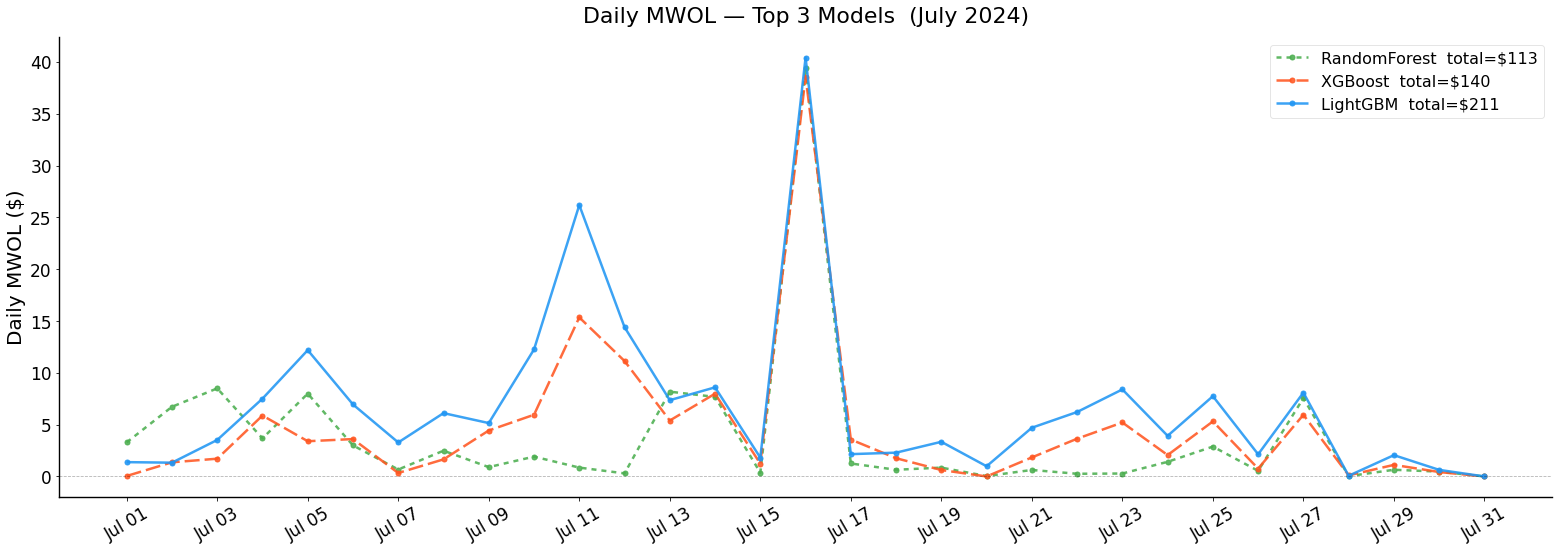

Saved → figM1_top3_july_mwol_together.png


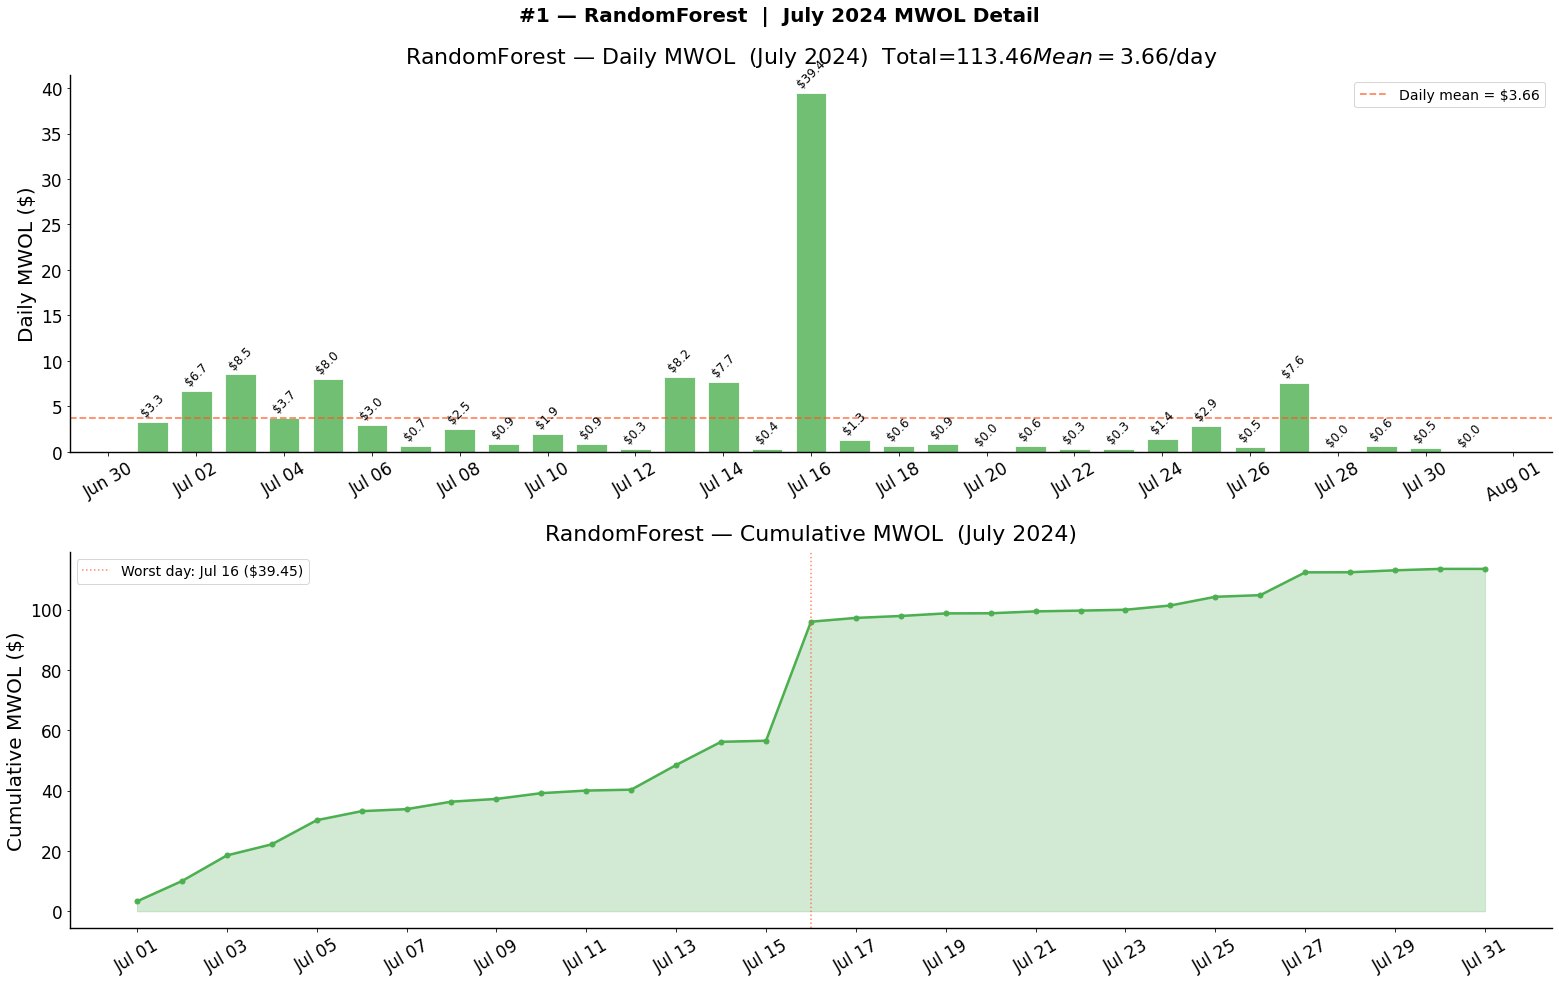

Saved → figM2_randomforest_july_mwol.png


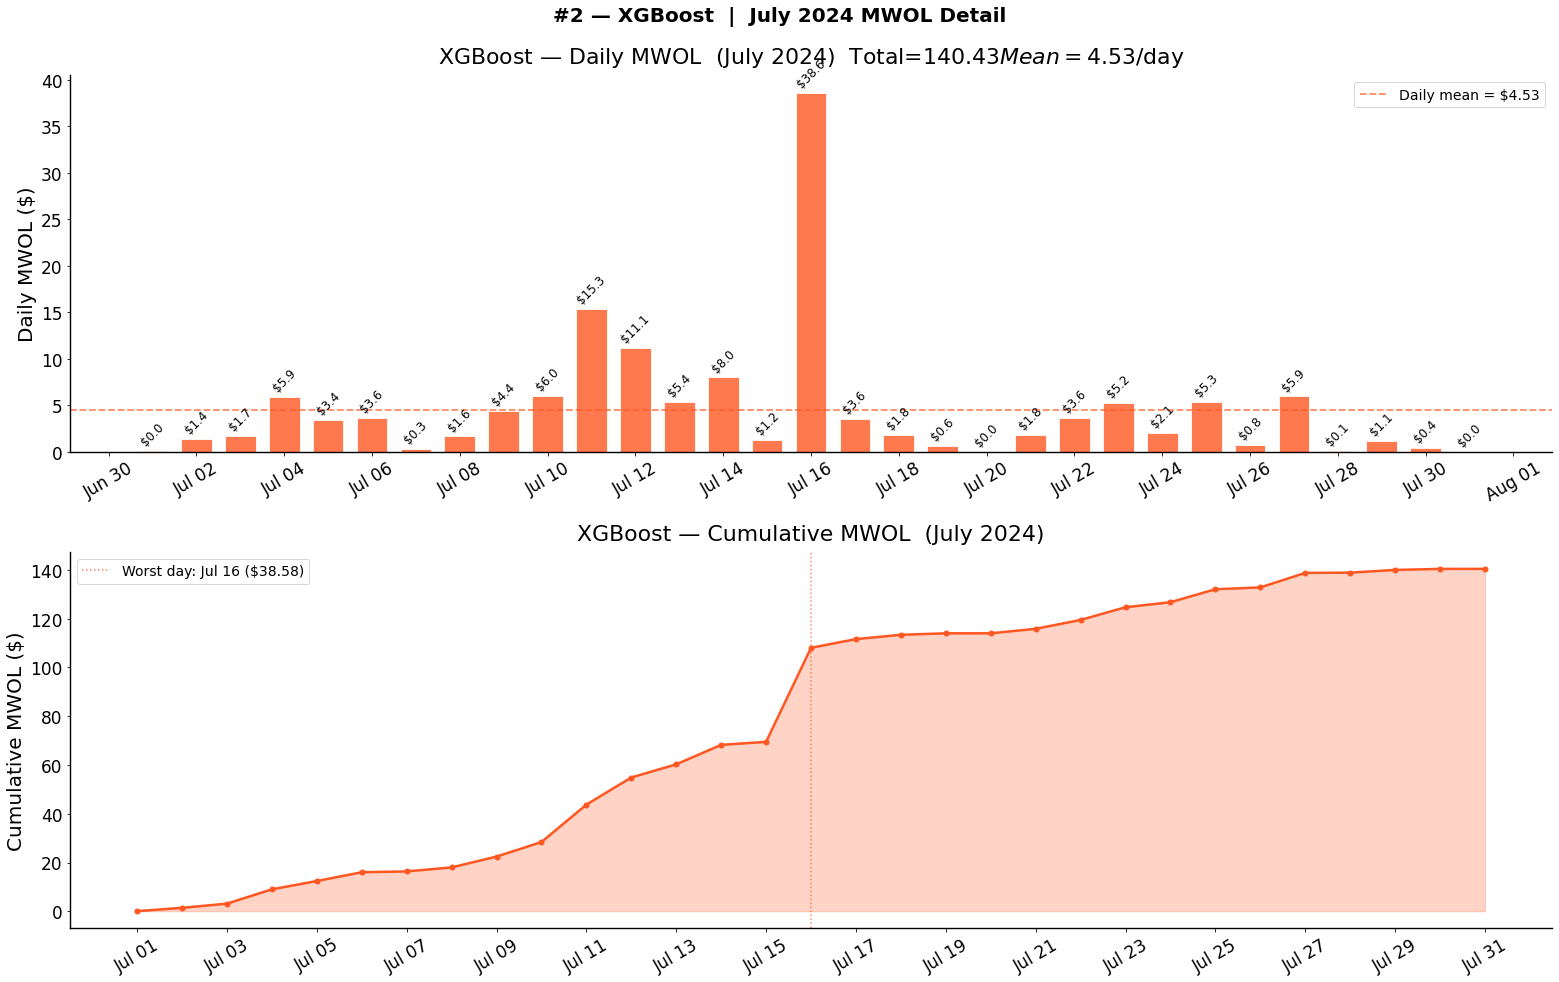

Saved → figM3_xgboost_july_mwol.png


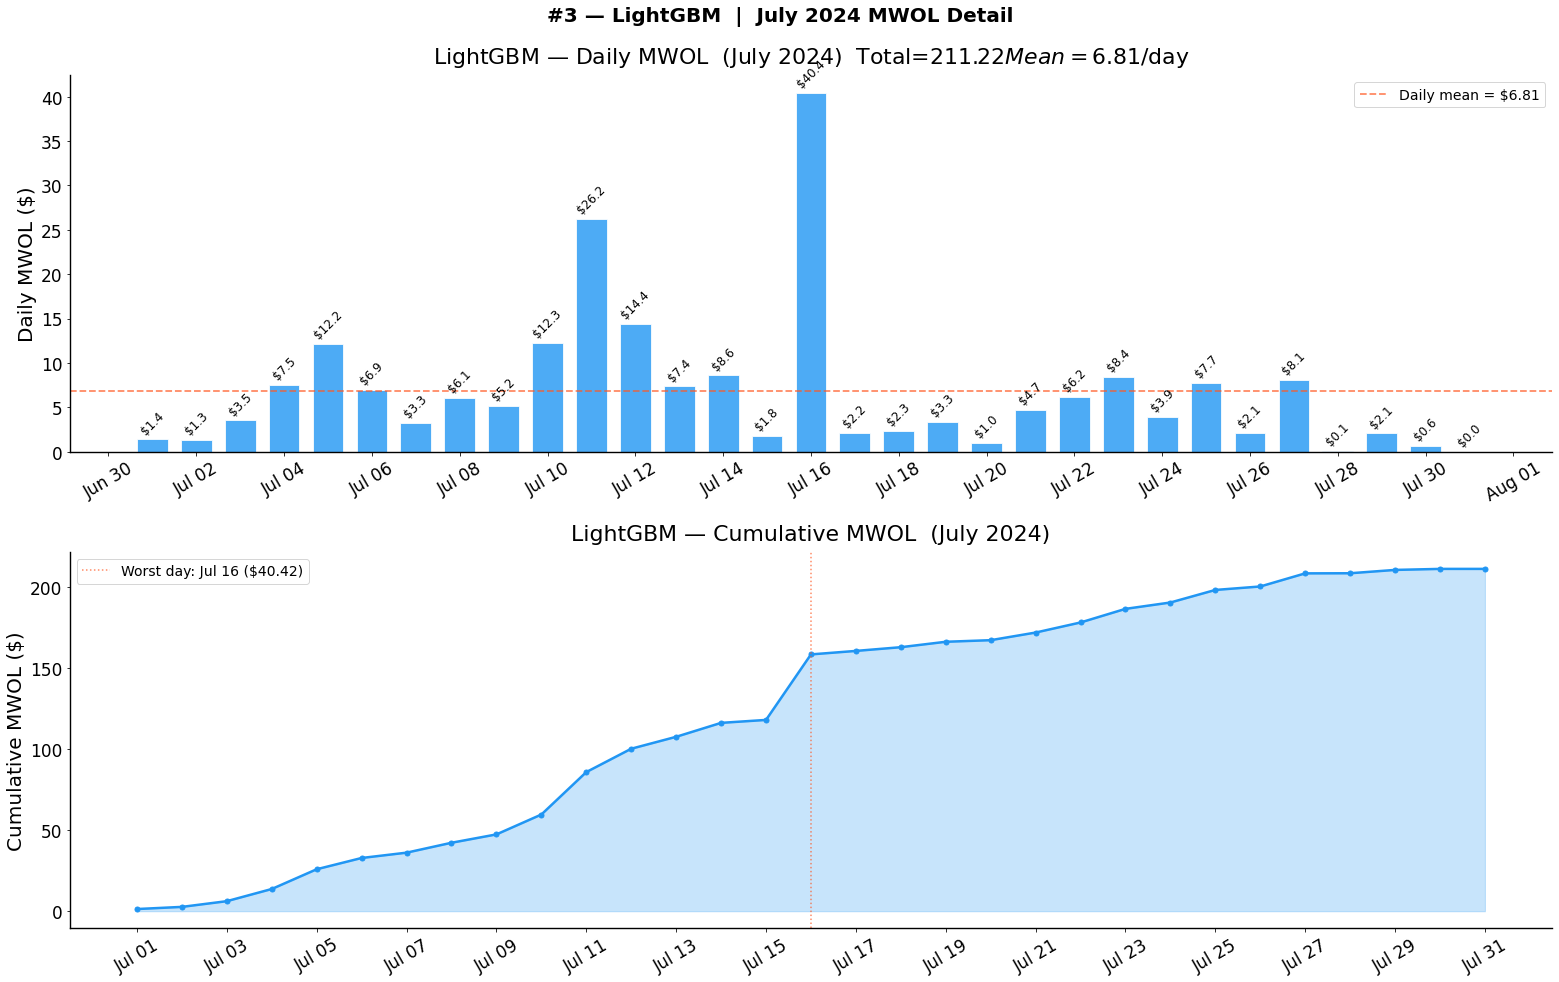

Saved → figM4_lightgbm_july_mwol.png

  JULY 2024 DAILY MWOL SUMMARY — Top 3 Models
  Model                 Total ($)   Mean ($/day)   Max day ($)
  ------------------------------------------------------------
  RandomForest       $    113.46  $       3.66    $    39.45 (Jul 16)
  XGBoost            $    140.43  $       4.53    $    38.58 (Jul 16)
  LightGBM           $    211.22  $       6.81    $    40.42 (Jul 16)


In [37]:
# ── Daily MWOL — July 2024 — Top 3 together then separately ─────────────────

# ── Guard: ensure all dependencies are available ─────────────────────────────
# financial_results: populated by Cell 35; safe to be empty here
try:
    financial_results
except NameError:
    financial_results = {}

# lmp_clean: must be available — run Cell 30 → 31 first.
# If missing, download just the July 2024 slice inline so this cell is
# self-contained.
try:
    lmp_clean
    print(f"lmp_clean available: {len(lmp_clean):,} rows")
except NameError:
    print("lmp_clean not found — downloading July 2024 LMP inline...")
    import requests, zipfile, io, time

    base  = "http://oasis.caiso.com/oasisapi/SingleZip"
    parts = []
    for start_str, end_str in [("20240101", "20240601"),
                                ("20240601", "20241101")]:
        params = {
            "queryname":     "PRC_LMP",
            "startdatetime": f"{start_str}T00:00-0000",
            "enddatetime":   f"{end_str}T00:00-0000",
            "version":       1,
            "market_run_id": "DAM",
            "node":          "TH_NP15_GEN-APND",
            "resultformat":  6,
        }
        try:
            r = requests.get(base, params=params, timeout=90)
            r.raise_for_status()
            with zipfile.ZipFile(io.BytesIO(r.content)) as z:
                csv_name = next(n for n in z.namelist() if n.endswith(".csv"))
                chunk = pd.read_csv(z.open(csv_name))
            chunk = chunk[chunk["LMP_TYPE"] == "LMP"].copy()
            chunk["Interval Start"] = (
                pd.to_datetime(chunk["INTERVALSTARTTIME_GMT"], utc=True)
                  .dt.tz_convert("US/Pacific")
                  .dt.tz_localize(None)
            )
            chunk = chunk.rename(columns={"MW": "LMP"})[["Interval Start", "LMP"]]
            parts.append(chunk)
            print(f"  Downloaded {start_str}–{end_str}: {len(chunk)} rows")
            time.sleep(2)
        except Exception as e:
            print(f"  WARNING: {start_str}–{end_str} failed: {e}")

    if parts:
        lmp_clean = (pd.concat(parts, ignore_index=True)
                       .drop_duplicates("Interval Start")
                       .sort_values("Interval Start")
                       .reset_index(drop=True))
        print(f"lmp_clean ready: {len(lmp_clean):,} rows")
    else:
        raise RuntimeError("Could not download LMP. Check network and try Cell 30.")

# ── Style ─────────────────────────────────────────────────────────────────────
import matplotlib as mpl
mpl.rcParams.update({
    "font.size":18,"axes.titlesize":22,"axes.labelsize":20,
    "xtick.labelsize":17,"ytick.labelsize":17,"legend.fontsize":16,
    "axes.linewidth":1.4,"axes.spines.top":False,"axes.spines.right":False,
})

# ── Build July 2024 daily MWOL for every model ────────────────────────────────
jul_start = pd.Timestamp("2024-07-01")
jul_end   = pd.Timestamp("2024-07-31")

jul_mask_feat = (df_test_feat.index >= jul_start) & (df_test_feat.index <= jul_end)
jul_actual = pd.DataFrame({
    "measured_on": df_test_feat.index[jul_mask_feat],
    "power_kw":    y_test.values[jul_mask_feat],
})

jul_daily_mwol = {}

for name, r in results.items():
    preds_jul = r["preds"][jul_mask_feat]
    jul_preds = pd.DataFrame({
        "measured_on": df_test_feat.index[jul_mask_feat],
        "power_kw":    preds_jul,
    })
    res = compute_market_weighted_loss(
        jul_actual, jul_preds, lmp_clean, time_col="measured_on"
    )
    jul_daily_mwol[name] = res["Daily_MWOL_Series"]

print(f"MWOL computed for {len(jul_daily_mwol)} models over July 2024.")

# ── Fig M1: Top 3 together — July daily MWOL ─────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 8))
for name in top3:
    d = jul_daily_mwol[name]
    ax.plot(d.index, d.values,
            color=COLORS[name], linewidth=2.5,
            linestyle=LINESTYLES[name], marker="o", markersize=5,
            alpha=0.88, label=f"{name}  total=${d.sum():,.0f}")
ax.set_title("Daily MWOL — Top 3 Models  (July 2024)", pad=14)
ax.set_ylabel("Daily MWOL ($)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
ax.legend(framealpha=0.5)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig("figM1_top3_july_mwol_together.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figM1_top3_july_mwol_together.png")

# ── Figs M2–M4: Each top-3 model separately ───────────────────────────────────
for rank, name in enumerate(top3, start=1):
    d   = jul_daily_mwol[name]
    col = COLORS[name]

    fig, axes = plt.subplots(2, 1, figsize=(22, 14), sharex=False)

    # Panel 1: Daily MWOL bar
    bars = axes[0].bar(d.index, d.values,
                       color=col, alpha=0.80, edgecolor="white", width=0.7)
    axes[0].bar_label(bars, labels=[f"${v:.1f}" for v in d.values],
                      fontsize=12, padding=3, rotation=45)
    axes[0].set_title(f"{name} — Daily MWOL  (July 2024)  "
                      f"Total=${d.sum():,.2f}  Mean=${d.mean():.2f}/day", pad=12)
    axes[0].set_ylabel("Daily MWOL ($)")
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    axes[0].xaxis.set_major_locator(mdates.DayLocator(interval=2))
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)
    axes[0].axhline(d.mean(), color="#FF5722", linewidth=1.8, linestyle="--",
                    alpha=0.7, label=f"Daily mean = ${d.mean():.2f}")
    axes[0].legend(fontsize=14)

    # Panel 2: Cumulative MWOL
    cum = d.cumsum()
    axes[1].fill_between(cum.index, cum.values, alpha=0.25, color=col)
    axes[1].plot(cum.index, cum.values, color=col, linewidth=2.5,
                 marker="o", markersize=5)
    axes[1].set_title(f"{name} — Cumulative MWOL  (July 2024)", pad=12)
    axes[1].set_ylabel("Cumulative MWOL ($)")
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    axes[1].xaxis.set_major_locator(mdates.DayLocator(interval=2))
    plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30)
    worst_day = d.idxmax()
    axes[1].axvline(worst_day, color="#FF5722", linewidth=1.5,
                    linestyle=":", alpha=0.7,
                    label=f"Worst day: {worst_day.strftime('%b %d')} (${d.max():.2f})")
    axes[1].legend(fontsize=14)

    plt.suptitle(f"#{rank} — {name}  |  July 2024 MWOL Detail",
                 fontsize=20, fontweight="bold")
    plt.tight_layout()
    fname = f"figM{rank+1}_{name.lower()}_july_mwol.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {fname}")

# ── Summary table ─────────────────────────────────────────────────────────────
print()
print("=" * 65)
print("  JULY 2024 DAILY MWOL SUMMARY — Top 3 Models")
print("=" * 65)
print(f"  {'Model':<18} {'Total ($)':>12} {'Mean ($/day)':>14} {'Max day ($)':>13}")
print("  " + "-"*60)
for name in top3:
    d = jul_daily_mwol[name]
    worst = d.idxmax()
    print(f"  {name:<18} ${d.sum():>10,.2f}  ${d.mean():>11.2f}    "
          f"${d.max():>9.2f} ({worst.strftime('%b %d')})")
print("=" * 65)
